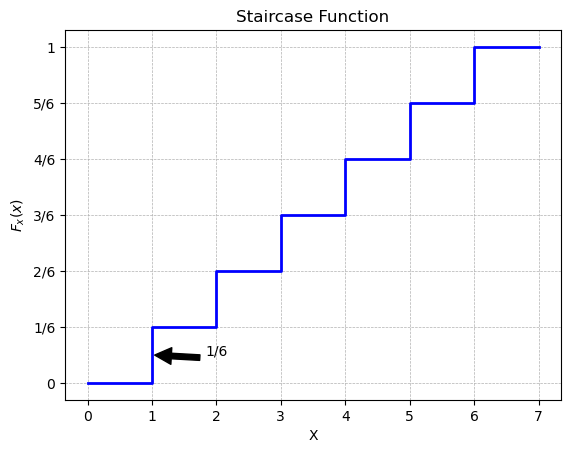

In [1]:
import matplotlib.pyplot as plt

def staircase_function():
    # Define the coordinates of the staircase
    x = [0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7]
    y = [0, 0, 1/6, 1/6, 2/6, 2/6, 3/6, 3/6, 4/6, 4/6, 5/6, 5/6, 1, 1]

    # Plot the staircase function
    plt.step(x, y, where='post', color='b', linewidth=2)

    # Draw a vertical arrow
    plt.annotate(
        '1/6', xy=(1, 1/12), xytext=(2, 1/12),
        arrowprops=dict(facecolor='black', shrink=0.05),
        fontsize=10, ha='center'
    )

    # Customize the y-axis ticks and labels
    plt.yticks([0, 1/6, 2/6, 3/6, 4/6, 5/6, 1], ['0', '1/6', '2/6', '3/6', '4/6', '5/6', '1'])
    
    # Add gridlines
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)

    # Customize the plot
    plt.title('Staircase Function')
    plt.xlabel('X')
    plt.ylabel('$F_x(x)$')

    # Display the plot
    plt.show()

# Call the function to generate the modified staircase plot
staircase_function()



/var/folders/k4/hnf32ctn7n754hp_n6xf2zfr0000gn/T/ipykernel_24772/2994481197.py:11: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  plt.stem([x], [y_value], markerfmt='ro', linefmt='r-', basefmt='r-', use_line_collection=True)


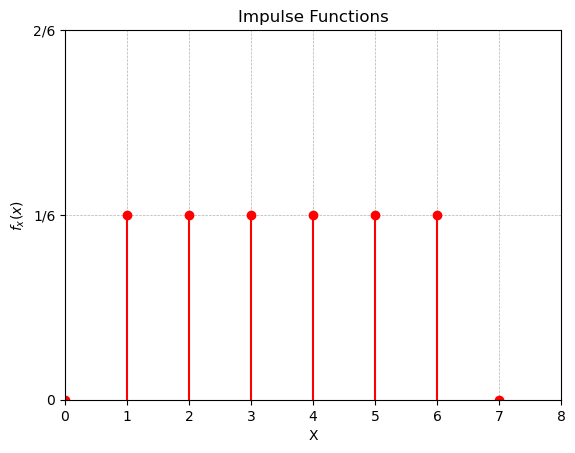

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def impulse_functions():
    # Define the x values for impulse functions
    x_values = np.arange(0, 8)

    # Plot impulse functions
    for x in x_values:
        y_value = 0 if x == 0 or x == 7 else 1/6
        plt.stem([x], [y_value], markerfmt='ro', linefmt='r-', basefmt='r-', use_line_collection=True)

    # Customize the y-axis ticks and labels
    plt.yticks([0, 1/6, 2/6], ['0', '1/6', '2/6'])

    # Add gridlines
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)

    # Customize the plot
    plt.title('Impulse Functions')
    plt.xlabel('X')
    plt.ylabel('$f_x(x)$')

    # Set x-axis and y-axis limits
    plt.xlim(0, 8)
    plt.ylim(0, 2/6)

    # Display the plot
    plt.show()

# Call the function to generate the adjusted impulse functions plot
impulse_functions()




In [19]:
import numpy as np
from scipy.stats import norm

# Known variance of Gaussian process
variance = 1

# Prior belief about the mean (also a Gaussian distribution)
prior_mean = 0
prior_variance = 1

# Generate some data from the Gaussian process
np.random.seed(0)
data = np.random.normal(loc=2, scale=np.sqrt(variance), size=100)

# Update belief about the mean with each new data point
for x in data:
    # Compute the precision (inverse variance) of the prior and the data point
    prior_precision = 1 / prior_variance
    data_precision = 1 / variance

    # Update the mean and variance using Bayes' theorem
    posterior_precision = prior_precision + data_precision
    posterior_variance = 1 / posterior_precision
    posterior_mean = (prior_mean * prior_precision + x * data_precision) / posterior_precision

    # The posterior distribution becomes the prior for the next data point
    prior_mean = posterior_mean
    prior_variance = posterior_variance

print(f"Estimated mean: {posterior_mean}")


Estimated mean: 2.039413876766816


KeyError: 0

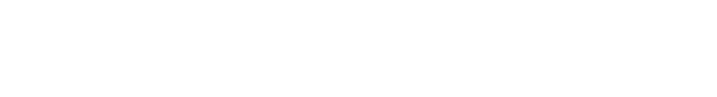

In [36]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad

# Define the function G(x)
def G(x):
    integrand = lambda y: np.exp(-y**2 / 2) / np.sqrt(2 * np.pi)
    result, _ = quad(integrand, 0, x)
    return result

# Define the ranges of x
x_ranges = [(0.05, 0.75), (0.8, 1.5), (1.55, 2.25), (2.3, 3.0)]

# Create separate tables for each x range
for x_range in x_ranges:
    x_values = np.arange(x_range[0], x_range[1] + 0.05, 0.05)
    G_values = np.vectorize(G)(x_values)

    # Format x and G values
    formatted_x = ['{:.2f}'.format(x) for x in x_values]
    formatted_G = ['{:.5f}'.format(G_x) for G_x in G_values]

    # Create a table
    fig, ax = plt.subplots(figsize=(len(x_values) * 0.6, 1))
    ax.axis('off')
    table_data = {'x': formatted_x, 'G(x)': formatted_G}
    ax.table(cellText=table_data, colLabels=['x', 'G(x)'], loc='center', cellLoc='center', colColours=['#f0f0f0']*2)

    plt.title(f'Table of G(x) Values for x in range {x_range}')
    plt.show()



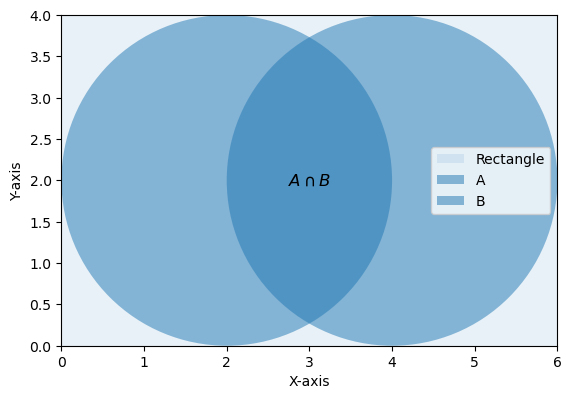

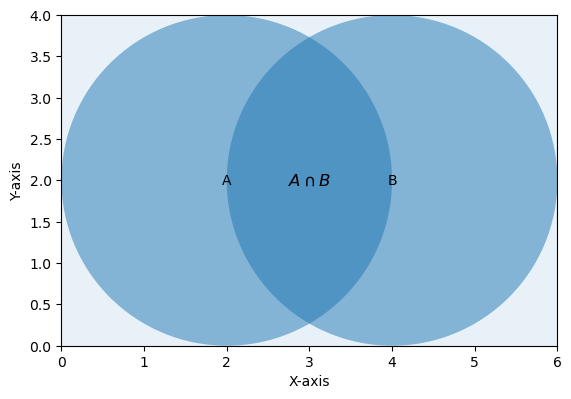

In [24]:
import matplotlib.pyplot as plt
import numpy as np

def draw_circle(ax, center, radius, label):
    circle = plt.Circle(center, radius, alpha=0.5, label='')
    ax.add_patch(circle)
    ax.text(center[0], center[1], label, color='black', ha='center', va='center', fontsize=10)

# Create figure and axes
fig, ax = plt.subplots()

# Draw rectangle
rectangle = plt.Rectangle((0, 0), 6, 4, alpha=0.1, label='')
ax.add_patch(rectangle)

# Draw circles
draw_circle(ax, (2, 2), 2, 'A')
draw_circle(ax, (4, 2), 2, 'B')

# Find the area of overlap
intersection_area = np.pi * (2**2)
ax.annotate('$A \cap B$', (3, 2), fontsize=12, ha='center', va='center')

# Set axis limits
ax.set_xlim(0, 6)
ax.set_ylim(0, 4)

# Set aspect ratio to be equal
ax.set_aspect('equal', 'box')

# Add labels
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')

# Show the plot
plt.show()


KeyError: 0

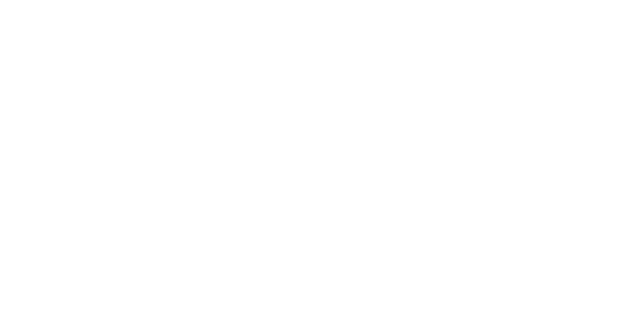

In [34]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad

# Define the function G(x)
def G(x):
    integrand = lambda y: np.exp(-y**2 / 2) / np.sqrt(2 * np.pi)
    result, _ = quad(integrand, 0, x)
    return result

# Values of x
x_values = np.arange(0.05, 2.30, 0.05)

# Calculate G(x) for each x
G_values = np.vectorize(G)(x_values)

# Format x to always show two decimal places and G to always show five decimal places
formatted_x = ['{:.2f}'.format(x) for x in x_values]
formatted_G = ['{:.5f}'.format(G_x) for G_x in G_values]

# Determine the number of rows in each column
num_rows = len(x_values) // 3

# Create a table with three columns
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')
table_data = {'x1': formatted_x[:num_rows], 'G(x1)': formatted_G[:num_rows],
              'x2': formatted_x[num_rows:2*num_rows], 'G(x2)': formatted_G[num_rows:2*num_rows],
              'x3': formatted_x[2*num_rows:], 'G(x3)': formatted_G[2*num_rows:]}
ax.table(cellText=table_data, colLabels=['x', 'G(x)'], loc='center', cellLoc='center', colColours=['#f0f0f0']*2)

plt.title('Table of G(x) Values in Three Columns')
plt.show()





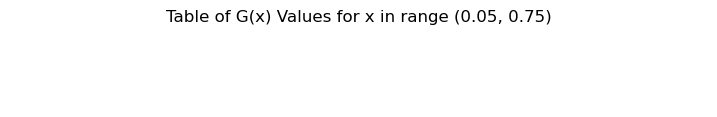

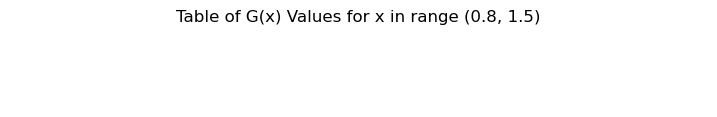

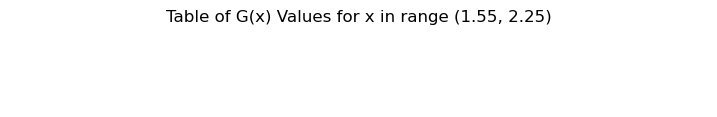

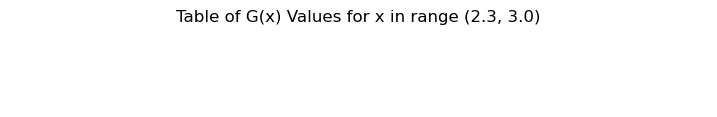

In [38]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad

# Define the function G(x)
def G(x):
    integrand = lambda y: np.exp(-y**2 / 2) / np.sqrt(2 * np.pi)
    result, _ = quad(integrand, 0, x)
    return result

# Define the ranges of x
x_ranges = [(0.05, 0.75), (0.8, 1.5), (1.55, 2.25), (2.3, 3.0)]

# Create separate tables for each x range
for x_range in x_ranges:
    x_values = np.arange(x_range[0], x_range[1] + 0.05, 0.05)
    G_values = np.vectorize(G)(x_values)

    # Format x and G values
    formatted_x = ['{:.2f}'.format(x) for x in x_values]
    formatted_G = ['{:.5f}'.format(G_x) for G_x in G_values]

    # Create a table
    fig, ax = plt.subplots(figsize=(len(x_values) * 0.6, 1))
    ax.axis('off')
    table_data = {'x': formatted_x, 'G(x)': formatted_G}

    plt.title(f'Table of G(x) Values for x in range {x_range}')
    plt.show()


KeyError: 0

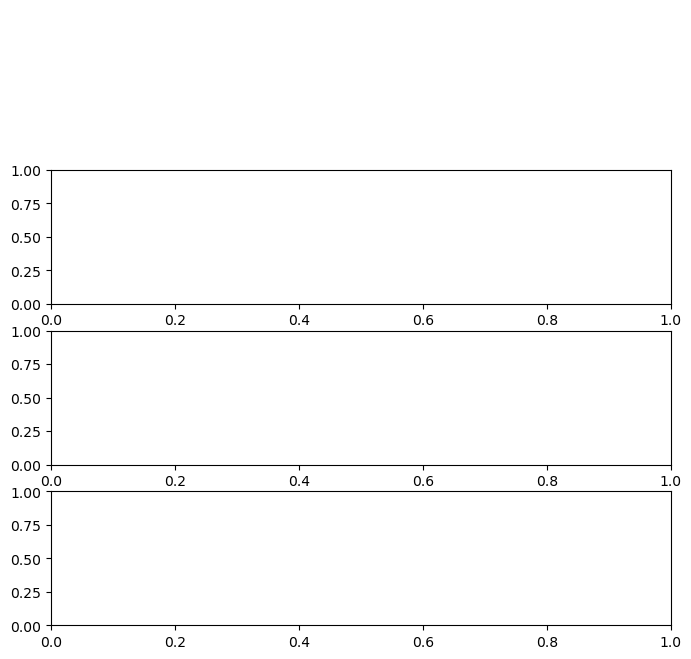

In [39]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad

# Define the function G(x)
def G(x):
    integrand = lambda y: np.exp(-y**2 / 2) / np.sqrt(2 * np.pi)
    result, _ = quad(integrand, 0, x)
    return result

# Define the ranges of x
x_ranges = [(0.05, 0.75), (0.8, 1.5), (1.55, 2.25), (2.3, 3.0)]

# Create separate subplots for each x range
fig, axes = plt.subplots(len(x_ranges), 1, figsize=(8, 2 * len(x_ranges)))

# Iterate through x ranges
for i, x_range in enumerate(x_ranges):
    x_values = np.arange(x_range[0], x_range[1] + 0.05, 0.05)
    G_values = np.vectorize(G)(x_values)

    # Format x and G values
    formatted_x = ['{:.2f}'.format(x) for x in x_values]
    formatted_G = ['{:.5f}'.format(G_x) for G_x in G_values]

    # Create a table
    table_data = {'x': formatted_x, 'G(x)': formatted_G}
    axes[i].axis('off')
    axes[i].table(cellText=table_data, colLabels=['x', 'G(x)'], loc='center', cellLoc='center', colColours=['#f0f0f0']*2)
    axes[i].set_title(f'Table of G(x) Values for x in range {x_range}')

plt.tight_layout()
plt.show()


IndexError: index 4 is out of bounds for axis 0 with size 4

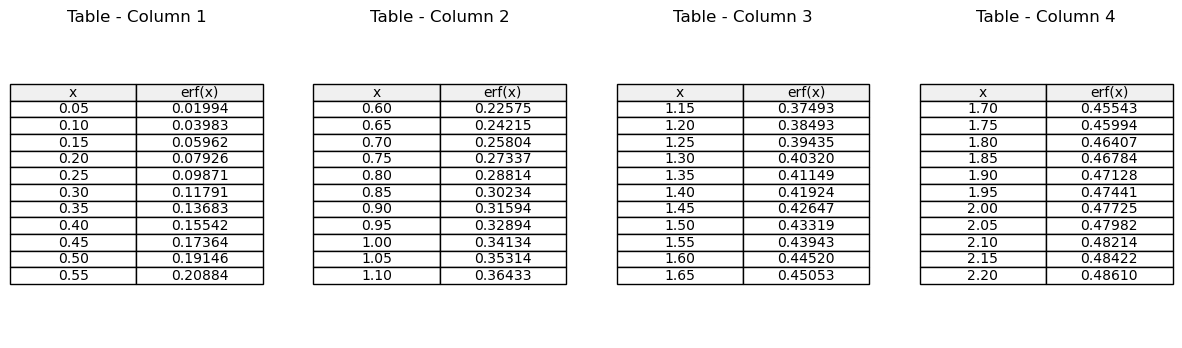

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad

# Define the function G(x)
def G(x):
    integrand = lambda y: np.exp(-y**2 / 2) / np.sqrt(2 * np.pi)
    result, _ = quad(integrand, 0, x)
    return result

# Values of x
x_values = np.arange(0.05, 2.30, 0.05)

# Calculate G(x) for each x
G_values = np.vectorize(G)(x_values)

# Format x to always show two decimal places and G to always show five decimal places
formatted_data = [['{:.2f}'.format(x), '{:.5f}'.format(G_x)] for x, G_x in zip(x_values, G_values)]

# Split the data into four columns
num_columns = 4
split_data = [formatted_data[i:i + len(x_values)//num_columns] for i in range(0, len(formatted_data), len(x_values)//num_columns)]

# Create subplots for each column
fig, axes = plt.subplots(1, num_columns, figsize=(15, 4))

# Plot each column
for i, data in enumerate(split_data):
    ax = axes[i]
    ax.axis('off')
    ax.table(cellText=data, colLabels=['x', 'erf(x)'], loc='center', cellLoc='center', colColours=['#f0f0f0']*2)
    ax.set_title(f'Table - Column {i+1}')

plt.show()


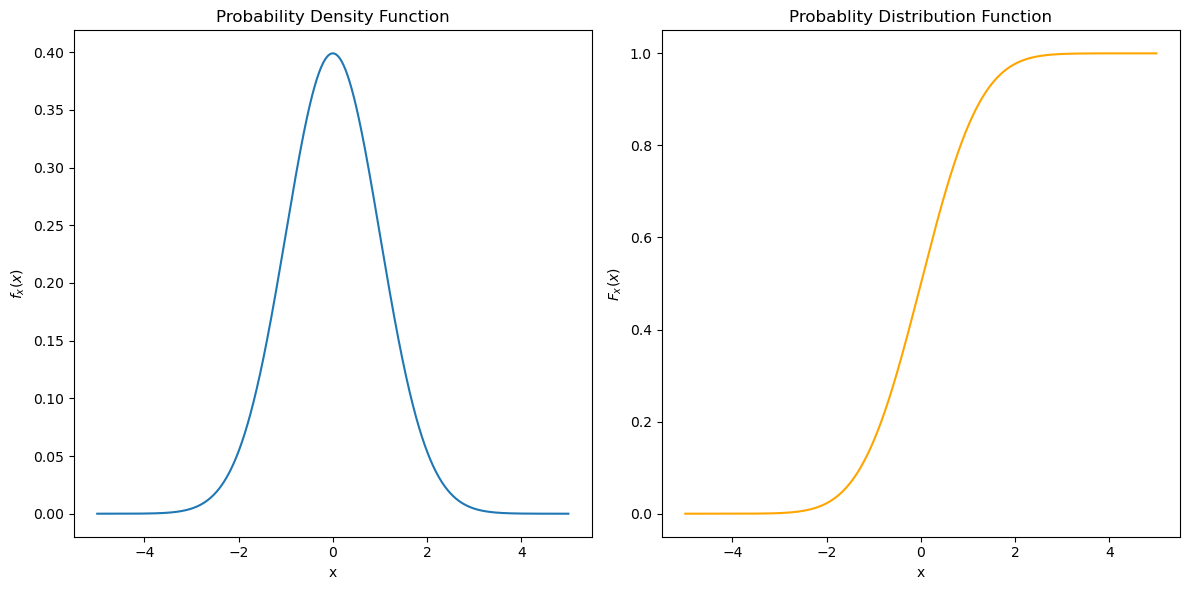

In [46]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define parameters for the Gaussian distribution
mu = 0  # mean
sigma = 1  # standard deviation

# Generate data points
x = np.linspace(-5, 5, 1000)

# Calculate PDF and CDF
pdf = norm.pdf(x, mu, sigma)
cdf = norm.cdf(x, mu, sigma)

# Plot PDF
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(x, pdf, label='PDF')
plt.title('Probability Density Function')
plt.xlabel('x')
plt.ylabel('$f_x(x)$')

# Plot CDF
plt.subplot(1, 2, 2)
plt.plot(x, cdf, label='CDF', color='orange')
plt.title('Probablity Distribution Function')
plt.xlabel('x')
plt.ylabel('$F_x(x)$')

plt.tight_layout()
plt.show()


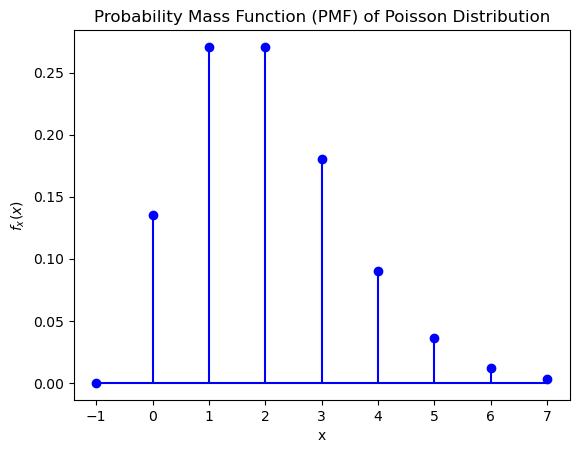

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson

# Define parameters for the Poisson distribution
lambda_val = 2  # parameter for the Poisson distribution

# Generate data points
x_values = np.arange(-1, 8)
pmf_values = poisson.pmf(x_values, lambda_val)

# Plot the probability mass function (PMF)
plt.stem(x_values, pmf_values, basefmt='b-', linefmt='b-', markerfmt='bo')
plt.title('Probability Mass Function (PMF) of Poisson Distribution')
plt.xlabel('x')
plt.ylabel('$f_x(x)$')
plt.xticks(x_values)
plt.show()


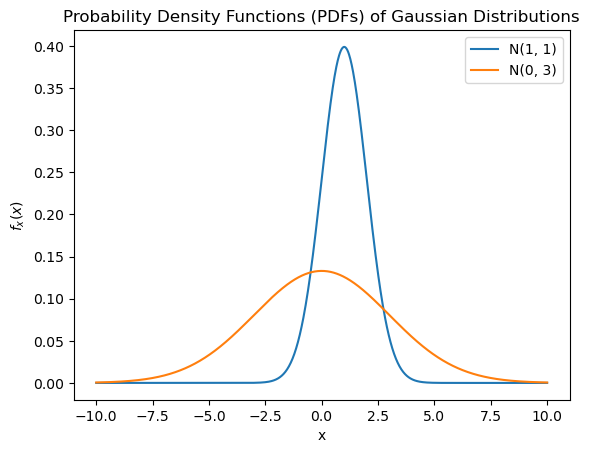

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define parameters for the Gaussian distributions
mean_1, std_dev_1 = 1, 1
mean_2, std_dev_2 = 0, 3

# Generate data points
x_values = np.linspace(-10, 10, 1000)

# Calculate PDF values for each distribution
pdf_1 = norm.pdf(x_values, mean_1, std_dev_1)
pdf_2 = norm.pdf(x_values, mean_2, std_dev_2)

# Plot the probability density functions (PDFs)
plt.plot(x_values, pdf_1, label='N(1, 1)')
plt.plot(x_values, pdf_2, label='N(0, 3)')
plt.title('Probability Density Functions (PDFs) of Gaussian Distributions')
plt.xlabel('x')
plt.ylabel('$f_x(x)$')
plt.legend()
plt.show()


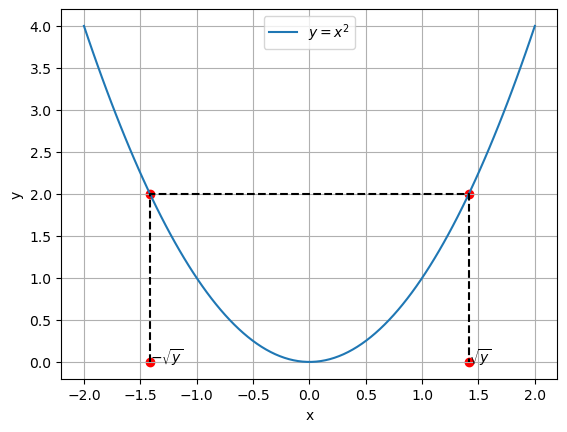

In [63]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function y = x^2
def func(x):
    return x**2

# Generate x values
x_values = np.linspace(-2, 2, 100)

# Generate y values using the function
y_values = func(x_values)

# Plot the function y = x^2
plt.plot(x_values, y_values, label='$y = x^2$')

# Points for dashed lines
points = np.array([[-np.sqrt(2), 0], [-np.sqrt(2), 2], [np.sqrt(2), 2], [np.sqrt(2), 0]])

# Plot dashed lines
plt.plot(points[:, 0], points[:, 1], 'k--')

# Annotate points with symbolic labels
labels = ['$-\sqrt{y}$', ' ', ' ', '$\sqrt{y}$']

for point, label in zip(points, labels):
    plt.scatter(point[0], point[1], color='red')  # Mark the points in red
    plt.text(point[0], point[1], label)

# Set labels and title
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()




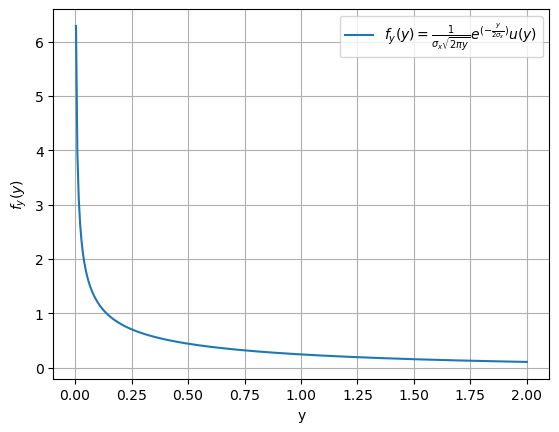

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# Function definition
def f_y(y, sigma_x):
    return (1 / (sigma_x * np.sqrt(2 * np.pi * y))) * np.exp(-y / (2 * sigma_x)) * (y >= 0)

# Parameters
sigma_x = 1

# Generate y values
y_values = np.linspace(-1,2, 500)
y_values = y_values[y_values >= 0]  # Restrict to y >= 0

# Calculate f_y(y)
f_y_values = f_y(y_values, sigma_x)

# Plot the function
plt.plot(y_values, f_y_values, label=r'$f_y(y) = \frac{1}{\sigma_x \sqrt{2\pi y}} e^{(- \frac{y}{2 \sigma_x})}u(y)$')

# Set labels and title
plt.xlabel('y')
plt.ylabel('$f_y(y)$')
plt.legend()
plt.grid(True)
plt.show()


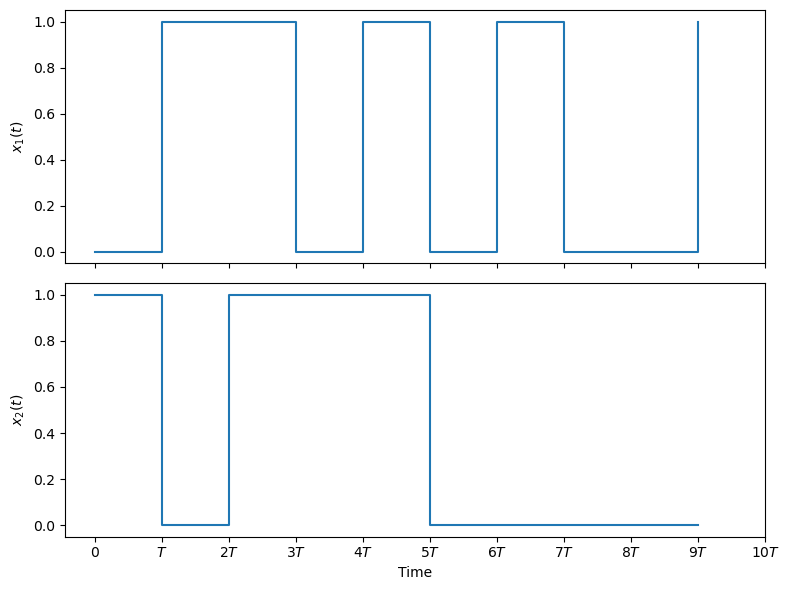

In [69]:
import numpy as np
import matplotlib.pyplot as plt

# Function to generate random binary waveform
def generate_binary_waveform(bit_duration, num_bits):
    bits = np.random.choice([0, 1], size=num_bits)
    t = np.arange(0, num_bits * bit_duration, bit_duration)
    waveform = np.repeat(bits, int(1 / bit_duration))
    return t, waveform

# Parameters
bit_duration = 1.0  # Bit duration in seconds
num_bits = 10      # Number of bits

# Generate random binary waveforms
t1, x1 = generate_binary_waveform(bit_duration, num_bits)
t2, x2 = generate_binary_waveform(bit_duration, num_bits)

# Create subplots
fig, axs = plt.subplots(2, 1, sharex=True, sharey=True, figsize=(8, 6))

# Plot x1(t)
axs[0].step(t1, x1, where='post', label='$x_1(t)$')
axs[0].set_ylabel('$x_1(t)$')

# Plot x2(t)
axs[1].step(t2, x2, where='post', label='$x_2(t)$')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('$x_2(t)$')

# Set x-axis labels as multiples of T
plt.xticks(np.arange(0, (num_bits + 1) * bit_duration, bit_duration), labels=['$0$', '$T$', '$2T$', '$3T$', '$4T$', '$5T$', '$6T$', '$7T$', '$8T$', '$9T$', '$10T$'])

# Display the plot
plt.tight_layout()
plt.show()



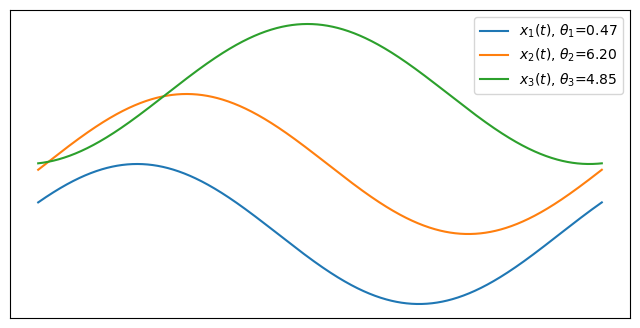

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# Function to generate sinusoidal waveform with random phase offset
def generate_sinusoid(t, frequency, amplitude, phase_offset):
    return amplitude * np.sin(2 * np.pi * frequency * t + phase_offset)

# Parameters
t = np.linspace(0, 1, 1000)  # Time vector
frequency = 1  # Frequency of the sinusoids
amplitude = 1  # Amplitude of the sinusoids
num_samples = 3  # Number of sample functions

# Create a figure
fig, ax = plt.subplots(figsize=(8, 4))

# Plot each sample function with vertical offset and labeled phase offset
for i in range(num_samples):
    phase_offset = np.random.uniform(0, 2 * np.pi)  # Random phase offset
    waveform = generate_sinusoid(t, frequency, amplitude, phase_offset)
    ax.plot(t, waveform + i * amplitude, label=f'$x_{i+1}(t)$, $\\theta_{i+1}$={phase_offset:.2f}')

# Remove x and y axis labels
ax.set_xticks([])
ax.set_yticks([])

# Add legend
ax.legend()

# Display the plot
plt.show()


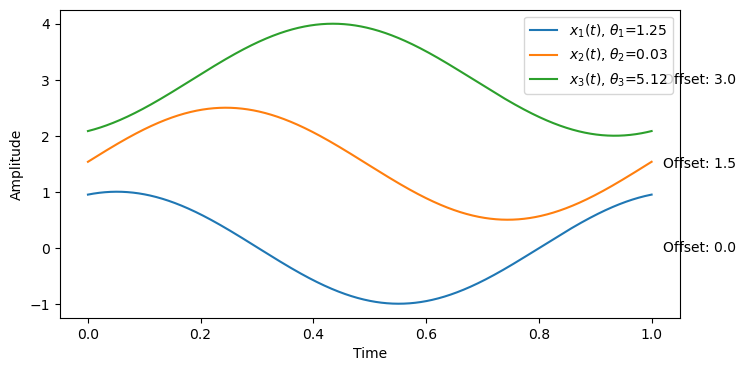

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# Function to generate sinusoidal waveform with random phase offset
def generate_sinusoid(t, frequency, amplitude, phase_offset):
    return amplitude * np.sin(2 * np.pi * frequency * t + phase_offset)

# Parameters
t = np.linspace(0, 1, 1000)  # Time vector
frequency = 1  # Frequency of the sinusoids
amplitude = 1  # Amplitude of the sinusoids
num_samples = 3  # Number of sample functions

# Create a figure
fig, ax = plt.subplots(figsize=(8, 4))

# Plot each sample function with vertical offset and labeled phase offset
for i in range(num_samples):
    phase_offset = np.random.uniform(0, 2 * np.pi)  # Random phase offset
    waveform = generate_sinusoid(t, frequency, amplitude, phase_offset)
    
    # Calculate vertical offset
    vertical_offset = i * 1.5
    
    # Plot the waveform with offset
    ax.plot(t, waveform + vertical_offset, label=f'$x_{i+1}(t)$, $\\theta_{i+1}$={phase_offset:.2f}')
    
    # Show vertical offset as a label
    ax.text(1.02, vertical_offset, f'Offset: {vertical_offset}', verticalalignment='center')

# Set x and y axis labels
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')

# Add legend
ax.legend()

# Display the plot
plt.show()


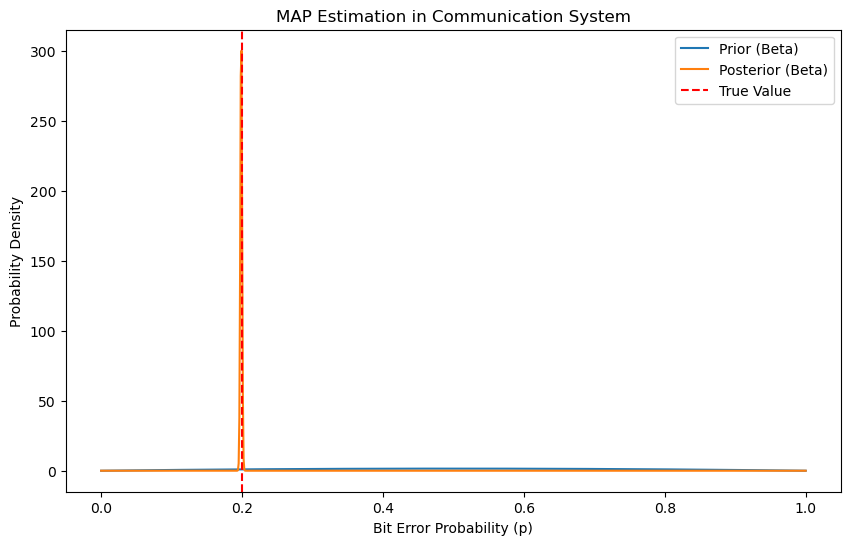

True Bit Error Probability: 0.2
MAP Estimate: 0.1987960240795184


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, binom

# True bit error probability
true_p = 0.2

# Prior parameters for Beta distribution
alpha_prior = 2
beta_prior = 2

# Number of experiments
n_experiments = 1000

# Simulate data (Binomial distribution)
n_bits = 100
data = np.random.binomial(n_bits, true_p, size=n_experiments)

# Prior distribution (Beta)
prior_distribution = beta(alpha_prior, beta_prior)

# Posterior distribution (conjugate Beta-Binomial)
alpha_posterior = alpha_prior + np.sum(data)
beta_posterior = beta_prior + n_bits * n_experiments - np.sum(data)
posterior_distribution = beta(alpha_posterior, beta_posterior)

# MAP estimate
map_estimate = (alpha_posterior - 1) / (alpha_posterior + beta_posterior - 2)

# Plotting
x = np.linspace(0, 1, 1000)

plt.figure(figsize=(10, 6))

# Plot Prior
plt.plot(x, prior_distribution.pdf(x), label='Prior (Beta)')

# Plot Posterior
plt.plot(x, posterior_distribution.pdf(x), label='Posterior (Beta)')

# Plot True Value
plt.axvline(true_p, color='red', linestyle='--', label='True Value')

plt.title('MAP Estimation in Communication System')
plt.xlabel('Bit Error Probability (p)')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

print(f"True Bit Error Probability: {true_p}")
print(f"MAP Estimate: {map_estimate}")


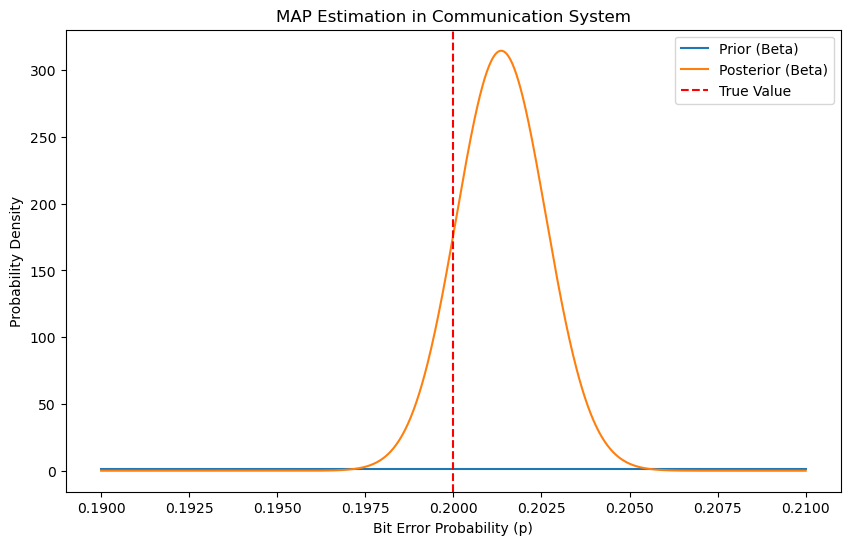

True Bit Error Probability: 0.2
MAP Estimate: 0.20135597288054238


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, binom

# True bit error probability
true_p = 0.2

# Prior parameters for Beta distribution
alpha_prior = 2
beta_prior = 2

# Number of experiments
n_experiments = 1000

# Simulate data (Binomial distribution)
n_bits = 100
data = np.random.binomial(n_bits, true_p, size=n_experiments)

# Prior distribution (Beta)
prior_distribution = beta(alpha_prior, beta_prior)

# Posterior distribution (conjugate Beta-Binomial)
alpha_posterior = alpha_prior + np.sum(data)
beta_posterior = beta_prior + n_bits * n_experiments - np.sum(data)
posterior_distribution = beta(alpha_posterior, beta_posterior)

# MAP estimate
map_estimate = (alpha_posterior - 1) / (alpha_posterior + beta_posterior - 2)

# Plotting
x = np.linspace(0.19, 0.21, 1000)

plt.figure(figsize=(10, 6))

# Plot Prior
plt.plot(x, prior_distribution.pdf(x), label='Prior (Beta)')

# Plot Posterior
plt.plot(x, posterior_distribution.pdf(x), label='Posterior (Beta)')

# Plot True Value
plt.axvline(true_p, color='red', linestyle='--', label='True Value')

plt.title('MAP Estimation in Communication System')
plt.xlabel('Bit Error Probability (p)')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

print(f"True Bit Error Probability: {true_p}")
print(f"MAP Estimate: {map_estimate}")


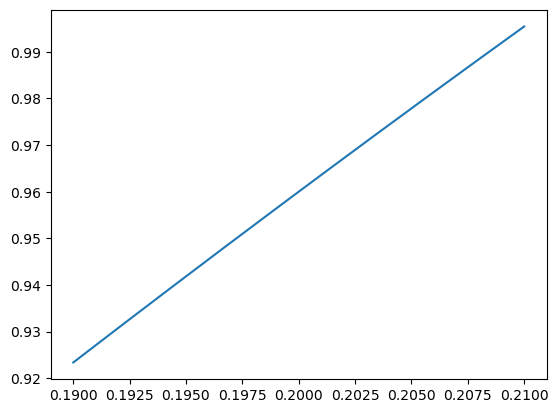

In [7]:
plt.plot(x, prior_distribution.pdf(x), label='Prior (Beta)')


In [8]:
Certainly! We can adjust the x-axis range to zoom in on the density functions. Here's the modified code:

```python
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, binom

# True bit error probability
true_p = 0.2

# Prior parameters for Beta distribution
alpha_prior = 2
beta_prior = 2

# Number of experiments
n_experiments = 1000

# Simulate data (Binomial distribution)
n_bits = 100
data = np.random.binomial(n_bits, true_p, size=n_experiments)

# Prior distribution (Beta)
prior_distribution = beta(alpha_prior, beta_prior)

# Posterior distribution (conjugate Beta-Binomial)
alpha_posterior = alpha_prior + np.sum(data)
beta_posterior = beta_prior + n_bits * n_experiments - np.sum(data)
posterior_distribution = beta(alpha_posterior, beta_posterior)

# MAP estimate
map_estimate = (alpha_posterior - 1) / (alpha_posterior + beta_posterior - 2)

# Plotting
x = np.linspace(0, 0.4, 1000)  # Adjusted x-axis range for zooming in

plt.figure(figsize=(10, 6))

# Plot Prior
plt.plot(x, prior_distribution.pdf(x), label='Prior (Beta)')

# Plot Posterior
plt.plot(x, posterior_distribution.pdf(x), label='Posterior (Beta)')

# Plot True Value
plt.axvline(true_p, color='red', linestyle='--', label='True Value')

plt.title('MAP Estimation in Communication System (Zoomed In)')
plt.xlabel('Bit Error Probability (p)')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

print(f"True Bit Error Probability: {true_p}")
print(f"MAP Estimate: {map_estimate}")
```

Now, the x-axis range is adjusted to zoom in on the range [0, 0.4]. You can modify the `x = np.linspace(0, 0.4, 1000)` line to further adjust the zoom level.

SyntaxError: unterminated string literal (detected at line 1) (2174458725.py, line 1)

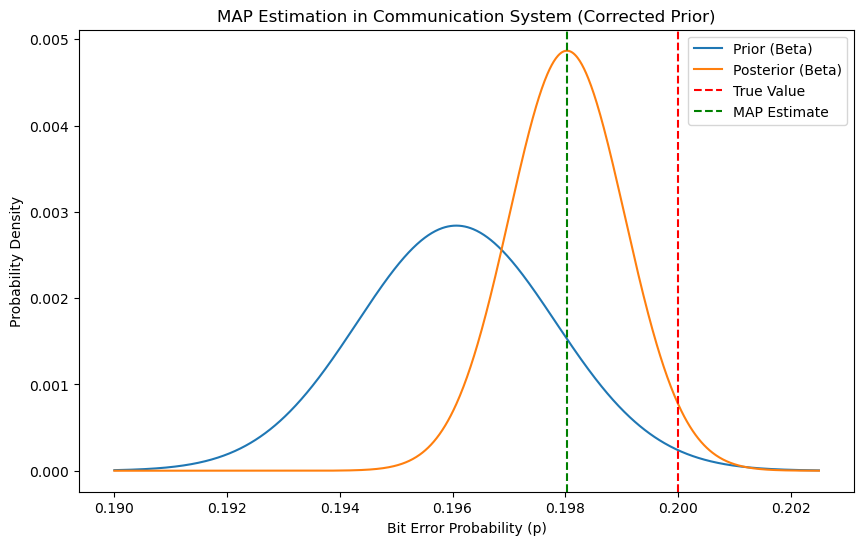

True Bit Error Probability: 0.2
MAP Estimate: 0.19802911296838369


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, binom

# True bit error probability
true_p = 0.2

# Prior parameters for Beta distribution
alpha_prior = 10000
beta_prior = 41000

# Number of experiments
n_experiments = 1000

# Simulate data (Binomial distribution)
n_bits = 100
data = np.random.binomial(n_bits, true_p, size=n_experiments)

# Prior distribution (Beta)
prior_distribution = beta(alpha_prior, beta_prior)

# Posterior distribution (conjugate Beta-Binomial)
alpha_posterior = alpha_prior + np.sum(data)
beta_posterior = beta_prior + n_bits * n_experiments - np.sum(data)
posterior_distribution = beta(alpha_posterior, beta_posterior)

# MAP estimate
map_estimate = (alpha_posterior - 1) / (alpha_posterior + beta_posterior - 2)

# Plotting
x = np.linspace(0.19, .2025, 1000)

plt.figure(figsize=(10, 6))

# Plot Prior
plt.plot(x, prior_distribution.pdf(x)/sum(prior_distribution.pdf(x)), label='Prior (Beta)')

# Plot Posterior
plt.plot(x, posterior_distribution.pdf(x)/sum(posterior_distribution.pdf(x)), label='Posterior (Beta)')

# Plot True Value
plt.axvline(true_p, color='red', linestyle='--', label='True Value')

# Plot MAP Estimate
plt.axvline(map_estimate, color='green', linestyle='--', label='MAP Estimate')

plt.title('MAP Estimation in Communication System (Corrected Prior)')
plt.xlabel('Bit Error Probability (p)')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

print(f"True Bit Error Probability: {true_p}")
print(f"MAP Estimate: {map_estimate}")


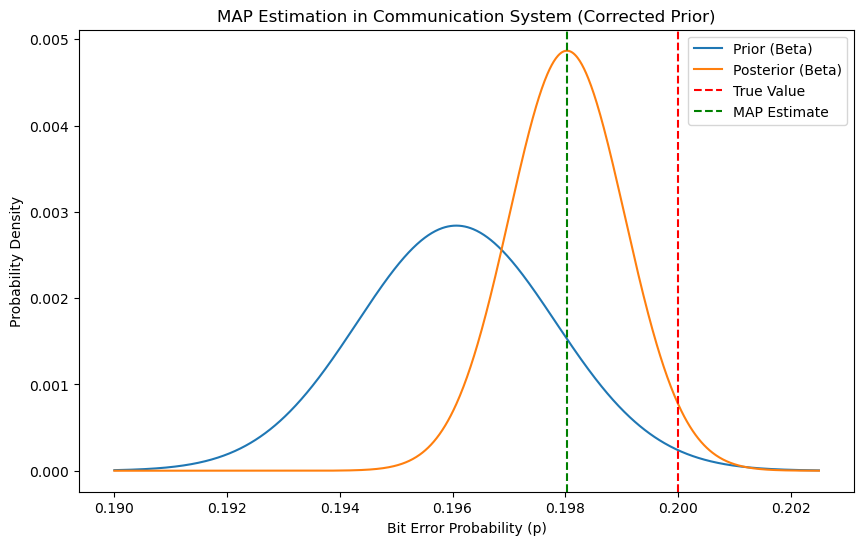

True Bit Error Probability: 0.2
MAP Estimate: 0.19802911296838369


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, binom

# True bit error probability
true_p = 0.2

# Prior parameters for Beta distribution
alpha_prior = 10000
beta_prior = 41000

# Number of experiments
n_experiments = 1000

# Simulate data (Binomial distribution)
n_bits = 100
data = np.random.binomial(n_bits, true_p, size=n_experiments)

# Prior distribution (Beta)
prior_distribution = beta(alpha_prior, beta_prior)

# Posterior distribution (conjugate Beta-Binomial)
alpha_posterior = alpha_prior + np.sum(data)
beta_posterior = beta_prior + n_bits * n_experiments - np.sum(data)
posterior_distribution = beta(alpha_posterior, beta_posterior)

# MAP estimate
map_estimate = (alpha_posterior - 1) / (alpha_posterior + beta_posterior - 2)

# Plotting
x = np.linspace(0.19, .2025, 1000)

plt.figure(figsize=(10, 6))

# Plot Prior
plt.plot(x, prior_distribution.pdf(x)/sum(prior_distribution.pdf(x)), label='Prior (Beta)')

# Plot Posterior
plt.plot(x, posterior_distribution.pdf(x)/sum(posterior_distribution.pdf(x)), label='Posterior (Beta)')

# Plot True Value
plt.axvline(true_p, color='red', linestyle='--', label='True Value')

# Plot MAP Estimate
plt.axvline(map_estimate, color='green', linestyle='--', label='MAP Estimate')

plt.title('MAP Estimation in Communication System (Corrected Prior)')
plt.xlabel('Bit Error Probability (p)')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

print(f"True Bit Error Probability: {true_p}")
print(f"MAP Estimate: {map_estimate}")


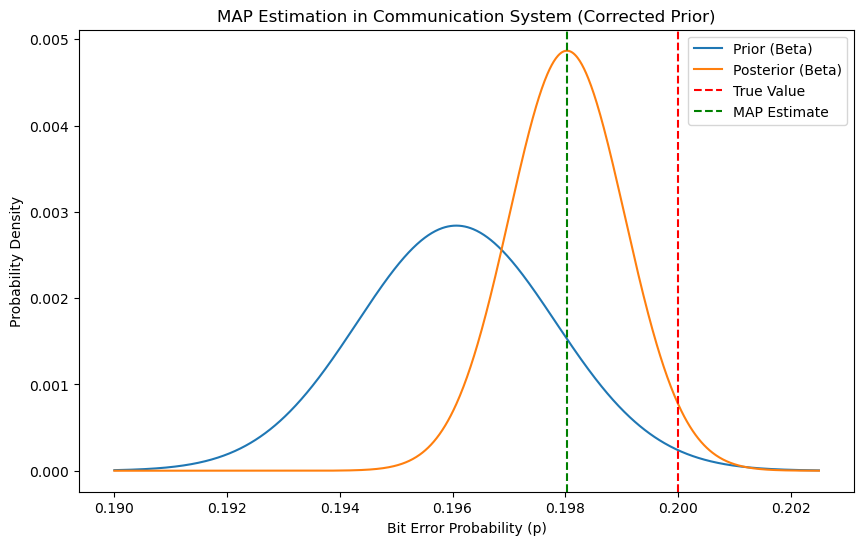

True Bit Error Probability: 0.2
MAP Estimate: 0.19802911296838369


In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta, binom

# True bit error probability
true_p = 0.2

# Prior parameters for Beta distribution
alpha_prior = 10000
beta_prior = 41000

# Number of experiments
n_experiments = 1000

# Simulate data (Binomial distribution)
n_bits = 100
data = np.random.binomial(n_bits, true_p, size=n_experiments)

# Prior distribution (Beta)
prior_distribution = beta(alpha_prior, beta_prior)

# Posterior distribution (conjugate Beta-Binomial)
alpha_posterior = alpha_prior + np.sum(data)
beta_posterior = beta_prior + n_bits * n_experiments - np.sum(data)
posterior_distribution = beta(alpha_posterior, beta_posterior)

# MAP estimate
map_estimate = (alpha_posterior - 1) / (alpha_posterior + beta_posterior - 2)

# Plotting
x = np.linspace(0.19, .2025, 1000)

plt.figure(figsize=(10, 6))

# Plot Prior
plt.plot(x, prior_distribution.pdf(x)/sum(prior_distribution.pdf(x)), label='Prior (Beta)')

# Plot Posterior
plt.plot(x, posterior_distribution.pdf(x)/sum(posterior_distribution.pdf(x)), label='Posterior (Beta)')

# Plot True Value
plt.axvline(true_p, color='red', linestyle='--', label='True Value')

# Plot MAP Estimate
plt.axvline(map_estimate, color='green', linestyle='--', label='MAP Estimate')

plt.title('MAP Estimation in Communication System (Corrected Prior)')
plt.xlabel('Bit Error Probability (p)')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

print(f"True Bit Error Probability: {true_p}")
print(f"MAP Estimate: {map_estimate}")


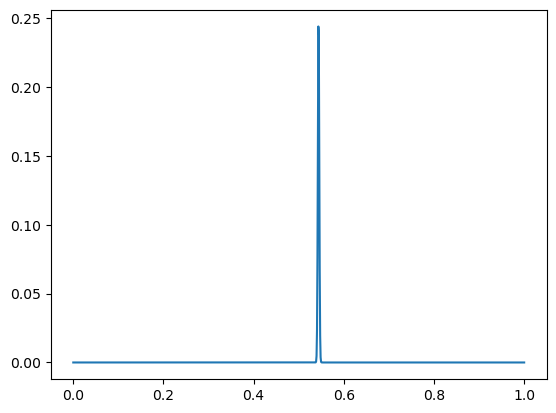

In [24]:
plt.plot(x, posterior_distribution.pdf(x)/sum(posterior_distribution.pdf(x)), label='Prior (Beta)')


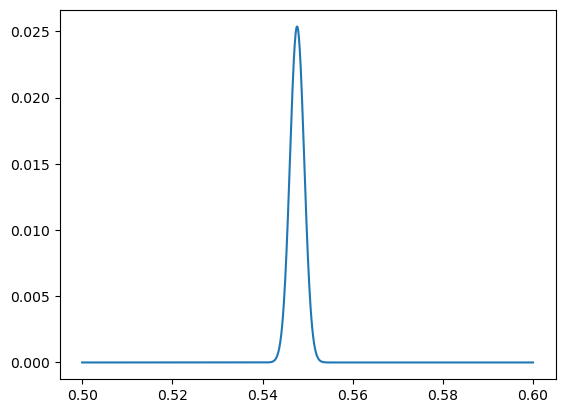

In [19]:
plt.plot(x, posterior_distribution.pdf(x)/sum(posterior_distribution.pdf(x)), label='Posterior (Beta)')


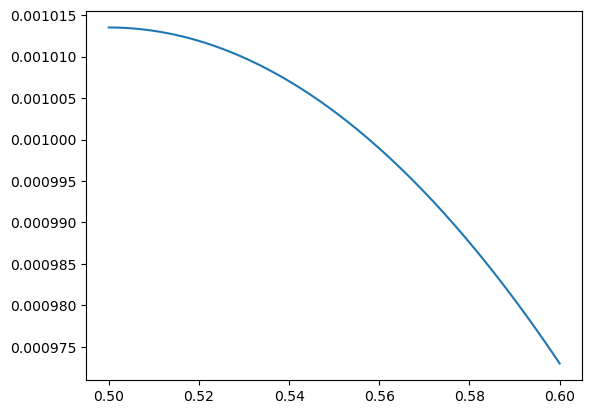

In [20]:
plt.plot(x, prior_distribution.pdf(x)/sum(prior_distribution.pdf(x)), label='Prior (Beta)')


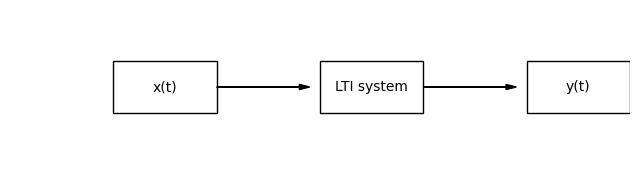

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Function to draw a block with text
def draw_block(ax, text, xy):
    block = patches.Rectangle(xy, 1, 1, fill=None, edgecolor='black')
    ax.add_patch(block)
    ax.text(xy[0] + 0.5, xy[1] + 0.5, text, ha='center', va='center')

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 2))

# Draw input block x(t)
draw_block(ax, 'x(t)', (0, 0))

# Draw LTI system block
draw_block(ax, 'LTI system', (2, 0))

# Draw output block y(t)
draw_block(ax, 'y(t)', (4, 0))

# Connect input to LTI system
ax.arrow(1, 0.5, 0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

# Connect LTI system to output
ax.arrow(3, 0.5, 0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

# Set axis properties
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 2)
ax.axis('off')

# Show the plot
plt.show()


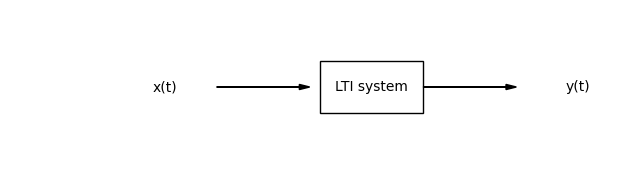

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Function to draw a block with text
def draw_block(ax, text, xy, transparent=False):
    if transparent:
        block = patches.Rectangle(xy, 1, 1, fill=None, edgecolor='none')
    else:
        block = patches.Rectangle(xy, 1, 1, fill=None, edgecolor='black')
    ax.add_patch(block)
    ax.text(xy[0] + 0.5, xy[1] + 0.5, text, ha='center', va='center')

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 2))

# Draw input block x(t)
draw_block(ax, 'x(t)', (0, 0), transparent=True)

# Draw LTI system block
draw_block(ax, 'LTI system', (2, 0))

# Draw output block y(t)
draw_block(ax, 'y(t)', (4, 0), transparent=True)

# Connect input to LTI system
ax.arrow(1, 0.5, 0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

# Connect LTI system to output
ax.arrow(3, 0.5, 0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

# Set axis properties
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 2)
ax.axis('off')

# Show the plot
plt.show()


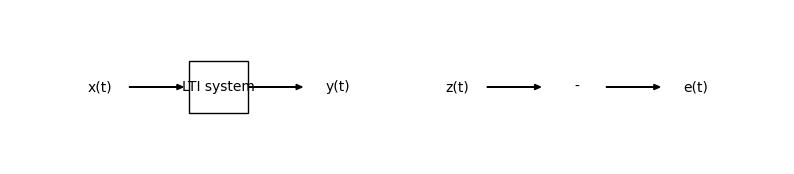

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Function to draw a block with text
def draw_block(ax, text, xy, transparent=False):
    if transparent:
        block = patches.Rectangle(xy, 1, 1, fill=None, edgecolor='none')
    else:
        block = patches.Rectangle(xy, 1, 1, fill=None, edgecolor='black')
    ax.add_patch(block)
    ax.text(xy[0] + 0.5, xy[1] + 0.5, text, ha='center', va='center')

# Create a figure and axis
fig, ax = plt.subplots(figsize=(10, 2))

# Draw input block x(t)
draw_block(ax, 'x(t)', (0, 0), transparent=True)

# Draw LTI system block
draw_block(ax, 'LTI system', (2, 0))

# Draw output block y(t)
draw_block(ax, 'y(t)', (4, 0), transparent=True)

# Draw another input block z(t)
draw_block(ax, 'z(t)', (6, 0), transparent=True)

# Draw subtraction block (-)
draw_block(ax, '-', (8, 0), transparent=True)

# Draw output block e(t)
draw_block(ax, 'e(t)', (10, 0), transparent=True)

# Connect input to LTI system
ax.arrow(1, 0.5, 0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

# Connect LTI system to output y(t)
ax.arrow(3, 0.5, 0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

# Connect z(t) to subtraction block
ax.arrow(7, 0.5, 0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

# Connect subtraction block to e(t)
ax.arrow(9, 0.5, 0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

# Set axis properties
ax.set_xlim(-1, 12)
ax.set_ylim(-1, 2)
ax.axis('off')

# Show the plot
plt.show()


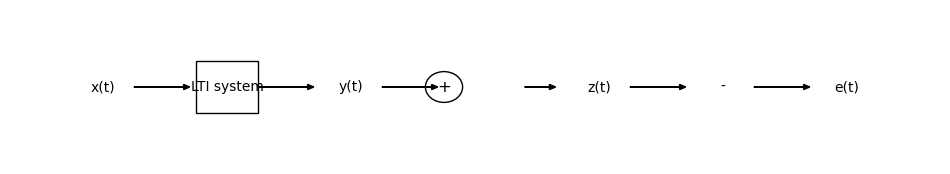

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Function to draw a block with text
def draw_block(ax, text, xy, transparent=False):
    if transparent:
        block = patches.Rectangle(xy, 1, 1, fill=None, edgecolor='none')
    else:
        block = patches.Rectangle(xy, 1, 1, fill=None, edgecolor='black')
    ax.add_patch(block)
    ax.text(xy[0] + 0.5, xy[1] + 0.5, text, ha='center', va='center')

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 2))

# Draw input block x(t)
draw_block(ax, 'x(t)', (0, 0), transparent=True)

# Draw LTI system block
draw_block(ax, 'LTI system', (2, 0))

# Draw output block y(t)
draw_block(ax, 'y(t)', (4, 0), transparent=True)

# Draw addition/subtraction circle
circle = patches.Circle((6, 0.5), 0.3, fill=None, edgecolor='black')
ax.add_patch(circle)
ax.text(6, 0.5, '+', ha='center', va='center', fontsize=12)

# Draw input block z(t)
draw_block(ax, 'z(t)', (8, 0), transparent=True)

# Draw subtraction block (-)
draw_block(ax, '-', (10, 0), transparent=True)

# Draw output block e(t)
draw_block(ax, 'e(t)', (12, 0), transparent=True)

# Connect input to LTI system
ax.arrow(1, 0.5, 0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

# Connect LTI system to output y(t)
ax.arrow(3, 0.5, 0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

# Connect y(t) to the circle
ax.arrow(5, 0.5, 0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

# Connect the circle to z(t)
ax.arrow(7.3, 0.5, 0.4, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

# Connect z(t) to subtraction block
ax.arrow(9, 0.5, 0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

# Connect subtraction block to e(t)
ax.arrow(11, 0.5, 0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

# Set axis properties
ax.set_xlim(-1, 14)
ax.set_ylim(-1, 2)
ax.axis('off')

# Show the plot
plt.show()


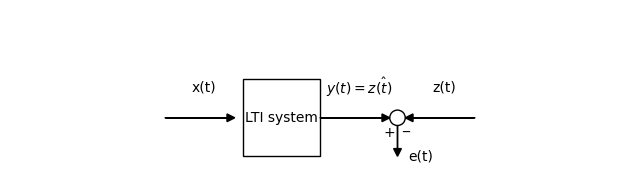

In [56]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Function to draw a block with text
def draw_block(ax, text, xy, transparent=False):
    if transparent:
        block = patches.Rectangle(xy, 1, 1, fill=None, edgecolor='none')
    else:
        block = patches.Rectangle(xy, 1, 1, fill=None, edgecolor='black')
    ax.add_patch(block)
    ax.text(xy[0] + 0.5, xy[1] + 0.5, text, ha='center', va='center')

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 2))

# Draw input block x(t)
draw_block(ax, 'x(t)', (1, 0.5), transparent=True)

# Draw LTI system block
draw_block(ax, 'LTI system', (2, 0.1))

# Draw output block y(t)
draw_block(ax, '$y(t) = \hat{z(t)}$', (3, 0.5), transparent=True)

# Connect input to LTI system
ax.arrow(1, 0.6, 0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

# Connect LTI system to output
ax.arrow(3, 0.6, 0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)
ax.arrow(5, 0.6, -0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)
ax.arrow(4, 0.5, 0.0, -0.3, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

#Draw desired signal  block y(t)
draw_block(ax, 'z(t)', (4.1, 0.5), transparent=True)

draw_block(ax, 'e(t)', (3.8, -0.4), transparent=True)

circle = patches.Circle((4, 0.6), 0.1, fill=None, edgecolor='black')
ax.add_patch(circle)
ax.text(3.9, 0.4, '+', ha='center', va='center', fontsize=10)
ax.text(4.1, 0.5, '_', ha='center', va='center', fontsize=10)

# Set axis properties
ax.set_xlim(-1, 7)
ax.set_ylim(0, 2)
ax.axis('off')


# Show the plot
plt.show()


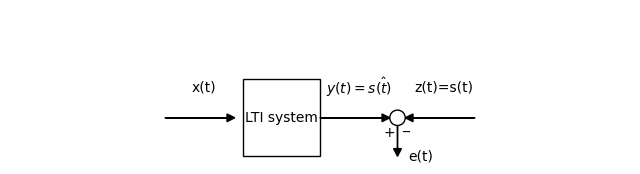

In [59]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Function to draw a block with text
def draw_block(ax, text, xy, transparent=False):
    if transparent:
        block = patches.Rectangle(xy, 1, 1, fill=None, edgecolor='none')
    else:
        block = patches.Rectangle(xy, 1, 1, fill=None, edgecolor='black')
    ax.add_patch(block)
    ax.text(xy[0] + 0.5, xy[1] + 0.5, text, ha='center', va='center')

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 2))

# Draw input block x(t)
draw_block(ax, 'x(t)', (1, 0.5), transparent=True)

# Draw LTI system block
draw_block(ax, 'LTI system', (2, 0.1))

# Draw output block y(t)
draw_block(ax, '$y(t) = \hat{s(t)}$', (3, 0.5), transparent=True)

# Connect input to LTI system
ax.arrow(1, 0.6, 0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

# Connect LTI system to output
ax.arrow(3, 0.6, 0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)
ax.arrow(5, 0.6, -0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)
ax.arrow(4, 0.5, 0.0, -0.3, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

#Draw desired signal  block y(t)
draw_block(ax, 'z(t)=s(t)', (4.1, 0.5), transparent=True)

draw_block(ax, 'e(t)', (3.8, -0.4), transparent=True)

circle = patches.Circle((4, 0.6), 0.1, fill=None, edgecolor='black')
ax.add_patch(circle)
ax.text(3.9, 0.4, '+', ha='center', va='center', fontsize=10)
ax.text(4.1, 0.5, '_', ha='center', va='center', fontsize=10)

# Set axis properties
ax.set_xlim(-1, 7)
ax.set_ylim(0, 2)
ax.axis('off')


# Show the plot
plt.show()


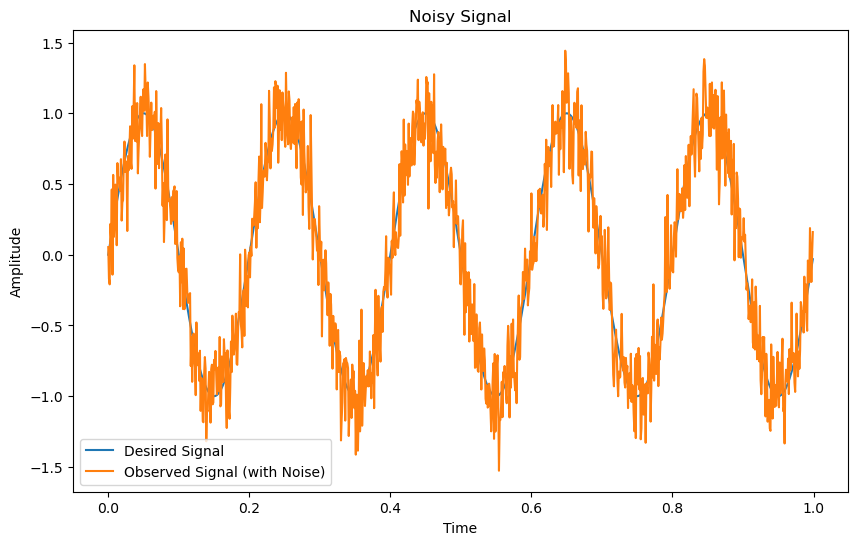

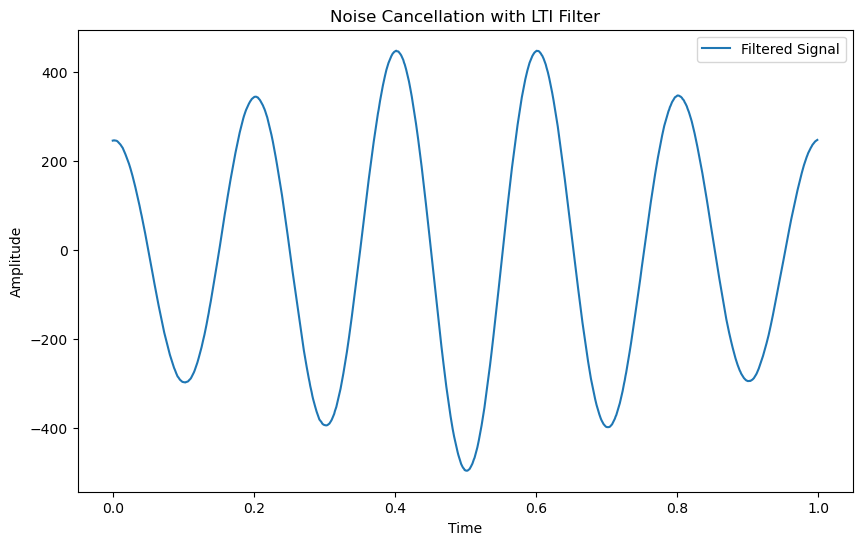

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Generate a sample signal with noise
t = np.linspace(0, 1, 1000, endpoint=False)
z = np.sin(2 * np.pi * 5 * t)  # Desired signal
n = 0.2 * np.random.randn(len(t))  # Gaussian noise
x = z + n  # Observed signal with noise

# Design an LTI filter using Wiener filter design
h = signal.wiener(x, mysize=10)

# Apply the filter to the observed signal
y = signal.convolve(x, h, mode='same')

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(t, z, label='Desired Signal')
plt.plot(t, x, label='Observed Signal (with Noise)')
plt.legend()
plt.title('Noisy Signal')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t, y, label='Filtered Signal')
plt.legend()
plt.title('Noise Cancellation with LTI Filter')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()


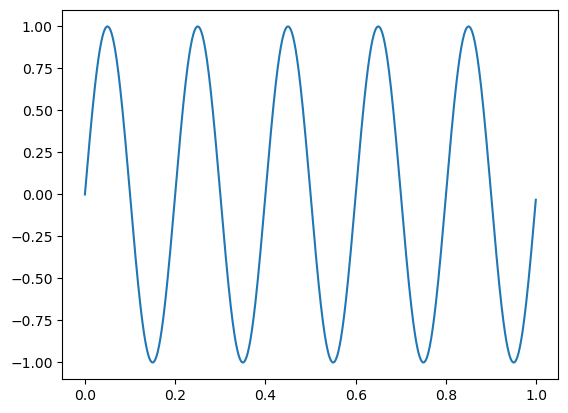

In [61]:
plt.plot(t, z)

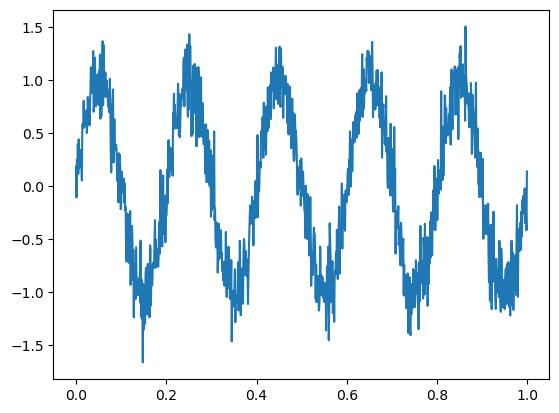

In [62]:
plt.plot(t, x)

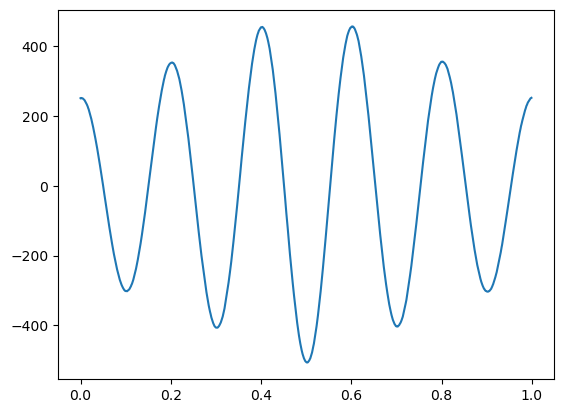

In [63]:
plt.plot(t, y)

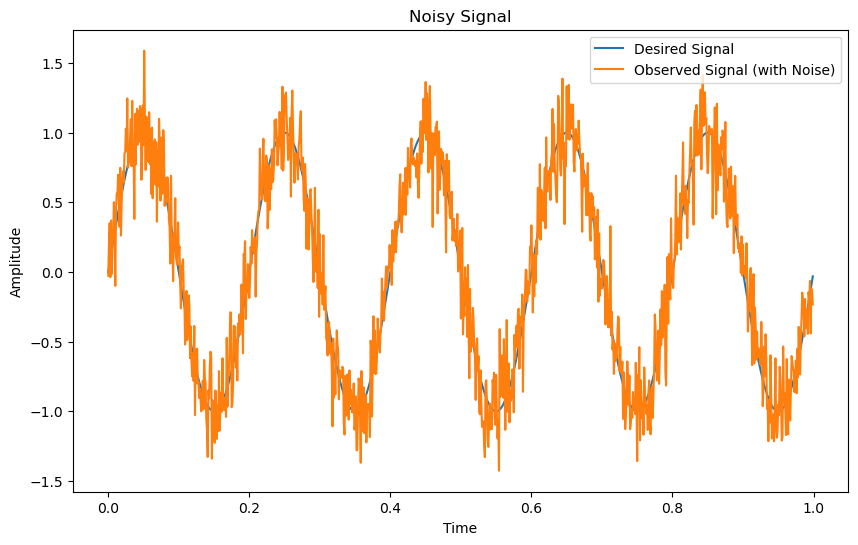

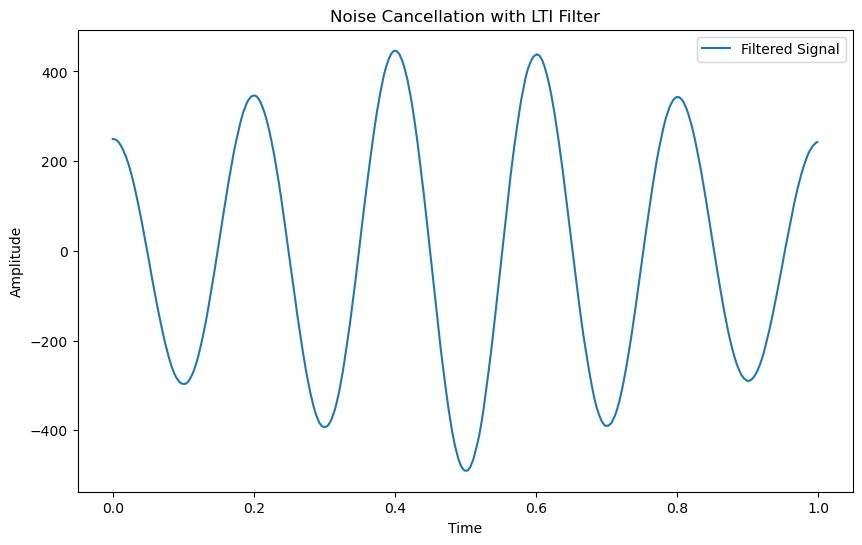

In [65]:
import numpy as np
import matplotlib.pyplot as plt
# WienerFilter
from scipy import signal

# Generate a sample signal with noise
t = np.linspace(0, 1, 1000, endpoint=False)
z = np.sin(2 * np.pi * 5 * t)  # Desired signal
n = 0.2 * np.random.randn(len(t))  # Gaussian noise
x = z + n  # Observed signal with noise

# Design an LTI filter using Wiener filter design
h = signal.wiener(x, mysize=10)

# Apply the filter to the observed signal
y = signal.convolve(x, h, mode='same')

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(t, z, label='Desired Signal')
plt.plot(t, x, label='Observed Signal (with Noise)')
plt.legend()
plt.title('Noisy Signal')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t, y, label='Filtered Signal')
plt.legend()
plt.title('Noise Cancellation with LTI Filter')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()


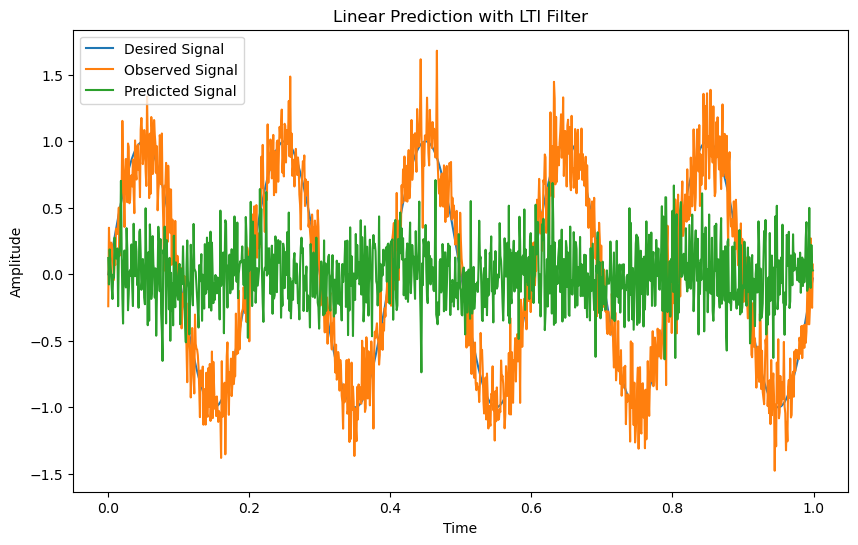

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import toeplitz, solve_toeplitz

# Generate a sample signal with noise
t = np.linspace(0, 1, 1000, endpoint=False)
z = np.sin(2 * np.pi * 5 * t)  # Desired signal
n = 0.2 * np.random.randn(len(t))  # Gaussian noise
x = z + n  # Observed signal with noise

# Order of the AR model
p = 5

# Estimate the autocorrelation function
R = np.correlate(x, x, mode='full') / len(x)

# Formulate the Toeplitz matrix and the right-hand side
R_matrix = toeplitz(R[len(x)-1:len(x)-1-p:-1], R[len(x)-1:len(x)-1+p])
r_vector = R[len(x):len(x)+p]

# Solve the Yule-Walker equations to get the AR model coefficients
a = np.linalg.solve(R_matrix, r_vector)

# Design the LTI filter based on the AR coefficients
h = np.concatenate(([1], -a))

# Apply the filter to the observed signal for linear prediction
z_predicted = np.convolve(x, h, mode='same')

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(t, z, label='Desired Signal')
plt.plot(t, x, label='Observed Signal')
plt.plot(t, z_predicted, label='Predicted Signal')
plt.legend()
plt.title('Linear Prediction with LTI Filter')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()


In [68]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter

# Function to generate synthetic speech signal
def generate_speech_signal(duration, sampling_rate, f0, formants):
    t = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)
    speech_signal = np.zeros_like(t)

    for f in formants:
        speech_signal += np.sin(2 * np.pi * f * t)

    return speech_signal

# Parameters
duration = 1.0        # seconds
sampling_rate = 10000  # Hz
f0 = 100              # fundamental frequency
formants = [500, 1500, 2500]  # formant frequencies

# Generate synthetic speech signal
speech_signal = generate_speech_signal(duration, sampling_rate, f0, formants)

# Linear Prediction Model
order = 3  # Order of the linear prediction model

# Use lfilter to find the LPC coefficients
_, lpc_coeff = lfilter([1], np.append(1, -np.linalg.solve(np.correlate(speech_signal, speech_signal, mode='full')[len(speech_signal)-1:-1:-1], speech_signal[:len(speech_signal)-1], mode='full'))[1:], speech_signal)

# Synthesize speech using LPC coefficients
synthesized_speech = lfilter([1], lpc_coeff, np.random.randn(len(speech_signal)))

# Plot the results
plt.figure(figsize=(12, 6))

# Plot the original speech signal
plt.subplot(3, 1, 1)
plt.plot(speech_signal)
plt.title('Original Speech Signal')

# Plot the LPC coefficients
plt.subplot(3, 1, 2)
plt.stem(lpc_coeff)
plt.title('LPC Coefficients')

# Plot the synthesized speech signal
plt.subplot(3, 1, 3)
plt.plot(synthesized_speech)
plt.title('Synthesized Speech Signal')

plt.tight_layout()
plt.show()


TypeError: _solve_dispatcher() got an unexpected keyword argument 'mode'

In [70]:
pip install --upgrade scipy


Note: you may need to restart the kernel to use updated packages.


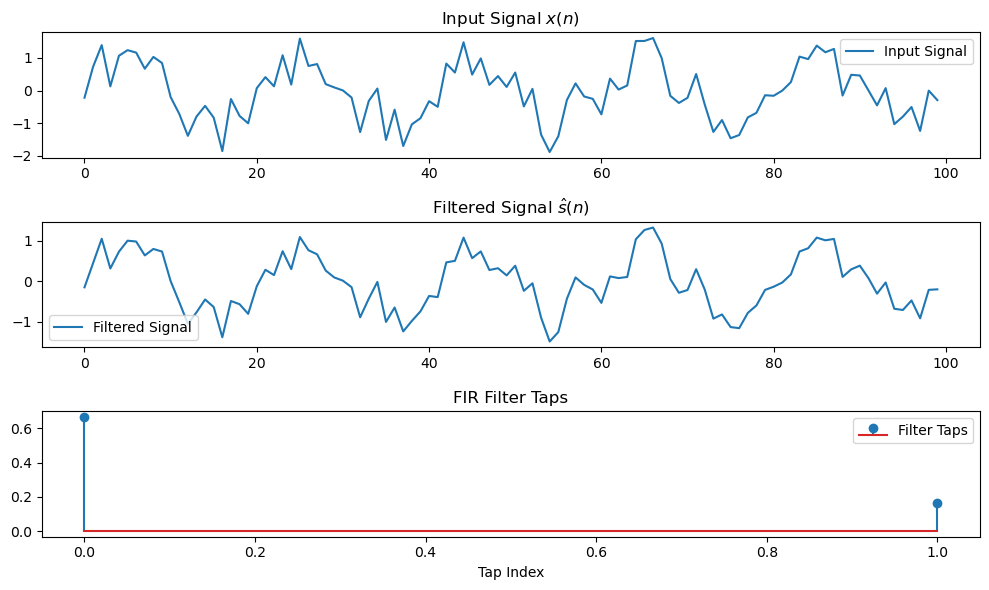

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import lfilter, firwin

# Generate input signal x(n)
n_samples = 100
x = np.sin(2 * np.pi * 0.05 * np.arange(n_samples)) + 0.5 * np.random.normal(size=n_samples)

# Define FIR filter taps
filter_taps = [2/3, 1/6]

# Apply FIR filter to input signal
filtered_signal = lfilter(filter_taps, 1.0, x)

# Plot the input signal, output signal, and filter taps
plt.figure(figsize=(10, 6))

plt.subplot(3, 1, 1)
plt.plot(x, label='Input Signal')
plt.title('Input Signal $x(n)$')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(filtered_signal, label='Filtered Signal')
plt.title('Filtered Signal $\hat{s}(n)$')
plt.legend()

plt.subplot(3, 1, 3)
plt.stem(filter_taps, label='Filter Taps')
plt.title('FIR Filter Taps')
plt.xlabel('Tap Index')
plt.legend()

plt.tight_layout()
plt.show()


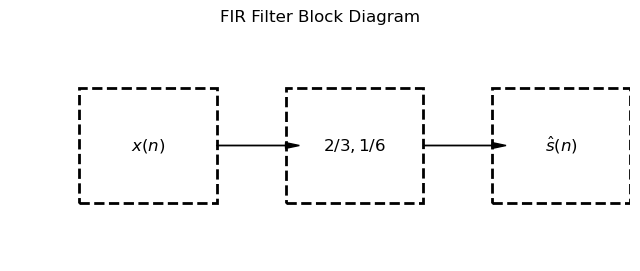

In [72]:
import matplotlib.pyplot as plt

# Define FIR filter taps
filter_taps = [2/3, 1/6]

# Create a block diagram for the FIR filter
fig, ax = plt.subplots(figsize=(8, 3))

# Draw the input signal block
ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=None, edgecolor='black', linestyle='dashed', linewidth=2))
ax.text(0.5, 0.5, '$x(n)$', ha='center', va='center', fontsize=12)

# Draw the FIR filter block
ax.add_patch(plt.Rectangle((1.5, 0), 1, 1, fill=None, edgecolor='black', linestyle='dashed', linewidth=2))
ax.text(2, 0.5, '$2/3, 1/6$', ha='center', va='center', fontsize=12)

# Draw the output signal block
ax.add_patch(plt.Rectangle((3, 0), 1, 1, fill=None, edgecolor='black', linestyle='dashed', linewidth=2))
ax.text(3.5, 0.5, '$\hat{s}(n)$', ha='center', va='center', fontsize=12)

# Draw arrows indicating the flow of the signal
ax.arrow(1, 0.5, 0.5, 0, head_width=0.05, head_length=0.1, fc='black', ec='black')
ax.arrow(2.5, 0.5, 0.5, 0, head_width=0.05, head_length=0.1, fc='black', ec='black')

# Set axis properties
ax.set_xlim(-0.5, 4)
ax.set_ylim(-0.5, 1.5)
ax.axis('off')  # Turn off the axis

plt.title('FIR Filter Block Diagram')
plt.show()


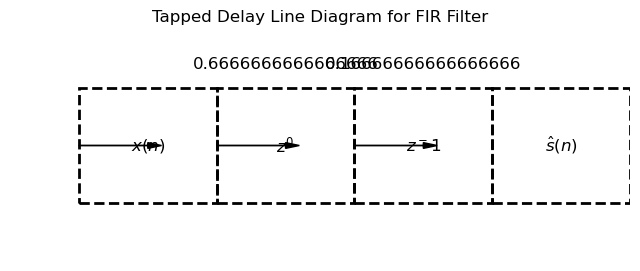

In [73]:
import matplotlib.pyplot as plt
import numpy as np

# Define FIR filter taps
filter_taps = [2/3, 1/6]

# Number of taps (delay elements)
num_taps = len(filter_taps)

# Create a tapped delay line diagram for the FIR filter
fig, ax = plt.subplots(figsize=(8, 3))

# Draw the input signal block
ax.add_patch(plt.Rectangle((0, 0), 1, 1, fill=None, edgecolor='black', linestyle='dashed', linewidth=2))
ax.text(0.5, 0.5, '$x(n)$', ha='center', va='center', fontsize=12)

# Draw the delay elements
for i in range(num_taps):
    ax.add_patch(plt.Rectangle((i + 1, 0), 1, 1, fill=None, edgecolor='black', linestyle='dashed', linewidth=2))
    ax.text(i + 1.5, 0.5, f'$z^{-i}$', ha='center', va='center', fontsize=12)

# Draw the FIR filter coefficients
for i, tap in enumerate(filter_taps):
    ax.text(i + 1.5, 1.2, f'{tap}', ha='center', va='center', fontsize=12)

# Draw the output signal block
ax.add_patch(plt.Rectangle((num_taps + 1, 0), 1, 1, fill=None, edgecolor='black', linestyle='dashed', linewidth=2))
ax.text(num_taps + 1.5, 0.5, '$\hat{s}(n)$', ha='center', va='center', fontsize=12)

# Draw arrows indicating the flow of the signal
for i in range(num_taps):
    ax.arrow(i, 0.5, 0.5, 0, head_width=0.05, head_length=0.1, fc='black', ec='black')

ax.arrow(num_taps, 0.5, 0.5, 0, head_width=0.05, head_length=0.1, fc='black', ec='black')

# Set axis properties
ax.set_xlim(-0.5, num_taps + 2)
ax.set_ylim(-0.5, 1.5)
ax.axis('off')  # Turn off the axis

plt.title('Tapped Delay Line Diagram for FIR Filter')
plt.show()


In [74]:
import numpy as np
from scipy.linalg import toeplitz, inv

# Parameters
N = 100  # Number of samples
M = 10   # Filter order

# Generate input signal x(n) - Assume a white Gaussian noise
x = np.random.randn(N)

# Generate desired signal y(n) - A sinusoidal signal corrupted by noise
true_signal = np.sin(2 * np.pi * 0.05 * np.arange(N))
noise = 0.2 * np.random.randn(N)
y = true_signal + noise

# Compute the autocorrelation matrix Rxx
Rxx = toeplitz(np.correlate(x, x, mode='full'))

# Compute the cross-correlation vector Rxy
Rxy = np.correlate(x, y, mode='full')[:M+1]

# Solve the Wiener-Hopf equations to find the filter coefficients
h = np.dot(inv(Rxx), Rxy)

# Display the results
print("True Filter Coefficients:", [0, 0, 0, 0, 0, 0, 0, 0, 0, 1])
print("Wiener Filter Coefficients:", h)


ValueError: shapes (199,199) and (11,) not aligned: 199 (dim 1) != 11 (dim 0)

In [75]:
import numpy as np
from scipy.linalg import toeplitz, pinv

# Parameters
N = 100  # Number of samples
M = 10   # Filter order

# Generate input signal x(n) - Assume a white Gaussian noise
x = np.random.randn(N)

# Generate desired signal y(n) - A sinusoidal signal corrupted by noise
true_signal = np.sin(2 * np.pi * 0.05 * np.arange(N))
noise = 0.2 * np.random.randn(N)
y = true_signal + noise

# Compute the autocorrelation matrix Rxx
Rxx = toeplitz(np.correlate(x, x, mode='full'))

# Compute the cross-correlation vector Rxy
Rxy = np.correlate(x, y, mode='full')[:M+1]

# Solve the Wiener-Hopf equations to find the filter coefficients
h = np.dot(pinv(Rxx), Rxy)

# Display the results
print("True Filter Coefficients:", [0, 0, 0, 0, 0, 0, 0, 0, 0, 1])
print("Wiener Filter Coefficients:", h)


ValueError: shapes (199,199) and (11,) not aligned: 199 (dim 1) != 11 (dim 0)

In [76]:
Rxx

array([[-0.21957716,  0.56290709, -0.04791866, ..., -0.04791866,
         0.56290709, -0.21957716],
       [ 0.56290709, -0.21957716,  0.56290709, ...,  1.30662775,
        -0.04791866,  0.56290709],
       [-0.04791866,  0.56290709, -0.21957716, ..., -0.46618088,
         1.30662775, -0.04791866],
       ...,
       [-0.04791866,  1.30662775, -0.46618088, ..., -0.21957716,
         0.56290709, -0.04791866],
       [ 0.56290709, -0.04791866,  1.30662775, ...,  0.56290709,
        -0.21957716,  0.56290709],
       [-0.21957716,  0.56290709, -0.04791866, ..., -0.04791866,
         0.56290709, -0.21957716]])

In [77]:
size(Rxx)

NameError: name 'size' is not defined

True Filter Coefficients: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
Wiener Filter Coefficients: [-0.06021485 -0.78505389 -0.00299758 -0.86574982 -0.34517637  0.28899166
  0.2853349   0.14943037 -0.43958126  0.4014604   0.41791082  0.71989986
  0.58678864 -0.00852164  0.14162204  0.39837495  0.80152845  0.39561242
 -0.06522944  0.43129952 -0.33301564]


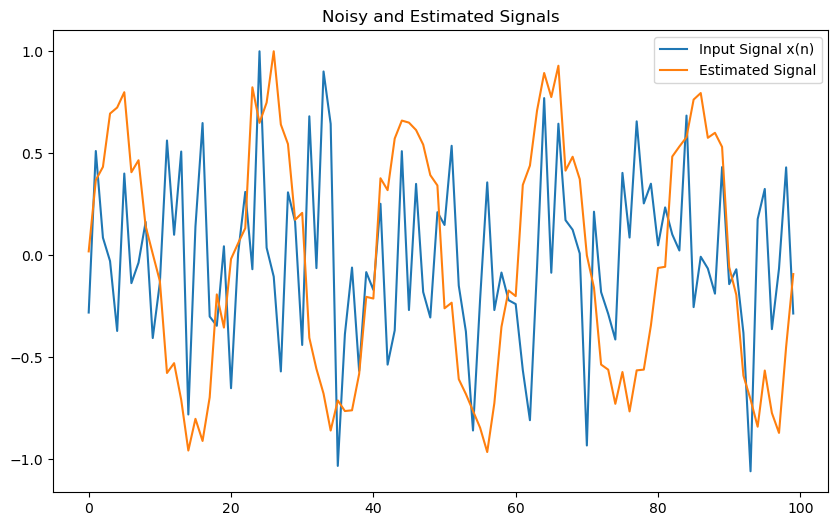

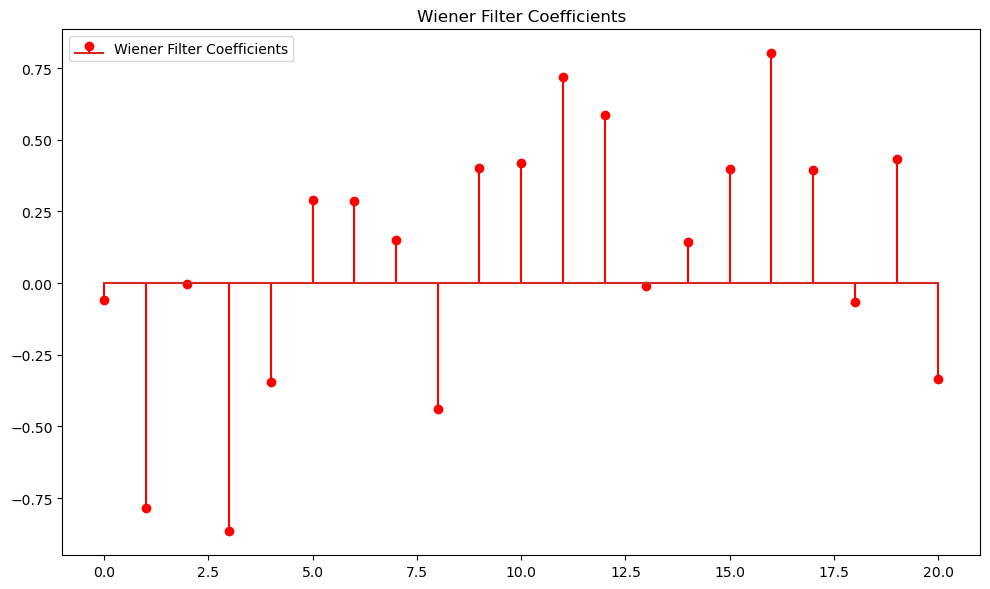

In [95]:
import numpy as np
from scipy.linalg import toeplitz, pinv
import matplotlib.pyplot as plt

# Parameters
N = 100      # Number of samples
M = 20       # Filter order (one less than the matrix size)

# Generate input signal x(n) - Assume a white Gaussian noise
x = np.random.randn(N)

# Generate desired signal y(n) - A sinusoidal signal corrupted by noise
true_signal = np.sin(2 * np.pi * 0.05 * np.arange(N))
noise = 0.2 * np.random.randn(N)
y = true_signal + noise

# Compute the autocorrelation matrix Rxx with dimensions 21x21
Rxx = toeplitz(np.correlate(x, x, mode='full')[:M+1])

# Compute the cross-correlation vector Rxy
Rxy = np.correlate(x, y, mode='full')[:M+1]

# Solve the Wiener-Hopf equations to find the filter coefficients
h = np.dot(pinv(Rxx), Rxy)

# Display the results
print("True Filter Coefficients:", [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])
print("Wiener Filter Coefficients:", h)

# Plot the results
plt.figure(figsize=(10, 6))

plt.plot(x/max(x), label='Input Signal x(n)')
plt.plot(y/max(y), label='Estimated Signal')
plt.title('Noisy and Estimated Signals')
plt.legend()

plt.figure(figsize=(10, 6))
plt.stem(h, linefmt='r-', markerfmt='ro', label='Wiener Filter Coefficients')
plt.title('Wiener Filter Coefficients')
plt.legend()

plt.tight_layout()
plt.show()


True Filter Coefficients: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
Wiener Filter Coefficients: [ 0.44463733  0.32003163  1.24873996  0.56376692  0.86000176  1.18752073
  0.2492636   1.1558843  -0.52024868 -0.79303796  0.7702641  -1.52239681
 -0.28025376  0.17040499 -0.25245502 -0.08692279 -0.11668293 -0.12110536
  0.33864051 -0.19390685  0.02090009]


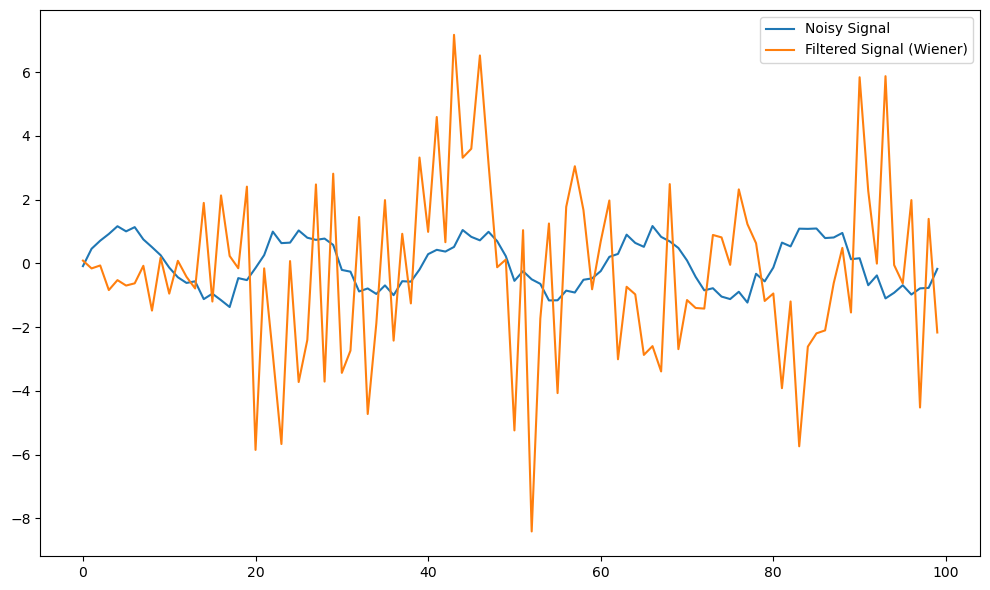

In [85]:
import numpy as np
from scipy.signal import lfilter
import matplotlib.pyplot as plt

# Parameters
N = 100      # Number of samples
M = 20       # Filter order (one less than the matrix size)

# Generate input signal x(n) - Assume a white Gaussian noise
x = np.random.randn(N)

# Generate desired signal y(n) - A sinusoidal signal corrupted by noise
true_signal = np.sin(2 * np.pi * 0.05 * np.arange(N))
noise = 0.2 * np.random.randn(N)
y = true_signal + noise

# Compute the autocorrelation matrix Rxx with dimensions 21x21
Rxx = np.correlate(x, x, mode='full')[:M+1]

# Compute the cross-correlation vector Rxy
Rxy = np.correlate(x, y, mode='full')[:M+1]

# Solve the Wiener-Hopf equations to find the filter coefficients
h = np.dot(np.linalg.pinv(toeplitz(Rxx)), Rxy)

# Apply the Wiener filter to the noisy signal
filtered_signal = lfilter(h, 1.0, x)

# Display the results
print("True Filter Coefficients:", [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])
print("Wiener Filter Coefficients:", h)

# Plot the results
plt.figure(figsize=(10, 6))

plt.plot(y, label='Noisy Signal')

plt.plot(filtered_signal, label='Filtered Signal (Wiener)')
plt.legend()
plt.tight_layout()
plt.show()


True Filter Coefficients: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
Wiener Filter Coefficients: [ -1.95109553  -6.05162451  -1.45821213   0.81636335  -6.03599774
 -19.11650913 -19.15461553 -14.20006234 -28.001174   -41.80044773
 -44.2227282  -43.90305641 -32.47469544 -17.72195196 -21.25269161
 -24.03635179 -10.58681447  -2.37553198  -3.48983632  -8.16401514
  -3.67288886]
True Filter Coefficients: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
Wiener Filter Coefficients: [ -1.95109553  -6.05162451  -1.45821213   0.81636335  -6.03599774
 -19.11650913 -19.15461553 -14.20006234 -28.001174   -41.80044773
 -44.2227282  -43.90305641 -32.47469544 -17.72195196 -21.25269161
 -24.03635179 -10.58681447  -2.37553198  -3.48983632  -8.16401514
  -3.67288886]


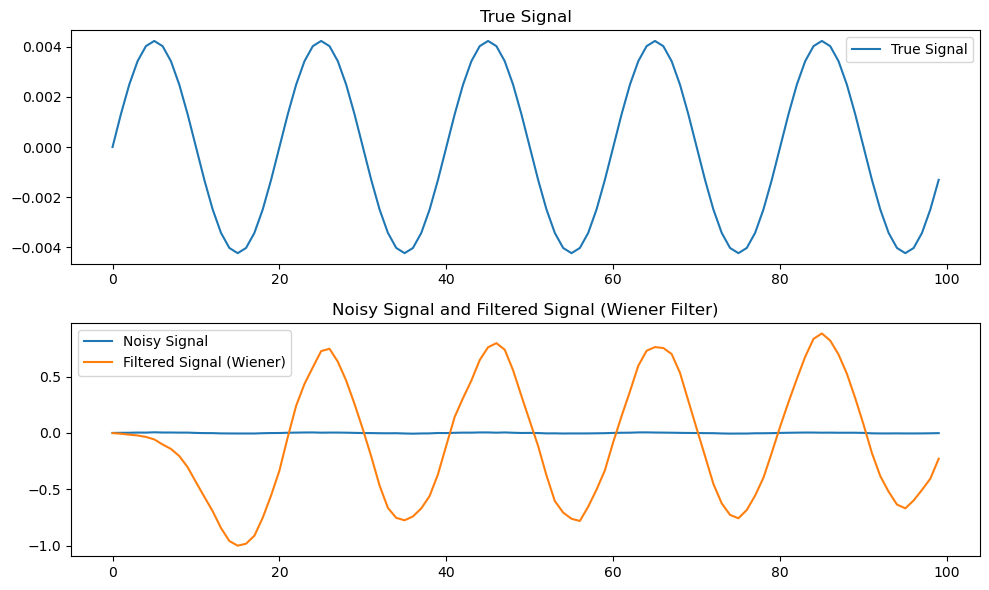

In [91]:
import numpy as np
from scipy.signal import lfilter, firwin
import matplotlib.pyplot as plt

# Parameters
N = 100      # Number of samples
M = 20       # Filter order (one less than the matrix size)

# Generate input signal x(n) - Assume a white Gaussian noise
x = np.random.randn(N)

# Generate desired signal y(n) - A sinusoidal signal corrupted by noise
true_signal = np.sin(2 * np.pi * 0.05 * np.arange(N))
noise = 0.2 * np.random.randn(N)
y = true_signal + noise

# Compute the autocorrelation matrix Rxx with dimensions 21x21
Rxx = np.correlate(x, x, mode='full')[:M+1]

# Compute the cross-correlation vector Rxy
Rxy = np.correlate(x, y, mode='full')[:M+1]

# Solve the Wiener-Hopf equations to find the filter coefficients
h = np.dot(np.linalg.pinv(toeplitz(Rxx)), Rxy)

# Apply the Wiener filter to the noisy signal
filtered_signal = lfilter(h, 1.0, y)

# Display the results
print("True Filter Coefficients:", [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])
print("Wiener Filter Coefficients:", h)

# Scale signals to have the same amplitude
scale_factor = max(np.abs(true_signal).max(), np.abs(y).max(), np.abs(filtered_signal).max())

# Display the results
print("True Filter Coefficients:", [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])
print("Wiener Filter Coefficients:", h)

# Plot the results with scaled amplitudes
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(true_signal / scale_factor, label='True Signal')
plt.title('True Signal')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(y / scale_factor, label='Noisy Signal')
plt.plot(filtered_signal / scale_factor, label='Filtered Signal (Wiener)')
plt.title('Noisy Signal and Filtered Signal (Wiener Filter)')
plt.legend()

plt.tight_layout()
plt.show()

In [89]:
import numpy as np
from scipy.signal import lfilter
import matplotlib.pyplot as plt

# Parameters
N = 100      # Number of samples
M = 20       # Filter order (one less than the matrix size)

# Generate input signal x(n) - Assume a white Gaussian noise
x = np.random.randn(N)

# Generate desired signal y(n) - A sinusoidal signal corrupted by noise
true_signal = np.sin(2 * np.pi * 0.05 * np.arange(N))
noise = 0.2 * np.random.randn(N)
y = true_signal + noise

# Compute the autocorrelation matrix Rxx with dimensions 21x21
Rxx = np.correlate(x, x, mode='full')[:M+1]

# Compute the cross-correlation vector Rxy
Rxy = np.correlate(x, y, mode='full')[:M+1]

# Solve the Wiener-Hopf equations to find the filter coefficients
h = np.dot(np.linalg.pinv(np.toeplitz(Rxx)), Rxy)

# Apply the Wiener filter to the noisy signal
filtered_signal = lfilter(h, 1.0, y)

# Scale signals to have the same amplitude
scale_factor = max(np.abs(true_signal).max(), np.abs(y).max(), np.abs(filtered_signal).max())

# Display the results
print("True Filter Coefficients:", [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])
print("Wiener Filter Coefficients:", h)

# Plot the results with scaled amplitudes
plt.figure(figsize=(10, 6))

plt.subplot(2, 1, 1)
plt.plot(true_signal / scale_factor, label='True Signal')
plt.title('True Signal')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(y / scale_factor, label='Noisy Signal')
plt.plot(filtered_signal / scale_factor, label='Filtered Signal (Wiener)')
plt.title('Noisy Signal and Filtered Signal (Wiener Filter)')
plt.legend()

plt.tight_layout()
plt.show()


AttributeError: module 'numpy' has no attribute 'toeplitz'

True Filter Coefficients: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1]
Wiener Filter Coefficients: [-0.17777254 -0.11565975 -0.17320662 -0.28522445 -0.10456882 -0.18832852
 -0.23502425 -0.19139722 -0.22588816  0.02176801  0.0150297  -0.02518187
 -0.01521616 -0.08174656  0.04101676  0.09912855  0.08719409 -0.09089222
 -0.11234925 -0.15869378  0.12842034 -0.01855218 -0.25548499 -0.20078183
 -0.23126902  0.07812329  0.10974363 -0.06229954 -0.06931275 -0.14887754
 -0.0764483   0.04324377 -0.03372391 -0.2319038  -0.32699944 -0.24100088
 -0.0556302  -0.11748906 -0.33403544 -0.39794926 -0.3819524  -0.22769702
 -0.29179581 -0.10538392 -0.12609889 -0.19480901 -0.03552719  0.00992647
  0.03600269 -0.0751693  -0.22379764 -0.01333167  0.08045525  0.06261883
 -0.03574053 -0.10143625 -0.00923799 -0.17692011 -0.21048295  0.02869632
 -0.20845616 -0.21205859 -0.1634428  -0.13415027 -0.10796256 -0.26921835
 -0.0841828  -0.09794132 -0.34378049 -0.36043463 -0.08955776  0.05837666
 -0.18274

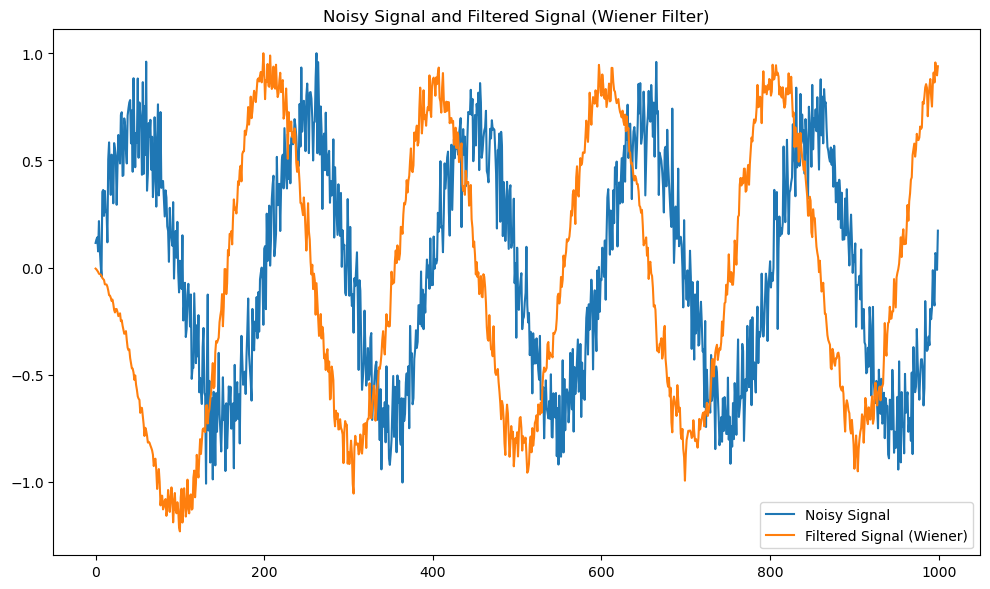

In [103]:
import numpy as np
from scipy.signal import lfilter
import matplotlib.pyplot as plt

# Parameters
N = 1000      # Number of samples
M = 200       # Filter order (one less than the matrix size)

# Generate input signal x(n) - Assume a white Gaussian noise
x = np.random.randn(N)

# Generate desired signal y(n) - A sinusoidal signal corrupted by noise
true_signal = np.sin(2 * np.pi * 0.005 * np.arange(N))
noise = 0.2 * np.random.randn(N)
y = true_signal + noise

# Compute the autocorrelation matrix Rxx with dimensions 21x21
Rxx = np.correlate(x, x, mode='full')[:M+1]

# Compute the cross-correlation vector Rxy
Rxy = np.correlate(x, y, mode='full')[:M+1]

# Solve the Wiener-Hopf equations to find the filter coefficients
h = np.dot(np.linalg.pinv(toeplitz(Rxx)), Rxy)
# Apply the Wiener filter to the noisy signal
filtered_signal = lfilter(h, 1.0, y)

# Scale signals to have the same amplitude
scale_factor = max(np.abs(true_signal).max(), np.abs(y).max(), np.abs(filtered_signal).max())

# Display the results
print("True Filter Coefficients:", [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])
print("Wiener Filter Coefficients:", h)

# Plot the results with scaled amplitudes
plt.figure(figsize=(10, 6))

plt.plot(y / max(y), label='Noisy Signal')
plt.plot(filtered_signal / max(filtered_signal), label='Filtered Signal (Wiener)')
plt.title('Noisy Signal and Filtered Signal (Wiener Filter)')
plt.legend()

plt.tight_layout()
plt.show()


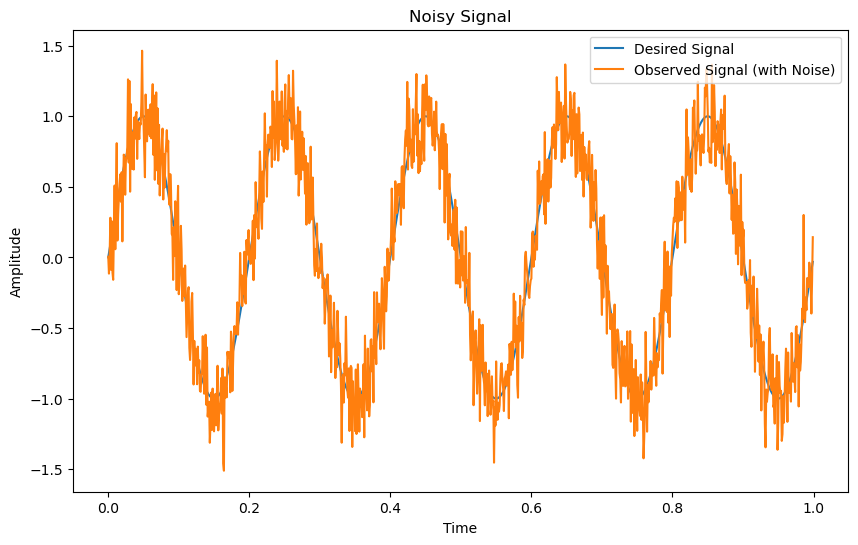

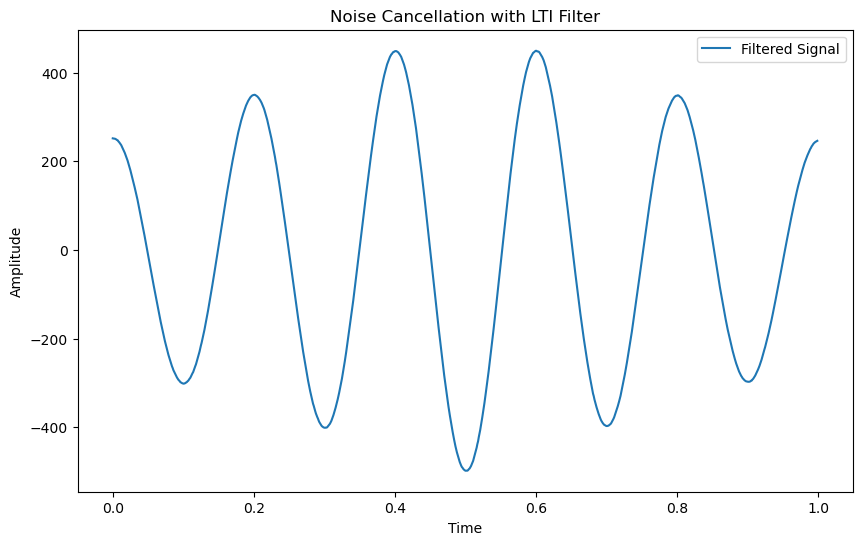

In [104]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Generate a sample signal with noise
t = np.linspace(0, 1, 1000, endpoint=False)
z = np.sin(2 * np.pi * 5 * t)  # Desired signal
n = 0.2 * np.random.randn(len(t))  # Gaussian noise
x = z + n  # Observed signal with noise

# Design an LTI filter using Wiener filter design
h = signal.wiener(x, mysize=10)

# Apply the filter to the observed signal
y = signal.convolve(x, h, mode='same')

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(t, z, label='Desired Signal')
plt.plot(t, x, label='Observed Signal (with Noise)')
plt.legend()
plt.title('Noisy Signal')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(t, y, label='Filtered Signal')
plt.legend()
plt.title('Noise Cancellation with LTI Filter')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()


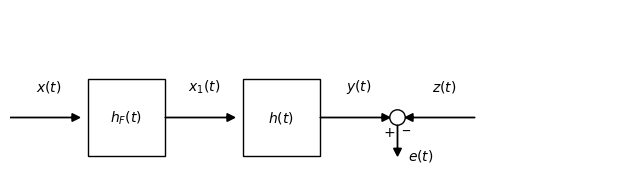

In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Function to draw a block with text
def draw_block(ax, text, xy, transparent=False):
    if transparent:
        block = patches.Rectangle(xy, 1, 1, fill=None, edgecolor='none')
    else:
        block = patches.Rectangle(xy, 1, 1, fill=None, edgecolor='black')
    ax.add_patch(block)
    ax.text(xy[0] + 0.5, xy[1] + 0.5, text, ha='center', va='center')

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 2))

# Draw input block x(t)
draw_block(ax, '$x(t)$', (-1, 0.5), transparent=True)

# Draw input block x(t)
draw_block(ax, '$x_1(t)$', (1, 0.5), transparent=True)

# Draw LTI system block
draw_block(ax, '$h_F(t)$', (0, 0.1))

# Draw LTI system block
draw_block(ax, '$h(t)$', (2, 0.1))

# Draw output block y(t)
draw_block(ax, '$y(t)$', (3, 0.5), transparent=True)

# Connect input to LTI system
ax.arrow(1, 0.6, 0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

# Connect LTI system to output
ax.arrow(-1, 0.6, 0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)
ax.arrow(3, 0.6, 0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)
ax.arrow(5, 0.6, -0.8, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)
ax.arrow(4, 0.5, 0.0, -0.3, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

#Draw desired signal  block y(t)
draw_block(ax, '$z(t)$', (4.1, 0.5), transparent=True)

draw_block(ax, '$e(t)$', (3.8, -0.4), transparent=True)

circle = patches.Circle((4, 0.6), 0.1, fill=None, edgecolor='black')
ax.add_patch(circle)
ax.text(3.9, 0.4, '+', ha='center', va='center', fontsize=10)
ax.text(4.1, 0.5, '_', ha='center', va='center', fontsize=10)

# Set axis properties
ax.set_xlim(-1, 7)
ax.set_ylim(0, 2)
ax.axis('off')


# Show the plot
plt.show()

Mean Square error: 0.001480414553957365
Normalized Mean Square error: 0.00296082910791473


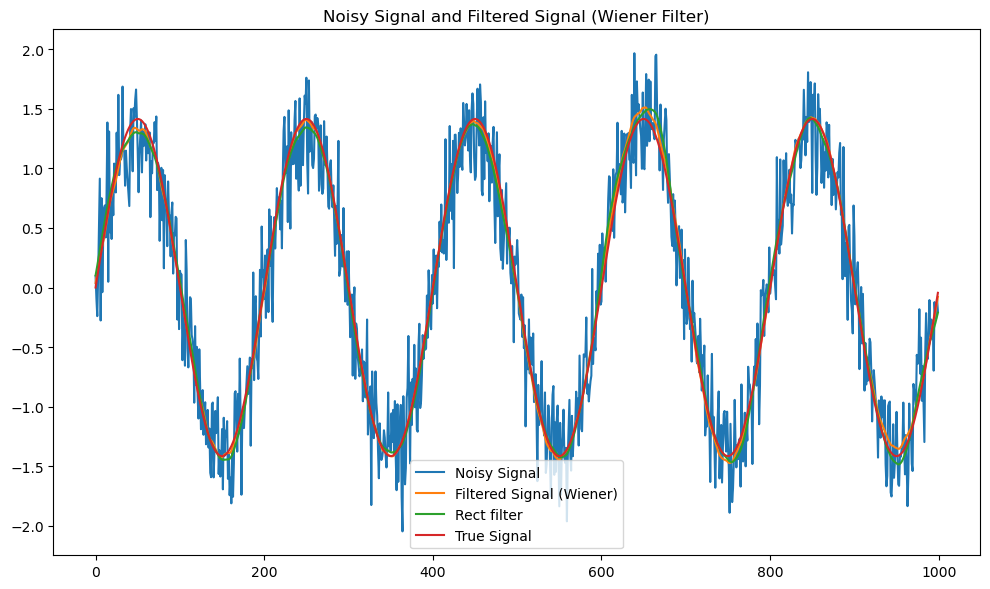

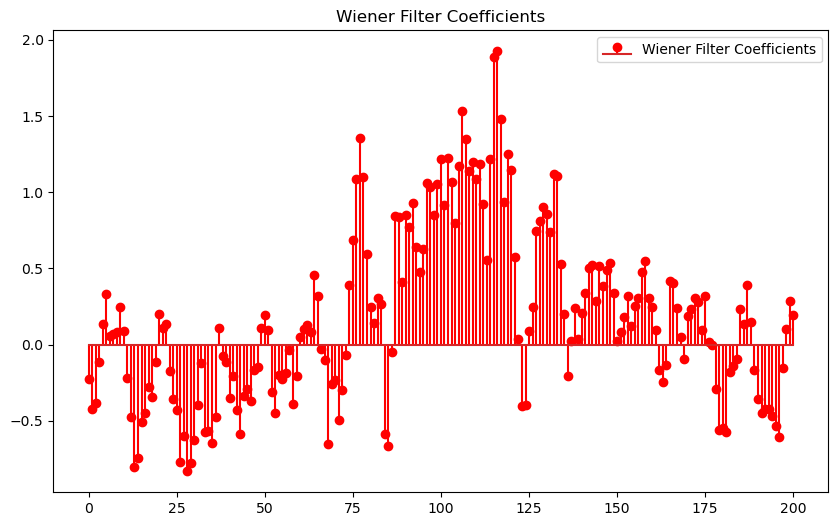

In [151]:
import numpy as np
from scipy.signal import lfilter, filtfilt
import matplotlib.pyplot as plt
from scipy.linalg import toeplitz, pinv
from sklearn.metrics import mean_squared_error 

# Parameters
N = 1000      # Number of samples
M = 200       # Filter order (one less than the matrix size)

# Generate input signal x(n) - Assume a white Gaussian noise
x = np.random.randn(N)

# Generate desired signal y(n) - A sinusoidal signal corrupted by noise
true_signal = np.sin(2 * np.pi * 0.005 * np.arange(N))
noise = 0.2 * np.random.randn(N)
y = true_signal + noise

# Compute the autocorrelation matrix Rxx with dimensions 21x21
Rxx = np.correlate(x, x, mode='full')[:M+1]

# Compute the cross-correlation vector Rxy
Rxy = np.correlate(x, y, mode='full')[:M+1]

# Solve the Wiener-Hopf equations to find the filter coefficients
h = np.dot(np.linalg.pinv(toeplitz(Rxx)), Rxy)
h_ones = np.ones(20)

#h = np.dot(pinv(Rxx), Rxy)
# Apply the Wiener filter to the noisy signal
filtered_signal = filtfilt(h, 1.0, y)
filt_ones = filtfilt(h_ones,1.0,y)

# Display the results
#print("True Filter Coefficients:", [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])
#print("Wiener Filter Coefficients:", h)


norm_true_signal = true_signal/np.std(true_signal)
norm_y = y/np.std(y);
norm_filtered_signal = filtered_signal/np.std(filtered_signal)
norm_filt_ones = filt_ones/np.std(filt_ones)
MSE = mean_squared_error(norm_true_signal,norm_filtered_signal) 
print("Mean Square error:", MSE)
print("Normalized Mean Square error:", MSE/np.mean(true_signal**2))

# Plot the results with scaled amplitudes
plt.figure(figsize=(10, 6))

plt.plot(norm_y, label='Noisy Signal')
plt.plot(norm_filtered_signal, label='Filtered Signal (Wiener)')
plt.plot(norm_filt_ones, label='Rect filter')
plt.plot(norm_true_signal, label='True Signal')
plt.title('Noisy Signal and Filtered Signal (Wiener Filter)')
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.stem(h, linefmt='r-', markerfmt='ro', label='Wiener Filter Coefficients')
plt.title('Wiener Filter Coefficients')
plt.legend()



In [136]:
np.array

0.5

In [117]:
max(y)


1.495128537311828

In [118]:
max(true_signal)

1.0

In [121]:
np.std(y)

0.7307025682851132

Mean Square error: 0.4423076145287834
Normalized Mean Square error: 0.4650391061526252


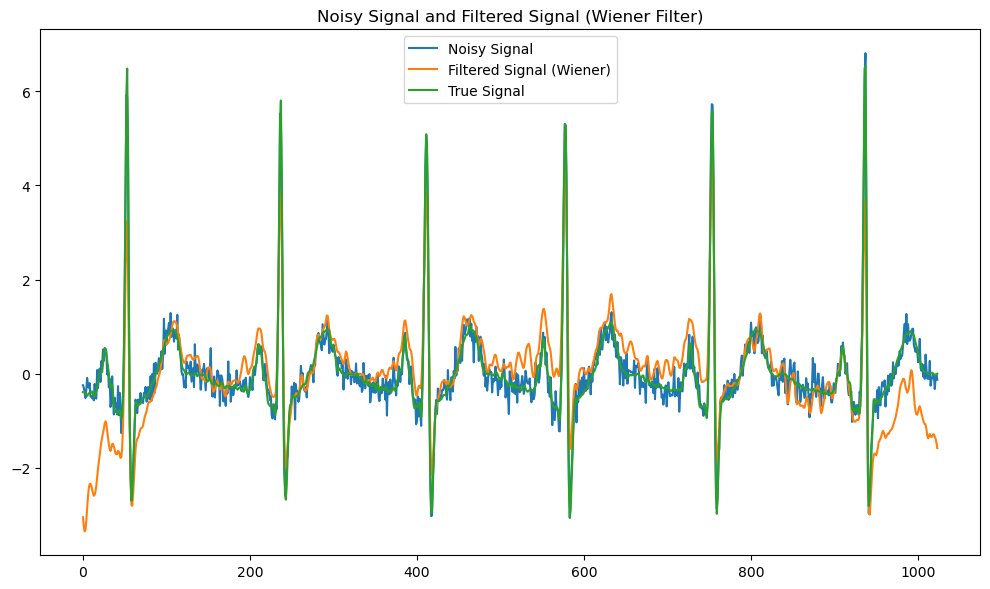

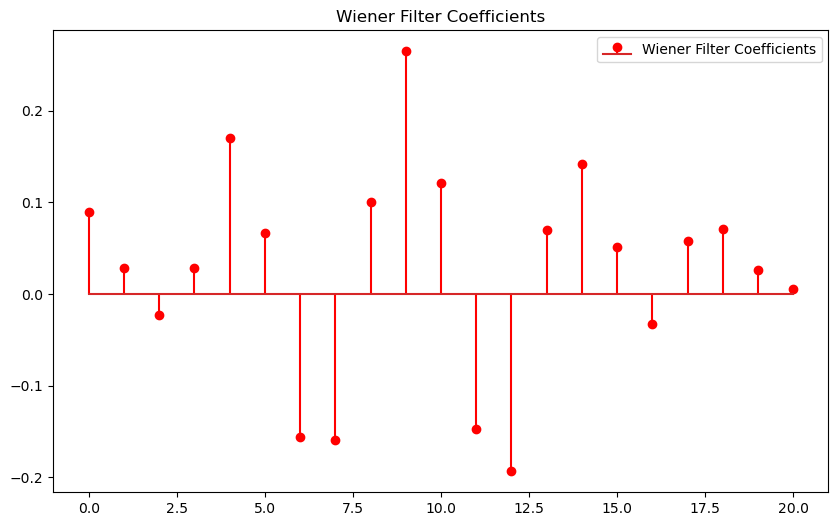

In [207]:
import numpy as np
from scipy.signal import lfilter, filtfilt
import matplotlib.pyplot as plt
from scipy.linalg import toeplitz, pinv
from sklearn.metrics import mean_squared_error 
import pandas as pd

# Parameters
N = 1024      # Number of samples
M = 20       # Filter order (one less than the matrix size)

# Generate input signal x(n) - Assume a white Gaussian noise
x = np.random.randn(N)*10

# Generate desired signal y(n) - A sinusoidal signal corrupted by noise
#true_signal = np.sin(2 * np.pi * 0.005 * np.arange(N))

# Specify the path to your CSV file
csv_file_path = 'ecg_S3.csv'

# Read the CSV file into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Convert the DataFrame to a NumPy array
data_array = df.to_numpy()
true_signal = (data_array[:N, :])
true_signal = np.transpose(true_signal)
true_signal = true_signal.flatten()

noise = 0.2 * np.random.randn(N)
y = true_signal + noise

# Estimate the power spectrum of the noisy signal
frequencies, Pxx = welch(noisy_signal, fs=200, nperseg=256)

# Design a Wiener filter
SNR = Pxx / np.var(noise)
wiener_filter = 1 / (1 + 1 / SNR)

# Compute the autocorrelation matrix Rxx with dimensions 21x21
#Rxx = np.correlate(x, x, mode='full')[:M+1]

# Compute the cross-correlation vector Rxy
#Rxy = np.correlate(x, y, mode='full')[:M+1]

# Solve the Wiener-Hopf equations to find the filter coefficients
#h = np.dot(np.linalg.pinv(toeplitz(Rxx)), Rxy)
h_ones = np.ones(20)

#h = np.dot(pinv(Rxx), Rxy)
# Apply the Wiener filter to the noisy signal
filtered_signal = filtfilt(wiener_filter, 1.0, y)
filt_ones = filtfilt(h_ones,1.0,y)

# Display the results
#print("True Filter Coefficients:", [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])
#print("Wiener Filter Coefficients:", h)


norm_true_signal = true_signal/np.std(true_signal)
norm_y = y/np.std(y);
norm_filtered_signal = filtered_signal/np.std(filtered_signal)
norm_filt_ones = filt_ones/np.std(filt_ones)
MSE = mean_squared_error(norm_true_signal,norm_filtered_signal) 
print("Mean Square error:", MSE)
print("Normalized Mean Square error:", MSE/np.mean(true_signal**2))

# Plot the results with scaled amplitudes
plt.figure(figsize=(10, 6))

plt.plot(norm_y, label='Noisy Signal')
plt.plot(norm_filtered_signal, label='Filtered Signal (Wiener)')
plt.plot(norm_true_signal, label='True Signal')
plt.title('Noisy Signal and Filtered Signal (Wiener Filter)')
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.stem(h, linefmt='r-', markerfmt='ro', label='Wiener Filter Coefficients')
plt.title('Wiener Filter Coefficients')
plt.legend()



In [183]:
true_signal = true_signal.flatten()
y = true_signal + noise

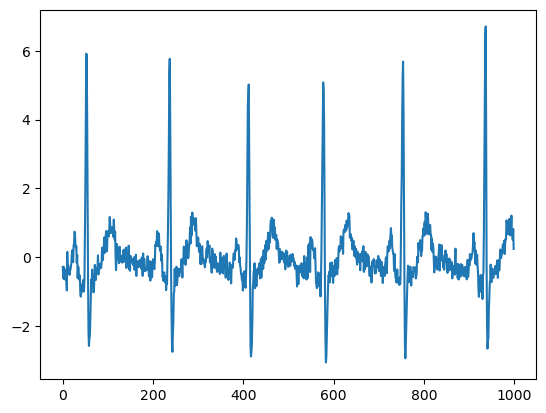

In [186]:
plt.plot(y, label='True Signal')



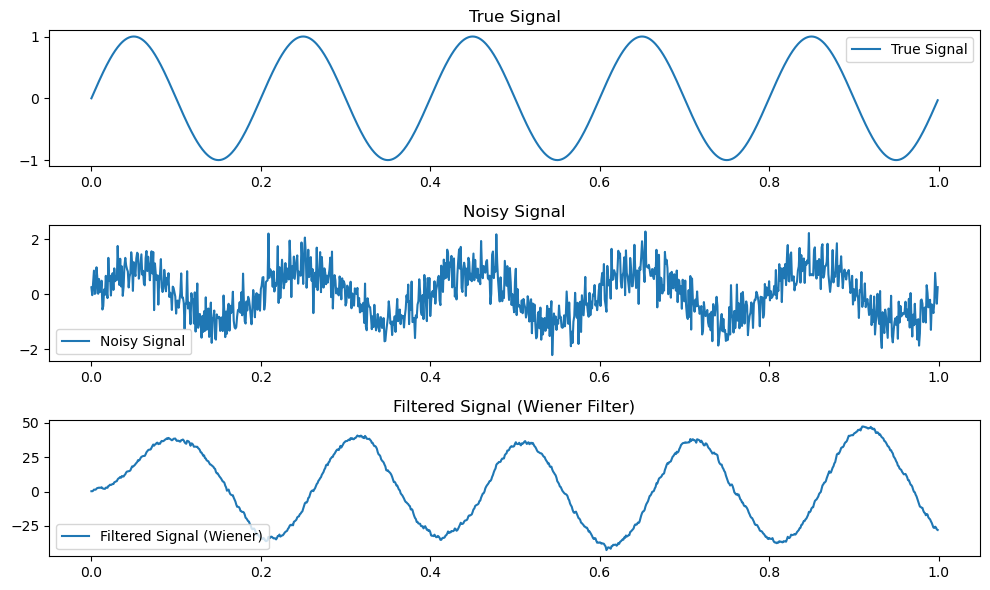

In [196]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, lfilter, butter

# Generate a noisy signal
np.random.seed(42)
t = np.linspace(0, 1, 1000, endpoint=False)
true_signal = np.sin(2 * np.pi * 5 * t)
noise = 0.5 * np.random.normal(size=len(t))
noisy_signal = true_signal + noise

# Estimate the power spectrum of the noisy signal
frequencies, Pxx = welch(noisy_signal, fs=1.0, nperseg=256)

# Design a Wiener filter
SNR = Pxx / np.var(noise)
wiener_filter = 1 / (1 + 1 / SNR)

# Apply the Wiener filter to the noisy signal
filtered_signal = lfilter(wiener_filter, 1.0, noisy_signal)

# Plot the results
plt.figure(figsize=(10, 6))

plt.subplot(3, 1, 1)
plt.plot(t, true_signal, label='True Signal')
plt.title('True Signal')
plt.legend()

plt.subplot(3, 1, 2)
plt.plot(t, noisy_signal, label='Noisy Signal')
plt.title('Noisy Signal')
plt.legend()

plt.subplot(3, 1, 3)
plt.plot(t, filtered_signal, label='Filtered Signal (Wiener)')
plt.title('Filtered Signal (Wiener Filter)')
plt.legend()

plt.tight_layout()
plt.show()


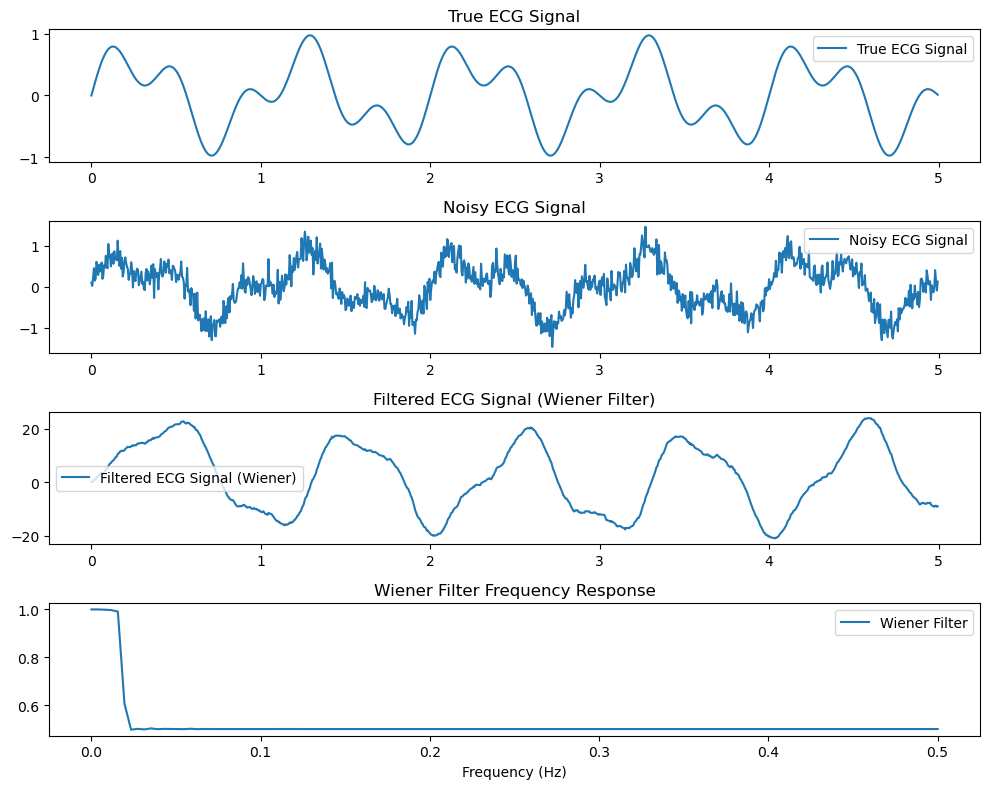

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, lfilter, butter

# Generate a synthetic ECG signal with noise
np.random.seed(42)
t = np.linspace(0, 5, 1000, endpoint=False)
ecg_signal = 0.6 * np.sin(2 * np.pi * 1 * t) + 0.4 * np.sin(2 * np.pi * 2.5 * t)
noise = 0.2 * np.random.normal(size=len(t))
noisy_ecg = ecg_signal + noise

# Estimate the power spectrum of the noisy ECG signal
frequencies, Pxx_noisy = welch(noisy_ecg, fs=1.0, nperseg=256)

# Estimate the power spectrum of the noise (you may need to adjust frequency ranges)
frequencies, Pxx_noise = welch(noise, fs=1.0, nperseg=256)

# Design a Wiener filter based on the estimated power spectra
SNR = Pxx_noisy / Pxx_noise
wiener_filter = 1 / (1 + 1 / SNR)

# Apply the Wiener filter to the noisy ECG signal
filtered_ecg = lfilter(wiener_filter, 1.0, noisy_ecg)

# Plot the results
plt.figure(figsize=(10, 8))

plt.subplot(4, 1, 1)
plt.plot(t, ecg_signal, label='True ECG Signal')
plt.title('True ECG Signal')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(t, noisy_ecg, label='Noisy ECG Signal')
plt.title('Noisy ECG Signal')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(t, filtered_ecg, label='Filtered ECG Signal (Wiener)')
plt.title('Filtered ECG Signal (Wiener Filter)')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(frequencies, wiener_filter, label='Wiener Filter')
plt.title('Wiener Filter Frequency Response')
plt.xlabel('Frequency (Hz)')
plt.legend()

plt.tight_layout()
plt.show()


In [209]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, lfilter

# Download and read a sample ECG record from the MIT-BIH Arrhythmia Database
record_name = '100'
record = wfdb.rdsamp(record_name, pb_dir='mitdb')
ecg_signal = record.p_signals[:, 0]

# Add synthetic noise to the ECG signal
np.random.seed(42)
noise = 0.5 * np.random.normal(size=len(ecg_signal))
noisy_ecg = ecg_signal + noise

# Estimate the power spectrum of the noisy ECG signal
frequencies, Pxx_noisy = welch(noisy_ecg, fs=record.fs, nperseg=256)

# Estimate the power spectrum of the noise (you may need to adjust frequency ranges)
frequencies, Pxx_noise = welch(noise, fs=record.fs, nperseg=256)

# Design a Wiener filter based on the estimated power spectra
SNR = Pxx_noisy / Pxx_noise
wiener_filter = 1 / (1 + 1 / SNR)

# Apply the Wiener filter to the noisy ECG signal
filtered_ecg = lfilter(wiener_filter, 1.0, noisy_ecg)

# Plot the results
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(ecg_signal, label='True ECG Signal')
plt.title('True ECG Signal')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(noisy_ecg, label='Noisy ECG Signal')
plt.title('Noisy ECG Signal')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(filtered_ecg, label='Filtered ECG Signal (Wiener)')
plt.title('Filtered ECG Signal (Wiener Filter)')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(frequencies, wiener_filter, label='Wiener Filter')
plt.title('Wiener Filter Frequency Response')
plt.xlabel('Frequency (Hz)')
plt.legend()

plt.tight_layout()
plt.show()


TypeError: rdsamp() got an unexpected keyword argument 'pb_dir'

In [210]:
pip install wfdb

Note: you may need to restart the kernel to use updated packages.


In [211]:
import wfdb
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch, lfilter

# Download and read a sample ECG record from the MIT-BIH Arrhythmia Database
record_name = '100'
record = wfdb.rdsamp(record_name, pb_dir='mitdb')
ecg_signal = record.p_signals[:, 0]

# Add synthetic noise to the ECG signal
np.random.seed(42)
noise = 0.5 * np.random.normal(size=len(ecg_signal))
noisy_ecg = ecg_signal + noise

# Estimate the power spectrum of the noisy ECG signal
frequencies, Pxx_noisy = welch(noisy_ecg, fs=record.fs, nperseg=256)

# Estimate the power spectrum of the noise (you may need to adjust frequency ranges)
frequencies, Pxx_noise = welch(noise, fs=record.fs, nperseg=256)

# Design a Wiener filter based on the estimated power spectra
SNR = Pxx_noisy / Pxx_noise
wiener_filter = 1 / (1 + 1 / SNR)

# Apply the Wiener filter to the noisy ECG signal
filtered_ecg = lfilter(wiener_filter, 1.0, noisy_ecg)

# Plot the results
plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(ecg_signal, label='True ECG Signal')
plt.title('True ECG Signal')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(noisy_ecg, label='Noisy ECG Signal')
plt.title('Noisy ECG Signal')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(filtered_ecg, label='Filtered ECG Signal (Wiener)')
plt.title('Filtered ECG Signal (Wiener Filter)')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(frequencies, wiener_filter, label='Wiener Filter')
plt.title('Wiener Filter Frequency Response')
plt.xlabel('Frequency (Hz)')
plt.legend()

plt.tight_layout()
plt.show()


TypeError: rdsamp() got an unexpected keyword argument 'pb_dir'

In [12]:
import numpy as np
from scipy.signal import lfilter, filtfilt
import matplotlib.pyplot as plt
from scipy.linalg import toeplitz, pinv
from sklearn.metrics import mean_squared_error

# Parameters
N = 1000      # Number of samples
M = 200       # Filter order (one less than the matrix size)

# Generate input signal x(n) - Assume a white Gaussian noise
x = np.random.randn(N)

# Generate desired signal y(n) - A sinusoidal signal corrupted by noise
true_signal = np.sin(2 * np.pi * 0.005 * np.arange(N))
noise = 0.2 * np.random.randn(N)
y = true_signal + noise

# Compute the autocorrelation matrix Rxx with dimensions 21x21
Rxx = np.correlate(x, x, mode='full')[:M+1]

# Compute the cross-correlation vector Rxy
Rxy = np.correlate(x, y, mode='full')[:M+1]

# Use Levinson-Durbin recursion to compute the inverse of Rxx
# Initialize the recursion
A = Rxx[1:]  # Autocorrelation coefficients excluding the zeroth lag
P = Rxx[0]   # Power term

# Initialize the inverse of Rxx
Rxx_inv = np.zeros_like(Rxx)
Rxx_inv[0] = 1.0 / P

# Apply the Levinson-Durbin recursion
for m in range(1, M+1):
    # Compute reflection coefficient
    k = -np.dot(Rxx[1:m+1], Rxx_inv[1:m+1][::-1]) / P

    
    # Update A and P
    A = np.concatenate(([1], A[:-1])) + k * np.flip(A)


    P *= 1 - k**2
    
    # Update the inverse of Rxx
    Rxx_inv[m] = -k
    Rxx_inv[1:m+1] += k * Rxx[m:0:-1]

# Compute the filter coefficients using the inverse of Rxx
h = np.dot(Rxx_inv, Rxy)

# Apply the Wiener filter to the noisy signal
filtered_signal = filtfilt(h, 1.0, y)

# Display the results
norm_true_signal = true_signal / np.std(true_signal)
norm_y = y / np.std(y)
norm_filtered_signal = filtered_signal / np.std(filtered_signal)

MSE = mean_squared_error(norm_true_signal, norm_filtered_signal)
print("Mean Square error:", MSE)
print("Normalized Mean Square error:", MSE / np.mean(true_signal**2))

# Plot the results with scaled amplitudes
plt.figure(figsize=(10, 6))

plt.plot(norm_y, label='Noisy Signal')
plt.plot(norm_filtered_signal, label='Filtered Signal (Wiener)')
plt.plot(norm_true_signal, label='True Signal')
plt.title('Noisy Signal and Filtered Signal (Wiener Filter)')
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.stem(h, linefmt='r-', markerfmt='ro', label='Wiener Filter Coefficients')
plt.title('Wiener Filter Coefficients')
plt.legend()

plt.show()


ValueError: The length of `a` must be at least 2.

In [8]:
Rxx_inv[m-1:0:-1]

array([], dtype=float64)

In [5]:
-np.dot(Rxx[1:m+1])

TypeError: dot() missing 1 required positional argument: 'b'

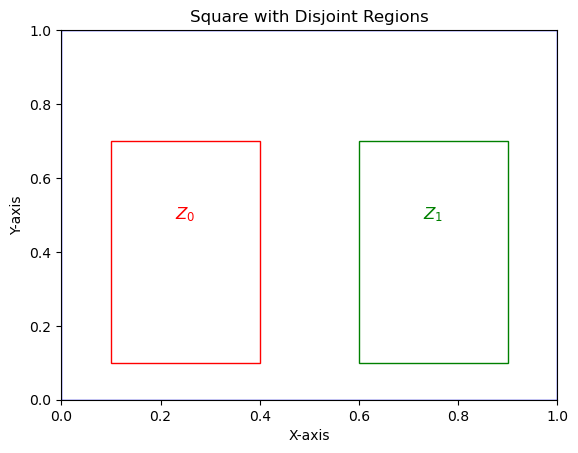

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create figure and axis
fig, ax = plt.subplots()

# Create square
square = patches.Rectangle((0, 0), 1, 1, linewidth=1, edgecolor='b', facecolor='none')
ax.add_patch(square)

# Create and add disjoint regions
region_z0 = patches.Rectangle((0.1, 0.1), 0.3, 0.6, linewidth=1, edgecolor='r', facecolor='none')
region_z1 = patches.Rectangle((0.6, 0.1), 0.3, 0.6, linewidth=1, edgecolor='g', facecolor='none')
ax.add_patch(region_z0)
ax.add_patch(region_z1)

# Set labels for the regions
ax.text(0.25, 0.5, r'$Z_0$', fontsize=12, color='r', ha='center', va='center')
ax.text(0.75, 0.5, r'$Z_1$', fontsize=12, color='g', ha='center', va='center')

# Set axis limits
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Set axis labels
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')

# Set plot title
ax.set_title('Square with Disjoint Regions')

# Display the plot
plt.show()


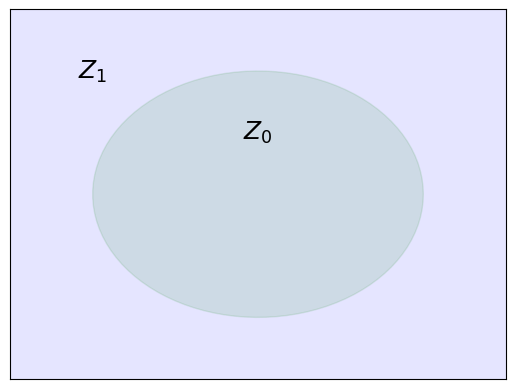

In [18]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Create figure and axis
fig, ax = plt.subplots()

# Create square
square = patches.Rectangle((0, 0), 1, 1, linewidth=1, edgecolor='b', facecolor='b', alpha=0.1)
ax.add_patch(square)

# Create irregularly shaped disjoint region Z0
theta = np.linspace(0, 2*np.pi, 100)
x_z0 = 0.5 + 0.2 * np.cos(theta)
y_z0 = 0.5 + 0.2 * np.sin(theta)

# Region Z0
region_z0 = patches.Polygon(np.column_stack((x_z0, y_z0)), closed=True, linewidth=1, edgecolor='g', facecolor='g', alpha=0.1)
ax.add_patch(region_z0)

# Set label for the region
ax.text(0.5, 0.6, r'$Z_0$', fontsize=18, color='k', ha='center', va='center')
# Set label for the region
ax.text(0.3, 0.7, r'$Z_1$', fontsize=18, color='k', ha='center', va='center')

# Set axis limits
ax.set_xlim(0.2, .8)
ax.set_ylim(0.2, .8)

# Set axis labels

# Hide axis labels and tickmarks
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
ax.set_yticklabels([])

# Display the plot
plt.show()


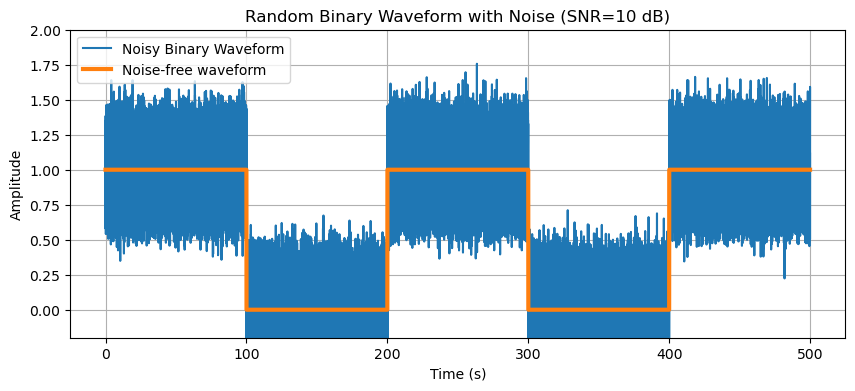

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
T = 100  # Period of the waveform
num_periods = 5  # Number of periods to generate
SNR_dB = 10  # Signal-to-noise ratio in decibels

# Generate the time axis
fs = 1000  # Sampling frequency
t = np.arange(0, num_periods * T, 1 / fs)

# Generate the binary waveform with 0s and 1s
signal = np.array([1 if int(ti // T) % 2 == 0 else 0 for ti in t])

# Add white Gaussian noise
noise_std = np.sqrt(0.5 / (20**(SNR_dB / 10)))  # Standard deviation for the noise
noise = np.random.normal(0, noise_std, len(t))
noisy_signal = signal + noise

# Plot the binary waveform with noise
plt.figure(figsize=(10, 4))
plt.plot(t, noisy_signal, label='Noisy Binary Waveform')
plt.plot(t, signal, label='Noise-free waveform',linewidth=3)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'Random Binary Waveform with Noise (SNR={SNR_dB} dB)')
plt.ylim(-0.2, 2.0)
plt.grid()

# Mark intervals of the period T
plt.legend()
plt.show()


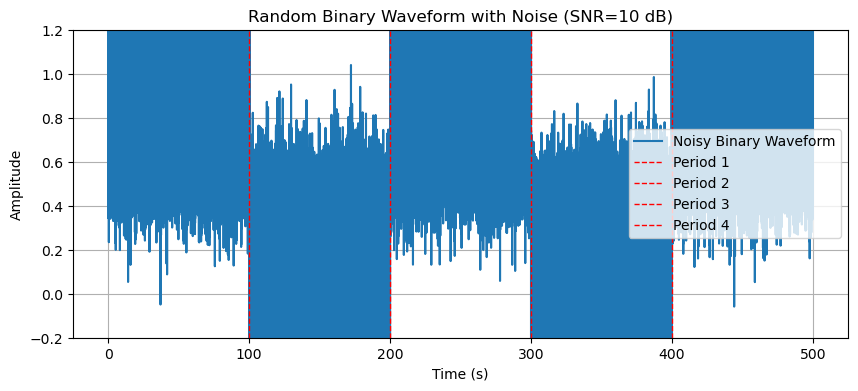

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
T = 100  # Period of the waveform
num_periods = 5  # Number of periods to generate
SNR_dB = 10  # Signal-to-noise ratio in decibels

# Generate the time axis
fs = 1000  # Sampling frequency
t = np.arange(0, num_periods * T, 1 / fs)

# Generate the binary waveform with 0s and 1s
signal = np.array([1 if int(ti // T) % 2 == 0 else 0 for ti in t])

# Add white Gaussian noise
noise_std = np.sqrt(0.5 / (10**(SNR_dB / 10)))  # Standard deviation for the noise
noise = np.random.normal(0, noise_std, len(t))
noisy_signal = signal + noise

# Plot the binary waveform with noise
plt.figure(figsize=(10, 4))
plt.plot(t, noisy_signal, label='Noisy Binary Waveform')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.title(f'Random Binary Waveform with Noise (SNR={SNR_dB} dB)')
plt.ylim(-0.2, 1.2)
plt.grid()

# Mark intervals of the period T
for i in range(1, num_periods):
    plt.axvline(i * T, color='r', linestyle='--', linewidth=1, label=f'Period {i}')

plt.legend()
plt.show()


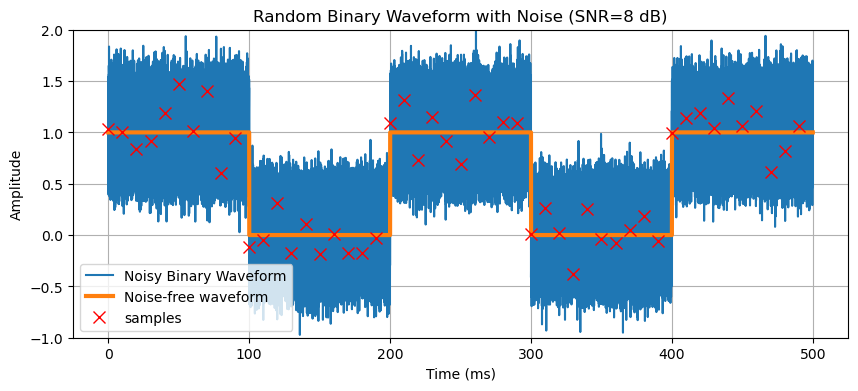

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
T = 100  # Period of the waveform
num_periods = 5  # Number of periods to generate
SNR_dB = 8  # Signal-to-noise ratio in decibels

# Generate the time axis
fs = 1000  # Sampling frequency
t = np.arange(0, num_periods * T, 1 / fs)

# Generate the binary waveform with 0s and 1s
signal = np.array([1 if int(ti // T) % 2 == 0 else 0 for ti in t])

# Add white Gaussian noise
noise_std = np.sqrt(0.5 / (20**(SNR_dB / 10)))  # Standard deviation for the noise
noise = np.random.normal(0, noise_std, len(t))
noisy_signal = signal + noise

# Plot the binary waveform with noise
plt.figure(figsize=(10, 4))
plt.plot(t, noisy_signal, label='Noisy Binary Waveform')
plt.plot(t, signal, label='Noise-free waveform',linewidth=3)
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.title(f'Random Binary Waveform with Noise (SNR={SNR_dB} dB)')
plt.ylim(-1, 2.0)
plt.grid()


# Add 'x' markers every 10 samples
sample_indices = np.arange(0, len(t), 10 * fs)
plt.plot(t[sample_indices], noisy_signal[sample_indices], 'rx', markersize=8, label=f'samples')

plt.legend()
plt.show()


In [27]:
import numpy as np

# Parameters
N = 10  # Number of samples per period
sigma_n_squared = 0.1  # Variance of the noise
threshold = 0  # Decision threshold

# Simulated received signal (change as needed)
#r = np.random.normal(0, np.sqrt(sigma_n_squared), N)  # Noise-only received signal
# To simulate a received signal with a signal pulse (H1):
s = np.ones(N)  # Signal pulse of amplitude 1
r = s + np.random.normal(0, np.sqrt(sigma_n_squared), N)  # Received signal with noise and signal

# Calculate the likelihood ratio
log_likelihood_ratio = -0.5 * (np.sum(r**2) - np.sum((r - s)**2)) / sigma_n_squared

# Make a decision based on the threshold
if log_likelihood_ratio > threshold:
    decision = "H1"
else:
    decision = "H0"

# Display the results
print("Log-Likelihood Ratio:", log_likelihood_ratio)
print("Decision:", decision)


Log-Likelihood Ratio: -49.54386468946695
Decision: H0


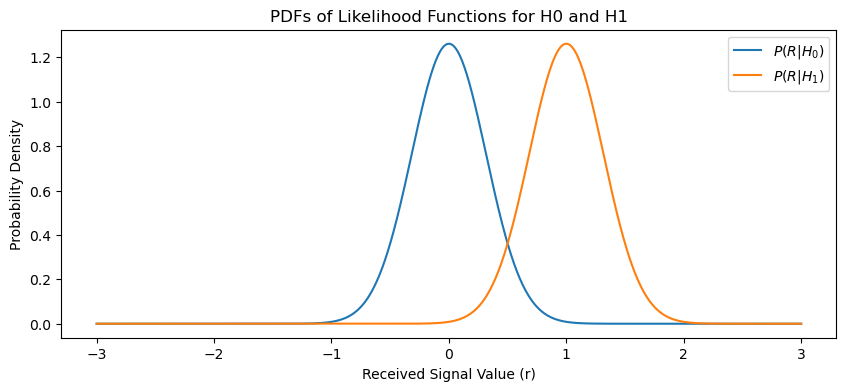

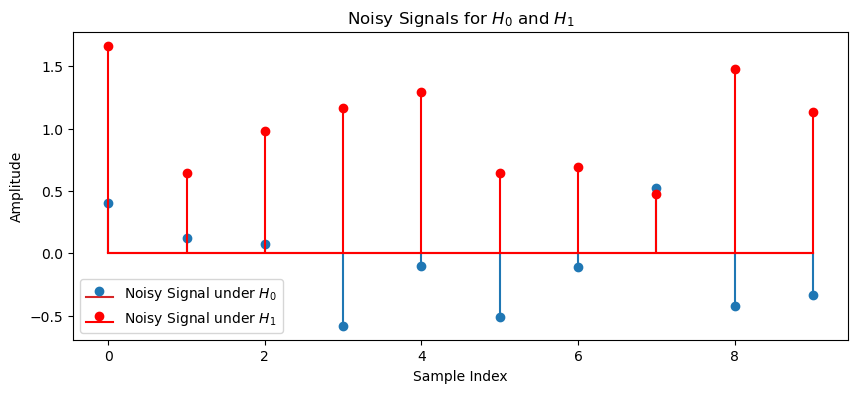

Log-Likelihood Ratio: 3.7594918625291436e-23
Decision: H0


In [35]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 10  # Number of samples per period
sigma_n_squared = 0.1  # Variance of the noise
threshold = 0  # Decision threshold

# Generate a sample received signal (noise-only, H0)
r_h0 = np.random.normal(0, np.sqrt(sigma_n_squared), N)

# Generate a sample received signal (with signal pulse, H1)
s_h1 = np.ones(N)  # Signal pulse of amplitude 1
r_h1 = s_h1 + np.random.normal(0, np.sqrt(sigma_n_squared), N)

# Calculate the likelihood ratios for both H0 and H1
log_likelihood_ratio_h0 = -0.5 * (np.sum(r_h0**2) - np.sum(r_h0**2)) / sigma_n_squared
log_likelihood_ratio_h1 = -0.5 * (np.sum(r_h1**2) - np.sum((r_h1 - s_h1)**2)) / sigma_n_squared

# Define the range for PDF plots
x = np.linspace(-3, 3, 1000)  # Adjust the range as needed

# Calculate PDFs for H0 and H1
pdf_h0 = 1 / (np.sqrt(2 * np.pi * sigma_n_squared)) * np.exp(-x**2 / (2 * sigma_n_squared))
pdf_h1 = 1 / (np.sqrt(2 * np.pi * sigma_n_squared)) * np.exp(-(x - 1)**2 / (2 * sigma_n_squared))

# Plot the PDFs
plt.figure(figsize=(10, 4))
plt.plot(x, pdf_h0, label='$P(R | H_0)$')
plt.plot(x, pdf_h1, label='$P(R | H_1)$')
plt.xlabel('Received Signal Value (r)')
plt.ylabel('Probability Density')
plt.title('PDFs of Likelihood Functions for H0 and H1')
plt.legend()

# Plot the noisy signals
plt.figure(figsize=(10, 4))
plt.stem(range(N), r_h0, label='Noisy Signal under $H_0$')
plt.stem(range(N), r_h1, linefmt='r-', markerfmt='ro', basefmt='r-', label='Noisy Signal under $H_1$')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Noisy Signals for $H_0$ and $H_1$')
plt.legend()

plt.show()

# Display the results
print("Log-Likelihood Ratio:", np.exp(log_likelihood_ratio_h1))
print("Decision:", decision)

Log-Likelihood Ratio (H0): 13.712216416315862
Log-Likelihood Ratio (H1): 77.61141217499262
Decision (H0): H1
Decision (H1): H1


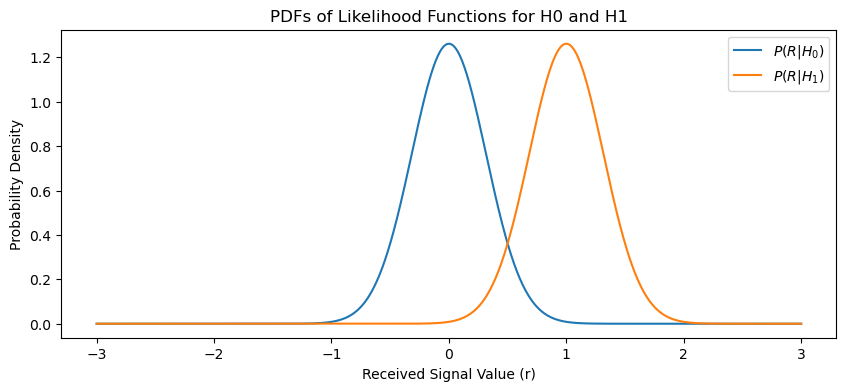

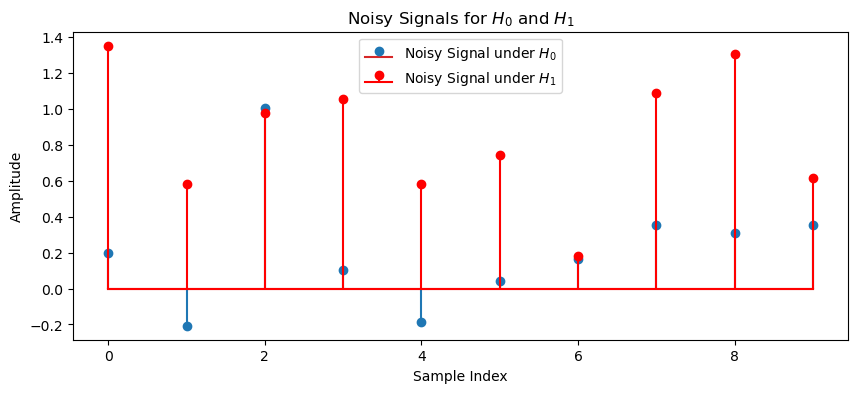

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 10  # Number of samples per period
sigma_n_squared = 0.1  # Variance of the noise

# A priori probabilities
P0 = 0.5
P1 = 1 - P0
threshold = np.log(P0/P1)  # Decision threshold

# Generate a sample received signal (noise-only, H0)
r_h0 = np.random.normal(0, np.sqrt(sigma_n_squared), N)

# Generate a sample received signal (with signal pulse, H1)
s_h1 = np.ones(N)  # Signal pulse of amplitude 1
r_h1 = s_h1 + np.random.normal(0, np.sqrt(sigma_n_squared), N)

# Calculate the likelihood ratios for both H0 and H1
log_likelihood_ratio_h0 = np.sum(2*r_h0 * s_h1) / (2 * sigma_n_squared) - np.sum(r_h0**2) / (2 * sigma_n_squared)
log_likelihood_ratio_h1 = np.sum(2*r_h1 * s_h1) / (2 * sigma_n_squared) - np.sum((r_h1 - s_h1)**2) / (2 * sigma_n_squared)

# Define the range for PDF plots
x = np.linspace(-3, 3, 1000)  # Adjust the range as needed

# Calculate PDFs for H0 and H1
pdf_h0 = 1 / (np.sqrt(2 * np.pi * sigma_n_squared)) * np.exp(-x**2 / (2 * sigma_n_squared))
pdf_h1 = 1 / (np.sqrt(2 * np.pi * sigma_n_squared)) * np.exp(-(x - 1)**2 / (2 * sigma_n_squared))

# Plot the PDFs
plt.figure(figsize=(10, 4))
plt.plot(x, pdf_h0, label='$P(R | H_0)$')
plt.plot(x, pdf_h1, label='$P(R | H_1)$')
plt.xlabel('Received Signal Value (r)')
plt.ylabel('Probability Density')
plt.title('PDFs of Likelihood Functions for H0 and H1')
plt.legend()

# Plot the noisy signals
plt.figure(figsize=(10, 4))
plt.stem(range(N), r_h0, label='Noisy Signal under $H_0$')
plt.stem(range(N), r_h1, linefmt='r-', markerfmt='ro', basefmt='r-', label='Noisy Signal under $H_1$')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.title('Noisy Signals for $H_0$ and $H_1$')
plt.legend()

# Display the log-likelihood ratios and make decisions
print("Log-Likelihood Ratio (H0):", log_likelihood_ratio_h0)
print("Log-Likelihood Ratio (H1):", log_likelihood_ratio_h1)

decision_h0 = "H0" if log_likelihood_ratio_h0 < threshold else "H1"
decision_h1 = "H0" if log_likelihood_ratio_h1 < threshold else "H1"

print("Decision (H0):", decision_h0)
print("Decision (H1):", decision_h1)

plt.show()


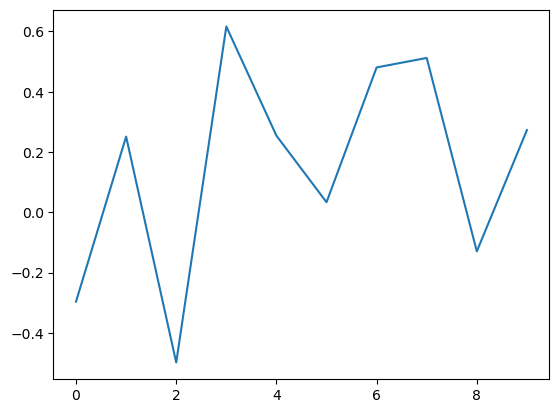

In [47]:
plt.plot(r_h1 - s_h1)

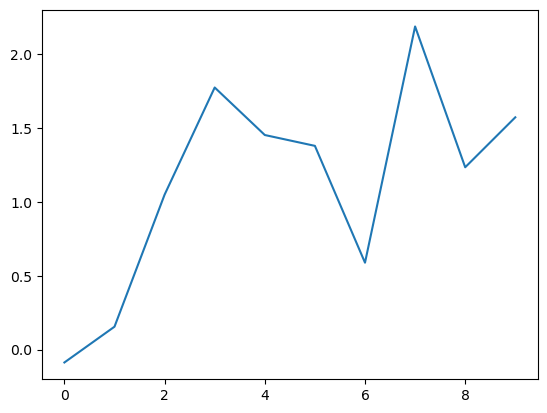

In [52]:
plt.plot(r_h1)

In [59]:
import pygame
import random
import math
import time

# Constants for the experiment
SCREEN_WIDTH = 800
SCREEN_HEIGHT = 600
TARGET_RADIUS = 30
NUM_TRIALS = 10

# Colors
WHITE = (255, 255, 255)
BLACK = (0, 0, 0)

# Initialize Pygame
pygame.init()

# Create the screen
screen = pygame.display.set_mode((SCREEN_WIDTH, SCREEN_HEIGHT))
pygame.display.set_caption("Fitts' Law Test")

# Function to calculate the distance between two points
def distance(x1, y1, x2, y2):
    return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

# Main loop
running = True
targets = []
trial = 0

while trial < NUM_TRIALS and running:
    trial += 1
    pygame.time.delay(1000)  # Pause for 1 second between trials
    screen.fill(WHITE)
    
    # Generate random target position
    target_x = random.randint(TARGET_RADIUS, SCREEN_WIDTH - TARGET_RADIUS)
    target_y = random.randint(TARGET_RADIUS, SCREEN_HEIGHT - TARGET_RADIUS)
    targets.append((target_x, target_y))
    
    # Draw the target
    pygame.draw.circle(screen, BLACK, (target_x, target_y), TARGET_RADIUS)
    pygame.display.flip()
    
    # Record the start time
    start_time = time.time()
    
    # Event handling
    while running:
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                running = False
            if event.type == pygame.MOUSEBUTTONDOWN:
                x, y = event.pos
                time_elapsed = time.time() - start_time
                dist_to_target = distance(x, y, target_x, target_y)
                print(f"Trial {trial}: Time Elapsed = {time_elapsed:.2f}s, Distance to Target = {dist_to_target:.2f}px")
                break

# Clean up and quit
pygame.quit()


pygame 2.5.1 (SDL 2.28.2, Python 3.10.9)
Hello from the pygame community. https://www.pygame.org/contribute.html
Trial 1: Time Elapsed = 2.52s, Distance to Target = 8.06px
Trial 1: Time Elapsed = 7.56s, Distance to Target = 19.21px
Trial 1: Time Elapsed = 8.27s, Distance to Target = 18.97px
Trial 1: Time Elapsed = 8.89s, Distance to Target = 18.97px
Trial 1: Time Elapsed = 9.25s, Distance to Target = 18.97px
Trial 1: Time Elapsed = 9.70s, Distance to Target = 348.66px
Trial 1: Time Elapsed = 12.40s, Distance to Target = 12.81px
Trial 1: Time Elapsed = 13.35s, Distance to Target = 222.20px
Trial 1: Time Elapsed = 13.51s, Distance to Target = 223.00px
Trial 1: Time Elapsed = 13.67s, Distance to Target = 223.60px
Trial 1: Time Elapsed = 13.83s, Distance to Target = 223.60px
Trial 1: Time Elapsed = 13.99s, Distance to Target = 223.60px
Trial 1: Time Elapsed = 15.44s, Distance to Target = 568.40px
Trial 1: Time Elapsed = 15.72s, Distance to Target = 674.38px
Trial 1: Time Elapsed = 16.01s, 

ValueError: x and y must have same first dimension, but have shapes (1024,) and (2047,)

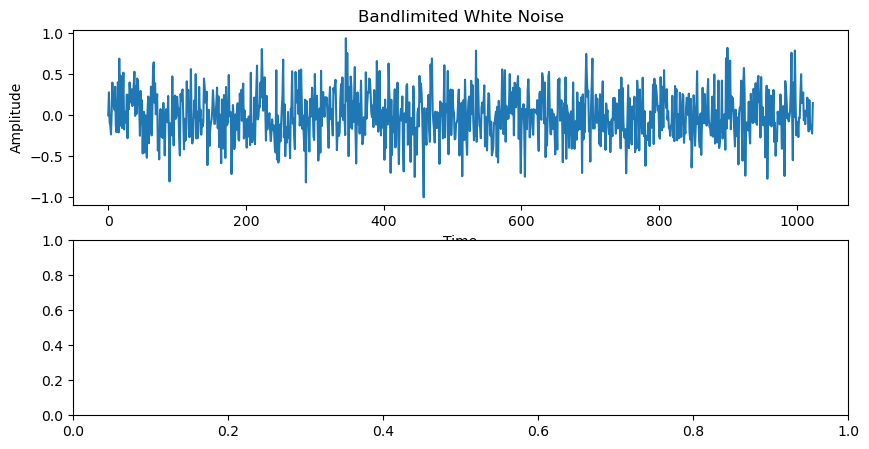

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 1024  # Number of samples
T = 1.0  # Sampling period
fs = 1.0 / T  # Sampling frequency
nyquist = 0.5 * fs  # Nyquist frequency

# Generate bandlimited white noise
# The noise is limited to a specific frequency range (bandwidth)
bandwidth = 5.0  # Adjust the bandwidth as needed
t = np.linspace(0.0, N * T, N, endpoint=False)
noise = np.random.normal(0, 1, N)
noise = np.convolve(noise, np.sinc(2 * bandwidth * (t - N * T / 2)), mode='same')
noise /= np.max(np.abs(noise))

# Calculate the autocorrelation function
autocorr = np.correlate(noise, noise, mode='full')
autocorr /= np.max(autocorr)

# Calculate the power spectral density (PSD)
frequencies = np.fft.fftfreq(N, T)
psd = np.abs(np.fft.fft(noise))**2 / N

# Plot the autocorrelation function
plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.plot(t, noise)
plt.title('Bandlimited White Noise')
plt.xlabel('Time')
plt.ylabel('Amplitude')

# Plot the autocorrelation function
plt.subplot(2, 1, 2)
plt.plot(t - N * T / 2, autocorr)
plt.title('Autocorrelation Function')
plt.xlabel('Time Lag')
plt.ylabel('Correlation')

plt.tight_layout()
plt.show()

# Plot the power spectral density (PSD)
plt.figure(figsize=(10, 5))
plt.semilogy(frequencies, psd)
plt.title('Power Spectral Density (PSD)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Frequency (dB/Hz)')
plt.xlim(0, nyquist)
plt.grid()
plt.show()


ValueError: x and y must have same first dimension, but have shapes (1024,) and (2047,)

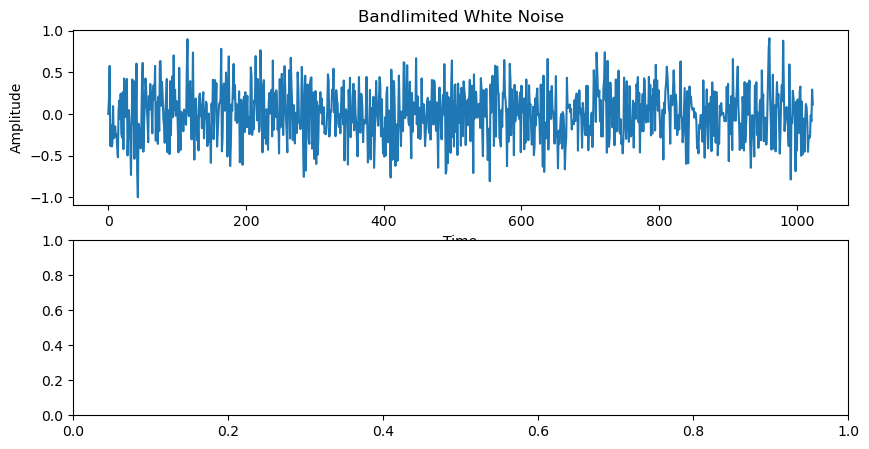

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 1024  # Number of samples
T = 1.0  # Sampling period
fs = 1.0 / T  # Sampling frequency
nyquist = 0.5 * fs  # Nyquist frequency

# Time values
t = np.linspace(0.0, N * T, N, endpoint=False)

# Create a pure sinc function in the time domain
bandwidth = 5.0  # Adjust the bandwidth as needed
sinc_signal = np.sinc(2 * bandwidth * (t - N * T / 2))

# Generate white noise
white_noise = np.random.normal(0, 1, N)

# Convolve the white noise with the sinc function
bandlimited_noise = np.convolve(white_noise, sinc_signal, mode='same')
bandlimited_noise /= np.max(np.abs(bandlimited_noise))

# Calculate the autocorrelation function
autocorr = np.correlate(bandlimited_noise, bandlimited_noise, mode='full')
autocorr /= np.max(autocorr)

# Calculate the power spectral density (PSD)
frequencies = np.fft.fftfreq(N, T)
window = np.zeros(N)
bandwidth_samples = int(bandwidth * N / nyquist)
window[:bandwidth_samples] = 1  # Rectangular window in the frequency domain
psd = np.abs(np.fft.fft(bandlimited_noise) * window)**2 / N

# Plot the bandlimited white noise
plt.figure(figsize=(10, 5))
plt.subplot(2, 1, 1)
plt.plot(t, bandlimited_noise)
plt.title('Bandlimited White Noise')
plt.xlabel('Time')
plt.ylabel('Amplitude')

# Plot the autocorrelation function
plt.subplot(2, 1, 2)
plt.plot(t - N * T / 2, autocorr)
plt.title('Autocorrelation Function')
plt.xlabel('Time Lag')
plt.ylabel('Correlation')

plt.tight_layout()
plt.show()

# Plot the power spectral density (PSD)
plt.figure(figsize=(10, 5))
plt.semilogy(frequencies, psd)
plt.title('Power Spectral Density (PSD)')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power/Frequency (dB/Hz)')
plt.xlim(0, nyquist)
plt.grid()
plt.show()


/var/folders/k4/hnf32ctn7n754hp_n6xf2zfr0000gn/T/ipykernel_86111/1816807971.py:38: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  plt.stem(0, mu**2, 'b', use_line_collection=True, basefmt=' ')


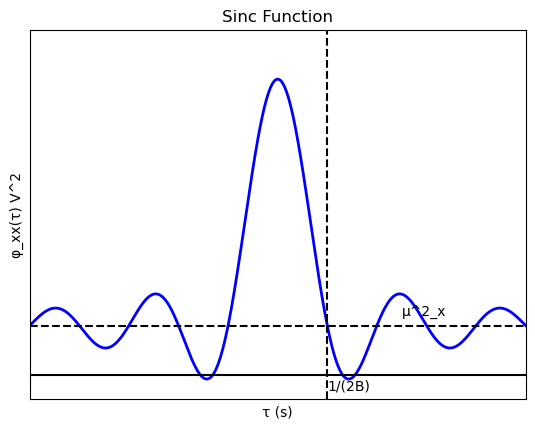

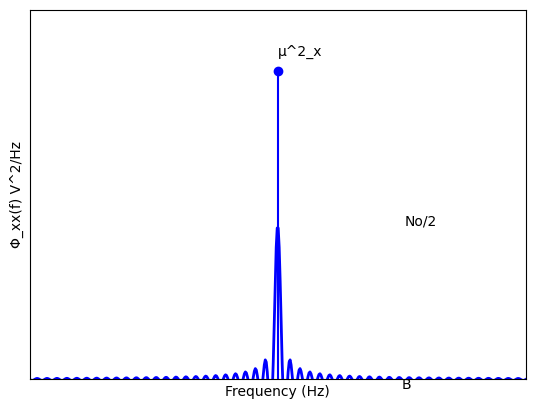

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# BLWN Parameters
N = 500
tau = np.linspace(-0.5, 0.5, N)
No = 1
B = 5
mu = 1

# Calculate phi
phi = B * No * np.sinc(2 * B * tau) + mu**2

# Plot phi
plt.figure()
plt.plot(tau, phi, 'b', linewidth=2)
plt.axhline(0, color='k')
plt.axvline(1 / (2 * B), color='k', linestyle='--')
plt.axhline(mu**2, color='k', linestyle='--')
plt.xlabel('Time (sec)')
plt.ylabel('Amplitude')
plt.title('Sinc Function')
plt.xlabel('\u03C4 (s)')
plt.ylabel('\u03C6_xx(\u03C4) V^2')
plt.text(1 / (2 * B), -0.3, '1/(2B)')
plt.text(0.25, mu**2 + 0.2, '\u03BC^2_x')
plt.gca().set_xticklabels([])
plt.gca().set_yticklabels([])
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.axis([-0.5, 0.5, -0.5, 7])

# Frequency Domain
f = np.linspace(-10, 10, N)
S = No / 2 * np.sinc(B * f)
plt.figure()
plt.plot(f, S, 'b', linewidth=2)
plt.stem(0, mu**2, 'b', use_line_collection=True, basefmt=' ')
plt.xlabel('Frequency (Hz)')
plt.ylabel('\u03A6_xx(f) V^2/Hz')
plt.axis([-10, 10, 0, 1.2])
plt.text(0, 1.05, '\u03BC^2_x')
plt.text(5, -0.03, 'B')
plt.text(B + 0.1, No / 2, 'No/2')
plt.gca().set_xticklabels([])
plt.gca().set_yticklabels([])
plt.gca().set_xticks([])
plt.gca().set_yticks([])

plt.show()


/var/folders/k4/hnf32ctn7n754hp_n6xf2zfr0000gn/T/ipykernel_86111/237497692.py:39: MatplotlibDeprecationWarning: The 'use_line_collection' parameter of stem() was deprecated in Matplotlib 3.6 and will be removed two minor releases later. If any parameter follows 'use_line_collection', they should be passed as keyword, not positionally.
  plt.stem(0, mu**2, 'b', use_line_collection=True, basefmt=' ')


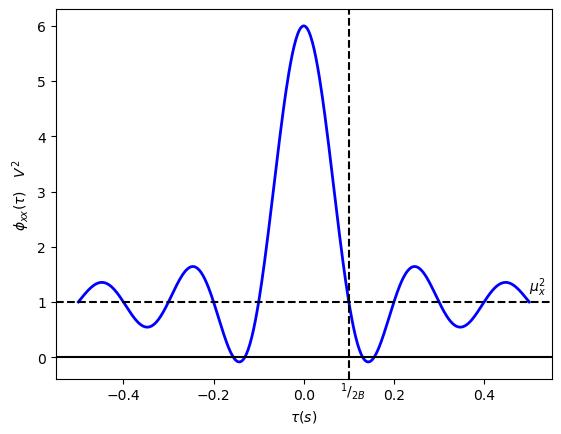

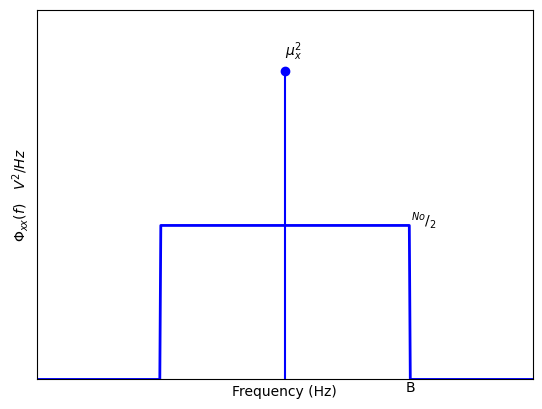

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# BLWN Parameters
N = 500
tau = np.linspace(-0.5, 0.5, N)
No = 1
B = 5
mu = 1

# Calculate phi
phi = B * No * np.sinc(2 * B * tau) + mu**2

# Plot phi
plt.figure()
plt.plot(tau, phi, 'b', linewidth=2)
plt.axhline(0, color='k')
plt.axvline(1 / (2 * B), color='k', linestyle='--')
plt.axhline(mu**2, color='k', linestyle='--')
plt.xlabel('Time (sec)')
#plt.title('Sinc Function')
plt.xlabel('$\u03C4 (s)$')
plt.ylabel('$\phi_{xx}(\u03C4) \quad V^2$')
plt.text(1 / (2 * B)-0.02, -0.7, '$^1/_{2B}$')
plt.text(0.5, mu**2 + 0.2, '$\mu^2_x$')
#plt.gca().set_xticklabels([])
#plt.gca().set_yticklabels([])
#plt.gca().set_xticks([])
#plt.gca().set_yticks([])
#plt.axis([-0.5, 0.5, -0.5, 7])

# Frequency Domain (Rectangular Function)
f = np.linspace(-10, 10, N)
S = np.zeros(N)
B_samples = int(B * N / 20)  # Adjust to create a rectangular function
S[N//2 - B_samples:N//2 + B_samples + 1] = No  # Rectangular function
plt.figure()
plt.plot(f, 0.5*S, 'b', linewidth=2)
plt.stem(0, mu**2, 'b', use_line_collection=True, basefmt=' ')
plt.xlabel('Frequency (Hz)')
plt.ylabel('$\u03A6_{xx}(f) \quad V^2/Hz$')
plt.axis([-10, 10, 0, 1.2])
plt.text(0, 1.05, '$\u03BC^2_x$')
plt.text(4.9, -0.04, 'B')
plt.text(B + 0.1, 0.5*No, '$^{No}/_2$')
plt.gca().set_xticklabels([])
plt.gca().set_yticklabels([])
plt.gca().set_xticks([])
plt.gca().set_yticks([])

plt.show()


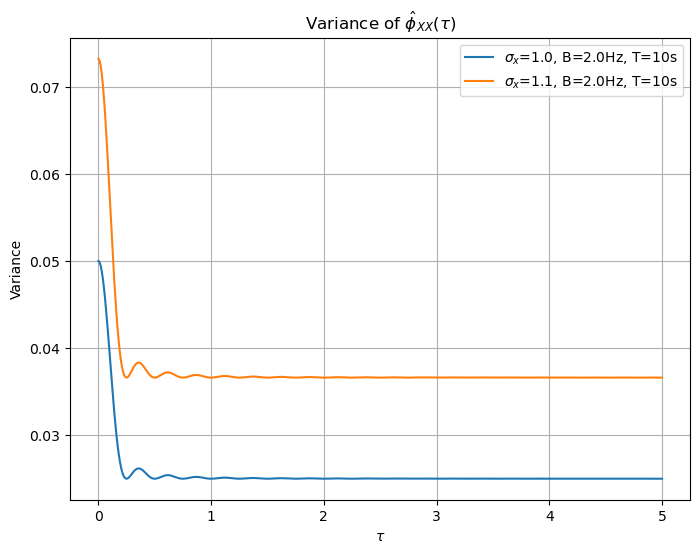

In [42]:
import numpy as np
import matplotlib.pyplot as plt

# Define parameters
sigma_X1 = 1.0  # Replace with the actual value
sigma_X2 = 1.1  # Replace with the actual value
B = 2.0  # Replace with the actual value
T = 10.0  # Replace with the actual value

# Generate values for tau
tau = np.linspace(0.001, 5.0, 500)  # Adjust the range and number of points as needed

# Calculate the function values
variance1 = (sigma_X1**4 / (2 * B * T)) * (1 + (np.sin(2 * np.pi * B * tau) / (2 * np.pi * B * tau))**2)
variance2 = (sigma_X2**4 / (2 * B * T)) * (1 + (np.sin(2 * np.pi * B * tau) / (2 * np.pi * B * tau))**2)

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(tau, variance1, label='$\sigma_x$=1.0, B=2.0Hz, T=10s')
plt.plot(tau, variance2, label='$\sigma_x$=1.1, B=2.0Hz, T=10s')
plt.xlabel('$\u03C4 $')
plt.ylabel('Variance')
plt.title('Variance of $\hat{\phi}_{XX}(\u03C4 )$')
plt.grid(True)
plt.legend()
plt.show()


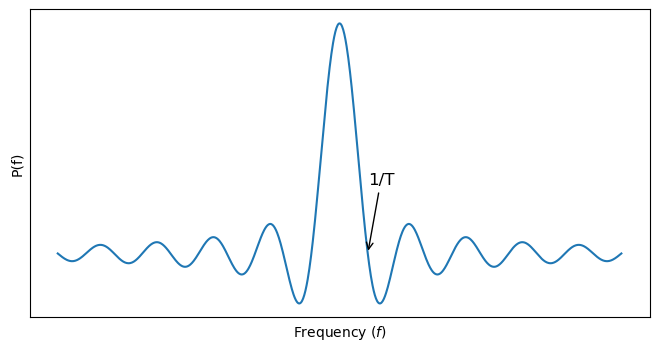

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# Define the sinc function and frequency axis
tau_m = 1.0  # Adjust as needed
frequency = np.linspace(-10 / (2 * tau_m), 10 / (2 * tau_m), 1000)  # Adjust the range as needed
sinc = np.sinc(2 * tau_m * frequency)

# Plot the sinc function
plt.figure(figsize=(8, 4))
plt.plot(frequency, sinc, label='sinc($2 \T f$)')
plt.gca().axes.get_xaxis().set_ticks([])
plt.gca().axes.get_yaxis().set_ticks([])


# Find the first zero crossing
first_zero_crossing = 1 / (2 * tau_m)

# Label the first zero crossing
plt.annotate('1/T', xy=(first_zero_crossing, 0), xytext=(first_zero_crossing, 0.3),
             arrowprops=dict(arrowstyle='->'), fontsize=12)

# Customize the plot
plt.xlabel('Frequency ($f$)')
plt.ylabel('P(f)')
plt.grid(True)

# Show the plot
plt.show()


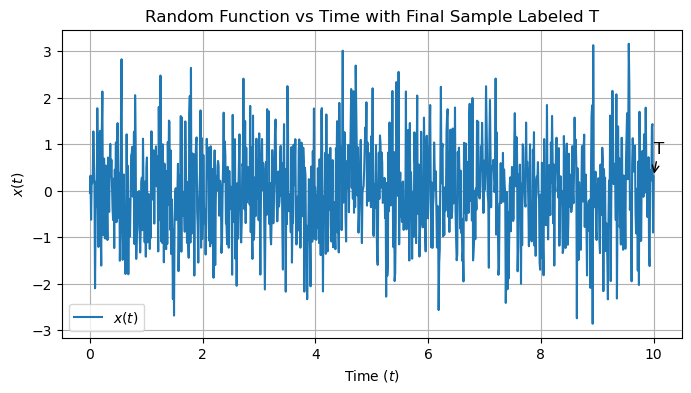

In [47]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random data for x(t)
# Replace this with your actual data or signal
t = np.linspace(0, T, num=1000)  # Adjust T and number of samples as needed
x = np.random.randn(len(t))  # Replace with your data

# Plot the random function
plt.figure(figsize=(8, 4))
plt.plot(t, x, label='$x(t)$')

# Label the final sample as T
plt.annotate('T', xy=(T, x[-1]), xytext=(T, x[-1] + 0.5),
             arrowprops=dict(arrowstyle='->'), fontsize=12)

# Customize the plot
plt.xlabel('Time ($t$)')
plt.ylabel('$x(t)$')
plt.title('Random Function vs Time with Final Sample Labeled T')
plt.grid(True)
plt.legend()

# Show the plot
plt.show()


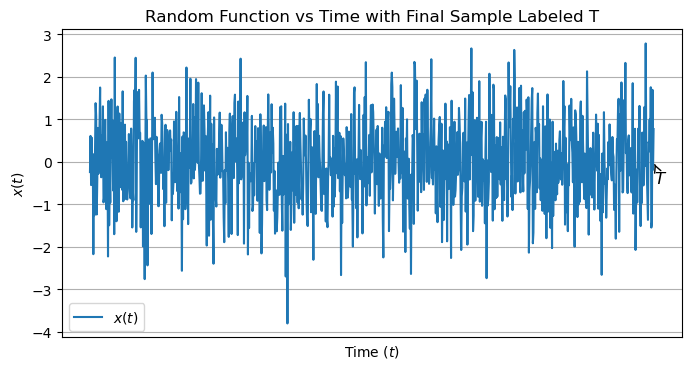

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random data for x(t)
# Replace this with your actual data or signal
t = np.linspace(0, T, num=1000)  # Adjust T and number of samples as needed
x = np.random.randn(len(t))  # Replace with your data

# Plot the random function
plt.figure(figsize=(8, 4))
plt.plot(t, x, label='$x(t)$')

# Remove x-axis labels
plt.gca().axes.get_xaxis().set_ticks([])

# Label the final sample as T on the x-axis
plt.annotate('$T$', xy=(T, 0), xytext=(T, -0.5), fontsize=12,
             arrowprops=dict(arrowstyle='->'))

# Customize the plot
plt.xlabel('Time ($t$)')
plt.ylabel('$x(t)$')
plt.title('Random Function vs Time with Final Sample Labeled T')
plt.grid(True)

# Show the plot
plt.show()


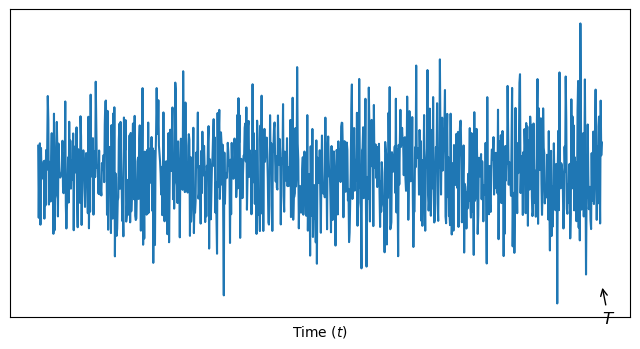

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random data for x(t)
# Replace this with your actual data or signal
t = np.linspace(0, T, num=1000)  # Adjust T and number of samples as needed
x = np.random.randn(len(t))  # Replace with your data

# Plot the random function
plt.figure(figsize=(8, 4))
plt.plot(t, x, label='$x(t)$')

# Remove y-axis labels
plt.gca().axes.get_yaxis().set_ticks([])
plt.gca().axes.get_xaxis().set_ticks([])

# Label the final sample as T on the x-axis
plt.annotate('$T$', xy=(T, -3), xytext=(T, -4), fontsize=12,
             arrowprops=dict(arrowstyle='->'))

# Customize the plot
plt.xlabel('Time ($t$)')
plt.ylabel('')  # An empty label to remove the y-axis label

plt.grid(True)

# Show the plot
plt.show()


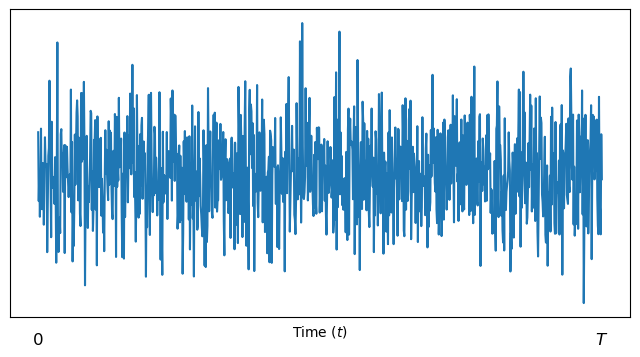

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random data for x(t)
# Replace this with your actual data or signal
T = 5  # Adjust T as needed
t = np.linspace(0, T, num=1000)  # Adjust the number of samples as needed
x = np.random.randn(len(t))  # Replace with your data

# Plot the random function
plt.figure(figsize=(8, 4))
plt.plot(t, x, label='$x(t)$')

# Remove y-axis labels
plt.gca().axes.get_yaxis().set_ticks([])
plt.gca().axes.get_xaxis().set_ticks([])

# Label the final sample as T on the x-axis without an arrow
plt.text(T, -3.85, '$T$', fontsize=12, ha='center')
plt.text(0, -3.85, '$0$', fontsize=12, ha='center')

# Customize the plot
plt.xlabel('Time ($t$)')
plt.ylabel('')  # An empty label to remove the y-axis label

# Show the plot
plt.show()


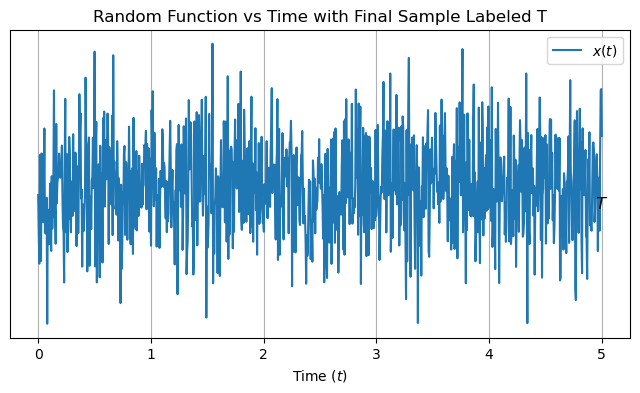

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# Generate random data for x(t)
# Replace this with your actual data or signal
T = 5  # Adjust T as needed
t = np.linspace(0, T, num=1000)  # Adjust the number of samples as needed
x = np.random.randn(len(t))  # Replace with your data

# Plot the random function without a bounding box
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, x, label='$x(t)$')

# Remove y-axis labels
ax.yaxis.set_major_locator(plt.NullLocator())

# Label the final sample as T on the x-axis without an arrow
ax.text(T, -0.5, '$T$', fontsize=12, ha='center')

# Customize the plot
ax.set_xlabel('Time ($t$)')
ax.set_title('Random Function vs Time with Final Sample Labeled T')
ax.grid(True)
ax.legend()

# Show the plot
plt.show()


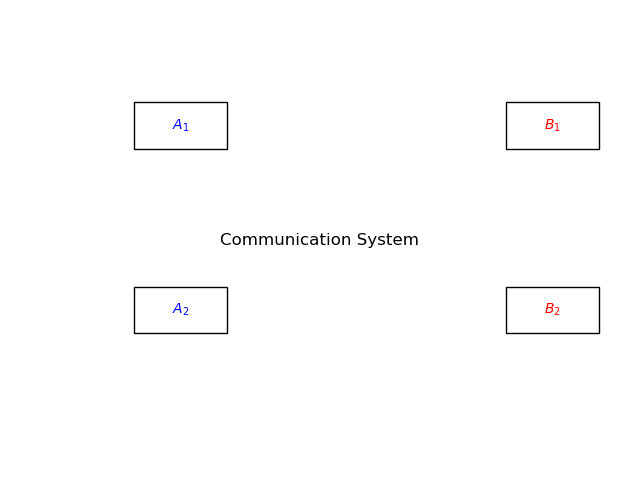

In [84]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create a new figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Define block positions and sizes
input_x = [0.2, 0.2]
output_x = [0.8, 0.8]
y_positions = [0.7, 0.3]
block_width = 0.15
block_height = 0.1

# Draw blocks for inputs A1 and A2
for i in range(2):
    ax.add_patch(patches.Rectangle((input_x[i], y_positions[i]), block_width, block_height, fill=False))
    ax.annotate(f'$A_{i+1}$', (input_x[i] + block_width / 2, y_positions[i] + block_height / 2),
                color='b', ha='center', va='center')

# Draw blocks for outputs B1 and B2
for i in range(2):
    ax.add_patch(patches.Rectangle((output_x[i], y_positions[i]), block_width, block_height, fill=False))
    ax.annotate(f'$B_{i+1}$', (output_x[i] + block_width / 2, y_positions[i] + block_height / 2),
                color='r', ha='center', va='center')

# Draw the system label
ax.annotate('Communication System', (0.5, 0.5), fontsize=12, ha='center', va='center')

# Set axis limits and remove axis labels
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Show the block diagram
plt.show()


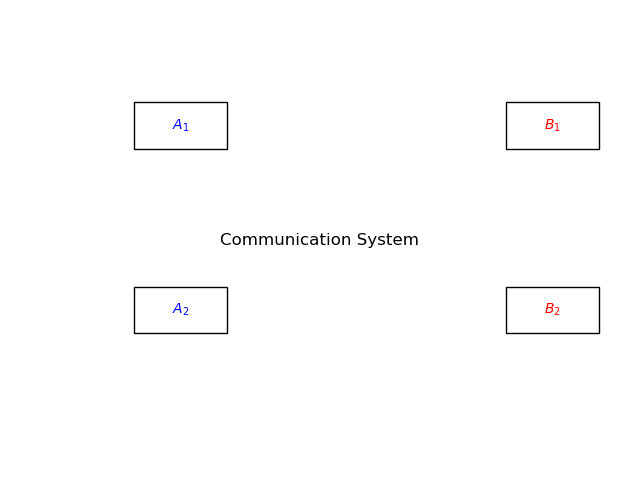

In [85]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create a new figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Define block positions and sizes
input_x = [0.2, 0.2]
output_x = [0.8, 0.8]
y_positions = [0.7, 0.3]
block_width = 0.15
block_height = 0.1

# Draw blocks for inputs A1 and A2
for i in range(2):
    ax.add_patch(patches.Rectangle((input_x[i], y_positions[i]), block_width, block_height, fill=False))
    ax.annotate(f'$A_{i+1}$', (input_x[i] + block_width / 2, y_positions[i] + block_height / 2),
                color='b', ha='center', va='center')

# Draw blocks for outputs B1 and B2
for i in range(2):
    ax.add_patch(patches.Rectangle((output_x[i], y_positions[i]), block_width, block_height, fill=False))
    ax.annotate(f'$B_{i+1}$', (output_x[i] + block_width / 2, y_positions[i] + block_height / 2),
                color='r', ha='center', va='center')

# Draw the system label
ax.annotate('Communication System', (0.5, 0.5), fontsize=12, ha='center', va='center')

# Set axis limits and remove axis labels
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Show the block diagram
plt.show()


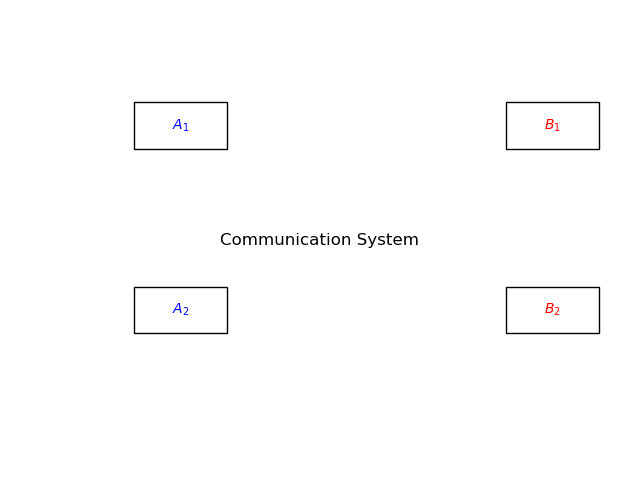

In [86]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Create a new figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Define block positions and sizes
input_x = [0.2, 0.2]
output_x = [0.8, 0.8]
y_positions = [0.7, 0.3]
block_width = 0.15
block_height = 0.1

# Draw blocks for inputs A1 and A2
for i in range(2):
    ax.add_patch(patches.Rectangle((input_x[i], y_positions[i]), block_width, block_height, fill=False))
    ax.annotate(f'$A_{i+1}$', (input_x[i] + block_width / 2, y_positions[i] + block_height / 2),
                color='b', ha='center', va='center')

# Draw blocks for outputs B1 and B2
for i in range(2):
    ax.add_patch(patches.Rectangle((output_x[i], y_positions[i]), block_width, block_height, fill=False))
    ax.annotate(f'$B_{i+1}$', (output_x[i] + block_width / 2, y_positions[i] + block_height / 2),
                color='r', ha='center', va='center')

# Draw the system label
ax.annotate('Communication System', (0.5, 0.5), fontsize=12, ha='center', va='center')

# Set axis limits and remove axis labels
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# Show the block diagram
plt.show()


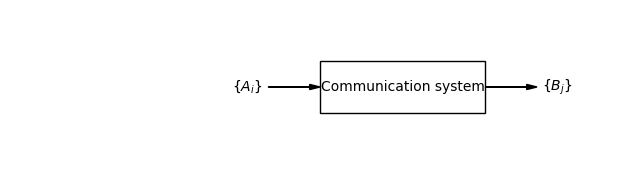

In [131]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Function to draw a block with text
def draw_block(ax, text, xy, transparent=False):
    if transparent:
        block = patches.Rectangle(xy, 1.6, 1, fill=None, edgecolor='none')
    else:
        block = patches.Rectangle(xy, 1.6, 1, fill=None, edgecolor='black')
    ax.add_patch(block)
    ax.text(xy[0] + 0.8, xy[1] + 0.5, text, ha='center', va='center')

# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 2))

# Draw input block x(t)
draw_block(ax, '$\{A_i\}$', (0.5, 0), transparent=True)

# Draw LTI system block
draw_block(ax, 'Communication system', (2.0, 0))

# Draw output block y(t)
draw_block(ax, '$\{B_j\}$', (3.5, 0), transparent=True)

# Connect input to LTI system
ax.arrow(1.5, 0.5, 0.4, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

# Connect LTI system to output
ax.arrow(3.6, 0.5, 0.4, 0, head_width=0.1, head_length=0.1, fc='black', ec='black', lw=1)

# Set axis properties
ax.set_xlim(-1, 5)
ax.set_ylim(-1, 2)
ax.axis('off')

# Show the plot
plt.show()


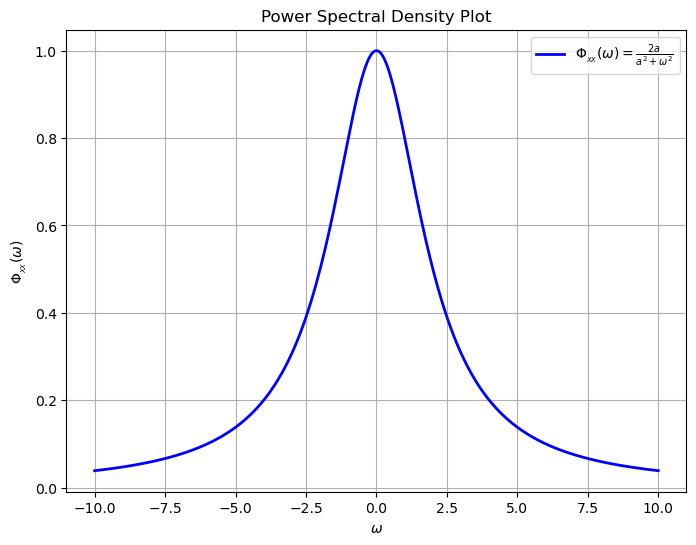

In [133]:
import numpy as np
import matplotlib.pyplot as plt

# Define the function Phi_XX
def Phi_XX(a, omega):
    return 2 * a / (a**2 + omega**2)

# Define the range of frequencies (omega values)
omega = np.linspace(-10, 10, 400)

# Choose a value for 'a'
a = 2

# Calculate Phi_XX values for the given omega
phi_values = Phi_XX(a, omega)

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(omega, phi_values, label=r'$\Phi_{_{XX}}(\omega) = \frac{2a}{a^2 + \omega^2}$', color='b', linewidth=2)
plt.xlabel(r'$\omega$')
plt.ylabel(r'$\Phi_{_{XX}}(\omega)$')
plt.title('Power Spectral Density Plot')
plt.grid()
plt.legend()
plt.show()


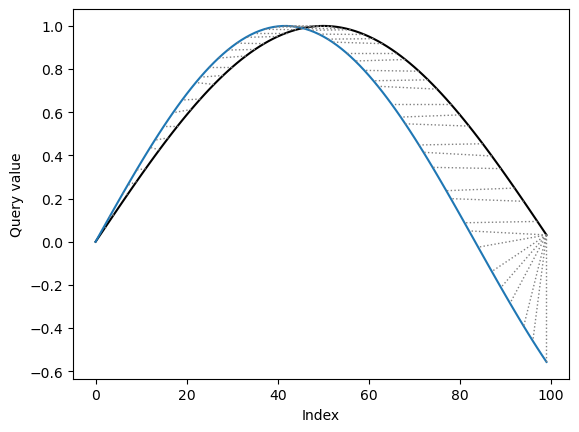

Time Series 1: [0.         0.03141076 0.06279052 0.09410831 0.12533323 0.15643447
 0.18738131 0.21814324 0.24868989 0.27899111 0.30901699 0.33873792
 0.36812455 0.39714789 0.42577929 0.4539905  0.48175367 0.50904142
 0.53582679 0.56208338 0.58778525 0.61290705 0.63742399 0.66131187
 0.68454711 0.70710678 0.72896863 0.75011107 0.77051324 0.79015501
 0.80901699 0.82708057 0.84432793 0.86074203 0.87630668 0.89100652
 0.90482705 0.91775463 0.92977649 0.94088077 0.95105652 0.96029369
 0.96858316 0.97591676 0.98228725 0.98768834 0.9921147  0.99556196
 0.99802673 0.99950656 1.         0.99950656 0.99802673 0.99556196
 0.9921147  0.98768834 0.98228725 0.97591676 0.96858316 0.96029369
 0.95105652 0.94088077 0.92977649 0.91775463 0.90482705 0.89100652
 0.87630668 0.86074203 0.84432793 0.82708057 0.80901699 0.79015501
 0.77051324 0.75011107 0.72896863 0.70710678 0.68454711 0.66131187
 0.63742399 0.61290705 0.58778525 0.56208338 0.53582679 0.50904142
 0.48175367 0.4539905  0.42577929 0.39714789 0.

In [20]:
import numpy as np
from dtw import *
import matplotlib.pyplot as plt

# Example usage
if __name__ == "__main__":
    # Generate two example time series
    N = 100      # Number of samples
    # Generate input signal x(n) - Assume a white Gaussian noise
    x = np.random.randn(N)
    # Generate desired signal y(n) - A sinusoidal signal corrupted by noise
    series1 = np.sin(2 * np.pi * 0.005 * np.arange(N))
    noise = 0.2 * np.random.randn(N)
    #series2 = series1 + noise
    series2 = np.sin(2 * np.pi * 0.006 * np.arange(N) )

    # Create DTW object
    alignment = dtw(series1, series2, keep_internals=True)

    # Calculate DTW distance
    alignment.plot(type="twoway")
    plt.show()

    dtw_distance = alignment.distance
    print("Time Series 1:", series1)
    print("Time Series 2:", series2)
    print("DTW Distance:", dtw_distance)

In [2]:
pip install dtw-python


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.3/246.3 kB 3.3 MB/s eta 0:00:00a 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for dtw-python: filename=dtw_python-1.3.0-cp310-cp310-macosx_11_0_arm64.whl size=349932 sha256=c0067644ec73b0a8984d001fa2c92171aea0e92964e791f1e046c4aa4e9dfa4a
  Stored in directory: /Users/kengleha/Library/Caches/pip/wheels/16/eb/7c/7b6d021e9975f3b5095a9e2273ad6b742697fb379caf381db7
Successfully built dtw-python
Note: you may need to restart the kernel to use updated packages.


SyntaxError: invalid syntax (1698891067.py, line 1)

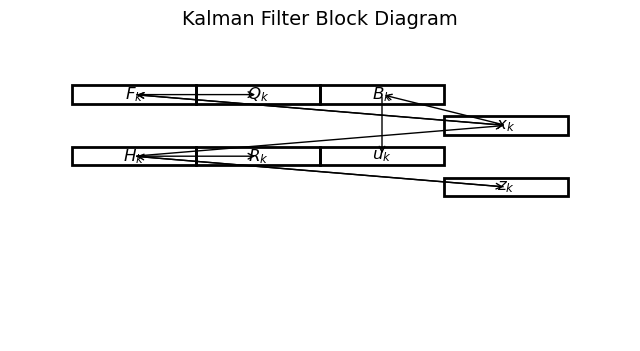

In [4]:
import matplotlib.pyplot as plt

# Define the Kalman filter components
components = {
    "$F_k$": (0.2, 0.8),
    "$H_k$": (0.2, 0.6),
    "$Q_k$": (0.4, 0.8),
    "$R_k$": (0.4, 0.6),
    "$B_k$": (0.6, 0.8),
    "$u_k$": (0.6, 0.6),
    "$x_k$": (0.8, 0.7),
    "$z_k$": (0.8, 0.5),
}

# Create a plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis("off")

# Draw boxes and labels
for label, (x, y) in components.items():
    ax.add_patch(plt.Rectangle((x - 0.1, y - 0.03), 0.2, 0.06, fill=None, linewidth=2))
    ax.text(x, y, label, ha="center", va="center", fontsize=12)

# Connect components with arrows
ax.annotate(
    "",
    xy=components["$F_k$"],
    xytext=components["$x_k$"],
    arrowprops=dict(arrowstyle="->"),
)
ax.annotate(
    "",
    xy=components["$B_k$"],
    xytext=components["$x_k$"],
    arrowprops=dict(arrowstyle="->"),
)
ax.annotate(
    "",
    xy=components["$u_k$"],
    xytext=components["$B_k$"],
    arrowprops=dict(arrowstyle="->"),
)
ax.annotate(
    "",
    xy=components["$z_k$"],
    xytext=components["$H_k$"],
    arrowprops=dict(arrowstyle="->"),
)
ax.annotate(
    "",
    xy=components["$x_k$"],
    xytext=components["$H_k$"],
    arrowprops=dict(arrowstyle="->"),
)
ax.annotate(
    "",
    xy=components["$H_k$"],
    xytext=components["$z_k$"],
    arrowprops=dict(arrowstyle="->"),
)
ax.annotate(
    "",
    xy=components["$F_k$"],
    xytext=components["$x_k$"],
    arrowprops=dict(arrowstyle="->"),
)
ax.annotate(
    "",
    xy=components["$Q_k$"],
    xytext=components["$F_k$"],
    arrowprops=dict(arrowstyle="->"),
)
ax.annotate(
    "",
    xy=components["$R_k$"],
    xytext=components["$H_k$"],
    arrowprops=dict(arrowstyle="->"),
)

plt.title("Kalman Filter Block Diagram", fontsize=14)
plt.show()


In [5]:
pip install graphviz


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.0/47.0 kB 1.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [6]:
import graphviz

# Create a Digraph object
dot = graphviz.Digraph(comment='Kalman Filter Flowchart')

# Define nodes and edges
dot.node('Start', 'Start', shape='ellipse')
dot.node('Predict', 'Predict', shape='box')
dot.node('Update', 'Update', shape='box')
dot.node('End', 'End', shape='ellipse')

dot.edge('Start', 'Predict', label='Initialize\nPredicted State Estimate\nPredicted Estimate Covariance')
dot.edge('Predict', 'Update', label='Predicted Measurement\nInnovation\nInnovation Covariance\nOptimal Kalman Gain')
dot.edge('Update', 'Predict', label='Updated State Estimate\nUpdated Estimate Covariance\nMeasurement Post-fit Residual')
dot.edge('Update', 'End', label='A posteriori\nState Estimate')

# Render the flowchart to a PDF file
dot.render('kalman_filter_flowchart', view=True)


ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

In [3]:
import graphviz

# Create a Digraph object
dot = graphviz.Digraph(comment='Kalman Filter Flowchart')

# Define nodes and edges
dot.node('Start', 'Start', shape='ellipse')
dot.node('Predict', 'Predict', shape='box')
dot.node('Update', 'Update', shape='box')
dot.node('End', 'End', shape='ellipse')

dot.edge('Start', 'Predict', label='Initialize\nPredicted State Estimate\nPredicted Estimate Covariance')
dot.edge('Predict', 'Update', label='Predicted Measurement\nInnovation\nInnovation Covariance\nOptimal Kalman Gain')
dot.edge('Update', 'Predict', label='Updated State Estimate\nUpdated Estimate Covariance\nMeasurement Post-fit Residual')
dot.edge('Update', 'End', label='A posteriori\nState Estimate')

# Render the flowchart to a PDF file
dot.render('kalman_filter_flowchart', view=True)


'kalman_filter_flowchart.pdf'

In [4]:
conda install python-graphviz

Solving environment: done


==> WARNING: A newer version of conda exists. <==
  current version: 23.3.1
  latest version: 23.9.0

Please update conda by running

    $ conda update -n base -c defaults conda

Or to minimize the number of packages updated during conda update use

     conda install conda=23.9.0



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [5]:
import graphviz

# Create a Digraph object
dot = graphviz.Digraph(comment='Kalman Filter Flowchart')

# Define nodes and edges
dot.node('Start', 'Start', shape='ellipse')
dot.node('Predict', 'Predict', shape='box')
dot.node('Update', 'Update', shape='box')
dot.node('End', 'End', shape='ellipse')

dot.edge('Start', 'Predict', label='Initialize\nPredicted State Estimate\nPredicted Estimate Covariance')
dot.edge('Predict', 'Update', label='Predicted Measurement\nInnovation\nInnovation Covariance\nOptimal Kalman Gain')
dot.edge('Update', 'Predict', label='Updated State Estimate\nUpdated Estimate Covariance\nMeasurement Post-fit Residual')
dot.edge('Update', 'End', label='A posteriori\nState Estimate')

# Render the flowchart to a PDF file
dot.render('kalman_filter_flowchart', view=True)


'kalman_filter_flowchart.pdf'

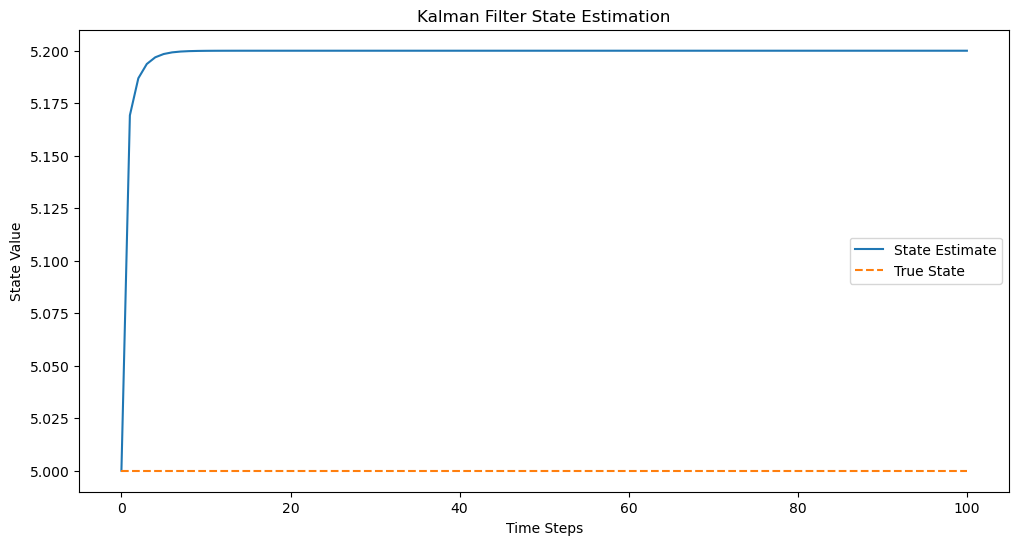

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Define the true state and measurement
true_state = 5.0
measurement = 5.2

# Initialize variables
initial_state = 5.0
state_estimate = initial_state  # Initial a priori state estimate
state_covariance = 1.0  # Initial covariance of state estimate
process_noise = 0.1  # Process noise (Q)
measurement_noise = 0.2  # Measurement noise (R)

# Lists to store values for plotting
state_estimates = [state_estimate]
state_covariances = [state_covariance]

# Kalman filter update
for _ in range(100):
    # Predict phase (using the state transition model, F, and control input, B, if available)
    # In this simplified example, we assume no control input and F = 1
    state_estimate_priori = state_estimate
    state_covariance_priori = state_covariance + process_noise

    # Update phase
    kalman_gain = state_covariance_priori / (state_covariance_priori + measurement_noise)
    state_estimate = state_estimate_priori + kalman_gain * (measurement - state_estimate_priori)
    state_covariance = (1 - kalman_gain) * state_covariance_priori

    # Store values for plotting
    state_estimates.append(state_estimate)
    state_covariances.append(state_covariance)

# Plot the results
plt.figure(figsize=(12, 6))
plt.plot(state_estimates, label='State Estimate')
plt.plot([true_state] * 101, label='True State', linestyle='--')
plt.xlabel('Time Steps')
plt.ylabel('State Value')
plt.legend()
plt.title('Kalman Filter State Estimation')
plt.show()



In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define initial conditions
prior_mean = 5.0  # Mean of a priori state estimate
prior_stddev = 1.0  # Standard deviation of a priori state estimate
measurement = 5.2  # Measurement value
measurement_stddev = 0.2  # Standard deviation of the measurement

# Generate a range of state values
state_values = np.linspace(0, 10, 1000)

# Calculate probability densities
prior_pdf = norm.pdf(state_values, loc=prior_mean, scale=prior_stddev)
measurement_pdf = norm.pdf(state_values, loc=measurement, scale=measurement_stddev)

# Kalman update
kalman_gain = prior_stddev**2 / (prior_stddev**2 + measurement_stddev**2)
posterior_mean = prior_mean + kalman_gain * (measurement - prior_mean)
posterior_stddev = np.sqrt((1 - kalman_gain) * prior_stddev**2)

posterior_pdf = norm.pdf(state_values, loc=posterior_mean, scale=posterior_stddev)

# Plot the probability densities
plt.figure(figsize=(10, 6))
plt.plot(state_values, prior_pdf, label='A Priori (Prior) Density', color='blue')
plt.plot(state_values, measurement_pdf, label='Measurement Density', color='green')
plt.plot(state_values, posterior_pdf, label='A Posteriori (Updated) Density', color='red')
plt.xlabel('State Values')
plt.ylabel('Probability Density')
plt.legend()
plt.title('Kalman Filter Update: Probability Density Estimation')
plt.grid(True)
plt.show()


ImportError: dlopen(/Users/kengleha/anaconda3/lib/python3.10/site-packages/scipy/sparse/linalg/_isolve/_iterative.cpython-310-darwin.so, 0x0002): Library not loaded: @rpath/liblapack.3.dylib
  Referenced from: <846DFF65-4FFB-38DE-96F0-B03D32D3ADE3> /Users/kengleha/anaconda3/lib/python3.10/site-packages/scipy/sparse/linalg/_isolve/_iterative.cpython-310-darwin.so
  Reason: tried: '/Users/kengleha/anaconda3/lib/python3.10/site-packages/scipy/sparse/linalg/_isolve/liblapack.3.dylib' (no such file), '/Users/kengleha/anaconda3/lib/python3.10/site-packages/scipy/sparse/linalg/_isolve/../../../../../../liblapack.3.dylib' (no such file), '/Users/kengleha/anaconda3/lib/python3.10/site-packages/scipy/sparse/linalg/_isolve/liblapack.3.dylib' (no such file), '/Users/kengleha/anaconda3/lib/python3.10/site-packages/scipy/sparse/linalg/_isolve/../../../../../../liblapack.3.dylib' (no such file), '/Users/kengleha/anaconda3/bin/../lib/liblapack.3.dylib' (no such file), '/Users/kengleha/anaconda3/bin/..

In [8]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [10]:
pip install liblapack

Note: you may need to restart the kernel to use updated packages.


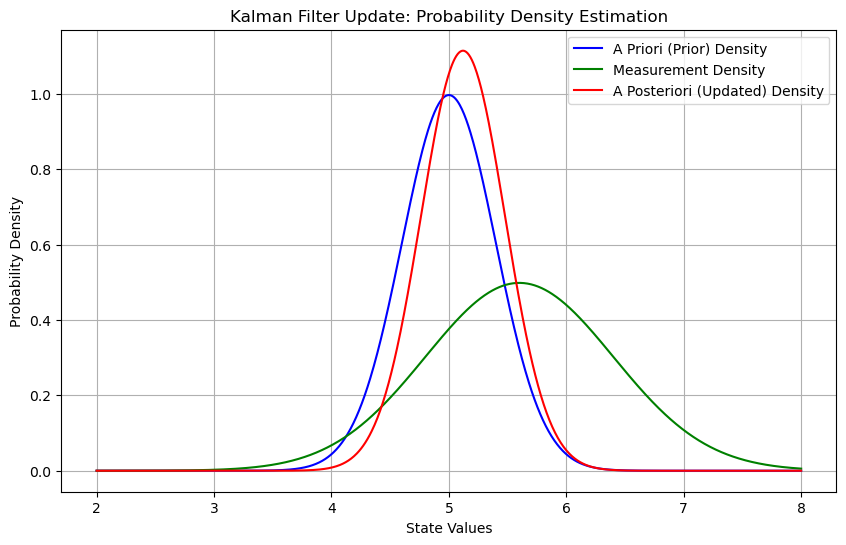

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Define initial conditions
prior_mean = 5.0  # Mean of a priori state estimate
prior_stddev = 0.4  # Standard deviation of a priori state estimate
measurement = 5.6  # Measurement value
measurement_stddev = 0.8  # Standard deviation of the measurement

# Generate a range of state values
state_values = np.linspace(2, 8, 1000)

# Calculate probability densities using numpy
prior_pdf = (1 / (prior_stddev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((state_values - prior_mean) / prior_stddev) ** 2)
measurement_pdf = (1 / (measurement_stddev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((state_values - measurement) / measurement_stddev) ** 2)

# Kalman update
kalman_gain = prior_stddev**2 / (prior_stddev**2 + measurement_stddev**2)
posterior_mean = prior_mean + kalman_gain * (measurement - prior_mean)
posterior_stddev = np.sqrt((1 - kalman_gain) * prior_stddev**2)

posterior_pdf = (1 / (posterior_stddev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((state_values - posterior_mean) / posterior_stddev) ** 2)

# Plot the probability densities
plt.figure(figsize=(10, 6))
plt.plot(state_values, prior_pdf, label='A Priori (Prior) Density', color='blue')
plt.plot(state_values, measurement_pdf, label='Measurement Density', color='green')
plt.plot(state_values, posterior_pdf, label='A Posteriori (Updated) Density', color='red')
plt.xlabel('State Values')
plt.ylabel('Probability Density')
plt.legend()
plt.title('Kalman Filter Update: Probability Density Estimation')
plt.grid(True)
plt.show()


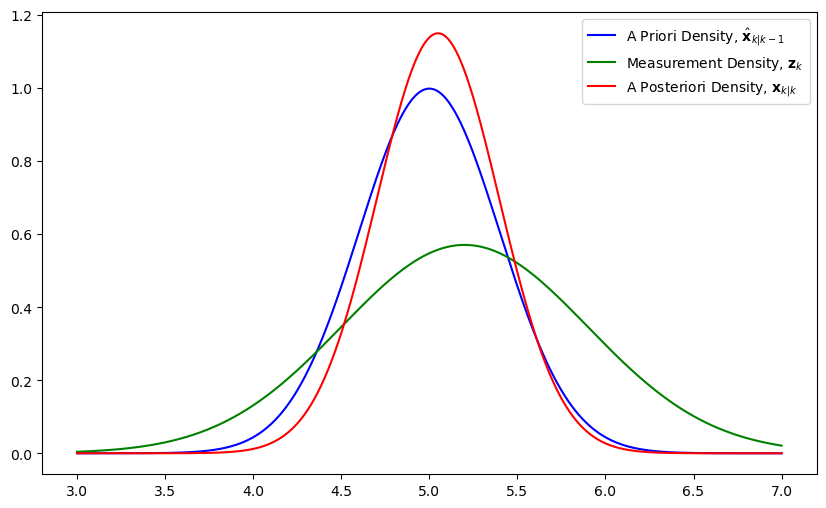

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Define initial conditions
prior_mean = 5.0  # Mean of a priori state estimate
prior_stddev = 0.40  # Standard deviation of a priori state estimate
measurement = 5.2  # Measurement value
measurement_stddev = 0.7  # Standard deviation of the measurement

# Generate a range of state values
state_values = np.linspace(3, 7, 1000)

# Calculate probability densities using numpy
prior_pdf = (1 / (prior_stddev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((state_values - prior_mean) / prior_stddev) ** 2)
measurement_pdf = (1 / (measurement_stddev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((state_values - measurement) / measurement_stddev) ** 2)

# Kalman update
kalman_gain = prior_stddev**2 / (prior_stddev**2 + measurement_stddev**2)
posterior_mean = prior_mean + kalman_gain * (measurement - prior_mean)
posterior_stddev = np.sqrt((1 - kalman_gain) * prior_stddev**2)

posterior_pdf = (1 / (posterior_stddev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((state_values - posterior_mean) / posterior_stddev) ** 2)

# Find the peaks of the densities
prior_peak = state_values[np.argmax(prior_pdf)]
measurement_peak = state_values[np.argmax(measurement_pdf)]
posterior_peak = state_values[np.argmax(posterior_pdf)]

# Plot the probability densities
plt.figure(figsize=(10, 6))
plt.plot(state_values, prior_pdf, label='A Priori Density, $\hat{\mathbf{x}}_{k|k-1}$', color='blue')
plt.plot(state_values, measurement_pdf, label='Measurement Density, $\mathbf{z}_k$', color='green')
plt.plot(state_values, posterior_pdf, label='A Posteriori Density, $\mathbf{x}_{k|k}$', color='red')
plt.legend()


plt.show()


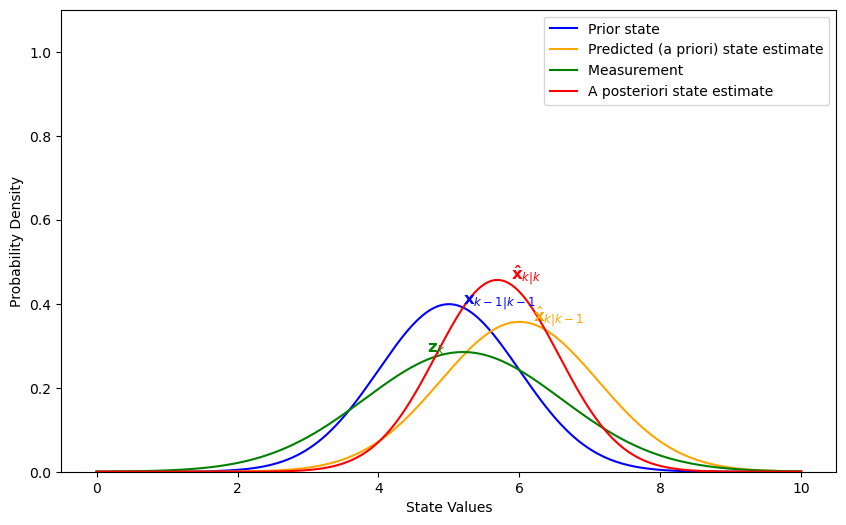

0.3894080996884736


In [52]:
import numpy as np
import matplotlib.pyplot as plt

# Define initial conditions
prior_mean = 5.0  # Mean of a priori state estimate
prior_stddev = 1.0  # Standard deviation of a priori state estimate
measurement = 5.2  # Measurement value
measurement_stddev = 1.4  # Standard deviation of the measurement

# Generate a range of state values
state_values = np.linspace(0, 10, 1000)

# Calculate probability densities using numpy
prior_pdf = (1 / (prior_stddev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((state_values - prior_mean) / prior_stddev) ** 2)
measurement_pdf = (1 / (measurement_stddev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((state_values - measurement) / measurement_stddev) ** 2)

# Kalman predict (prior update)
# Assuming a simple constant velocity model
velocity = 1.0  # Constant velocity
predict_stddev = 0.5  # Standard deviation of the prediction

predicted_mean = prior_mean + velocity
predicted_stddev = np.sqrt(prior_stddev**2 + predict_stddev**2)

predicted_pdf = (1 / (predicted_stddev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((state_values - predicted_mean) / predicted_stddev) ** 2)

# Kalman update using the predicted state estimate
kalman_gain = predicted_stddev**2 / (predicted_stddev**2 + measurement_stddev**2)
posterior_mean = predicted_mean + kalman_gain * (measurement - predicted_mean)
posterior_stddev = np.sqrt((1 - kalman_gain) * predicted_stddev**2)

posterior_pdf = (1 / (posterior_stddev * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((state_values - posterior_mean) / posterior_stddev) ** 2)

# Find the peaks of the densities
prior_peak = state_values[np.argmax(prior_pdf)]
measurement_peak = state_values[np.argmax(measurement_pdf)]
predicted_peak = state_values[np.argmax(predicted_pdf)]
posterior_peak = state_values[np.argmax(posterior_pdf)]

# Plot the probability densities
plt.figure(figsize=(10, 6))
plt.plot(state_values, prior_pdf, label='Prior state', color='blue')
plt.plot(state_values, predicted_pdf, label='Predicted (a priori) state estimate', color='orange')
plt.plot(state_values, measurement_pdf, label='Measurement ', color='green')
plt.plot(state_values, posterior_pdf, label='A posteriori state estimate', color='red')
plt.xlabel('State Values')
plt.ylabel('Probability Density')
plt.legend()

# Annotate the peaks without arrows
plt.text(prior_peak + 0.2, max(prior_pdf), r'$\mathbf{x}_{k-1|k-1}$', fontsize=12, color='blue')
plt.text(measurement_peak - 0.5, max(measurement_pdf), r'$\mathbf{z}_k$', fontsize=12, color='green')
plt.text(predicted_peak + 0.2, max(predicted_pdf), r'$\hat{\mathbf{x}}_{k|k-1}$', fontsize=12, color='orange')
plt.text(posterior_peak + 0.2, max(posterior_pdf), r'$\mathbf{\hat{x}}_{k|k}$', fontsize=12, color='red')
plt.ylim(0, 1.1)  # Set the y-axis range

#plt.title('Kalman Filter Predict and Update: Probability Density Estimation')
#plt.grid(True)
plt.show()

print(kalman_gain)


In [153]:
fp[1:]

array([ 0.07941357,  0.17743383,  0.23269797,  0.36376474,  0.54355589,
        0.68995493,  0.85946095,  1.01009818,  1.20085824,  1.4068504 ,
        1.6028155 ,  1.75169893,  2.00852317,  2.22510064,  2.44968425,
        2.71829155,  2.99069816,  3.18516297,  3.48312836,  3.79681055,
        4.13238062,  2.42827825,  2.68769613,  2.88357972,  3.27263449,
        3.4710266 ,  3.70237969,  4.0529343 ,  4.35333311,  4.72345951,
        5.0058196 ,  5.31654144,  5.6845017 ,  6.10704889,  6.464677  ,
        6.80516953,  7.1631304 ,  7.61937659,  7.99107503,  8.4402431 ,
        8.94914191,  9.32611735,  9.80700444, 10.28203485, 10.73888554,
       11.18006592, 11.60458233, 12.11990269, 12.56202317, 13.07719018])

In [160]:
fp[1:51]

array([ 0.019164  ,  0.16442096,  0.28815658,  0.46263233,  0.57606173,
        0.73117947,  0.95157348,  1.13910947,  1.32904369,  1.48099587,
        1.70655141,  1.91086741,  2.13838367,  2.40973601,  2.68202715,
        2.95796856,  3.20328216,  3.44739654,  3.73003181,  4.03432375,
        4.32531648,  2.37206997,  2.25308193,  2.67537884,  3.20000439,
        3.46011764,  3.66137947,  3.97664775,  4.32042604,  4.69172822,
        5.01557441,  5.43635227,  5.77152673,  6.13061478,  6.55630915,
        6.93249206,  7.25438614,  7.67010497,  8.0654761 ,  8.3901647 ,
        8.85050194,  9.29587623,  9.66035722, 10.07582478, 10.54989647,
       11.00679534, 11.51537729, 12.03588078, 12.53534814, 13.1032023 ])

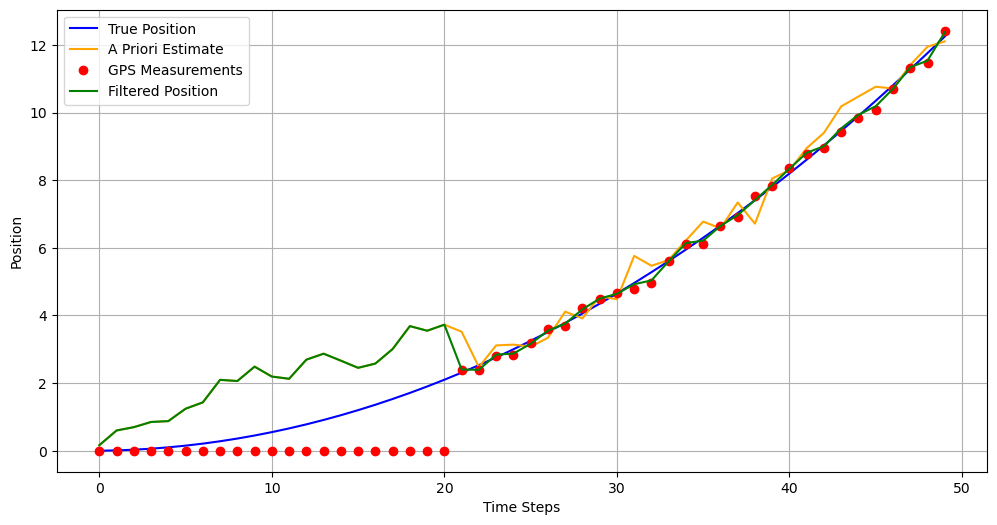

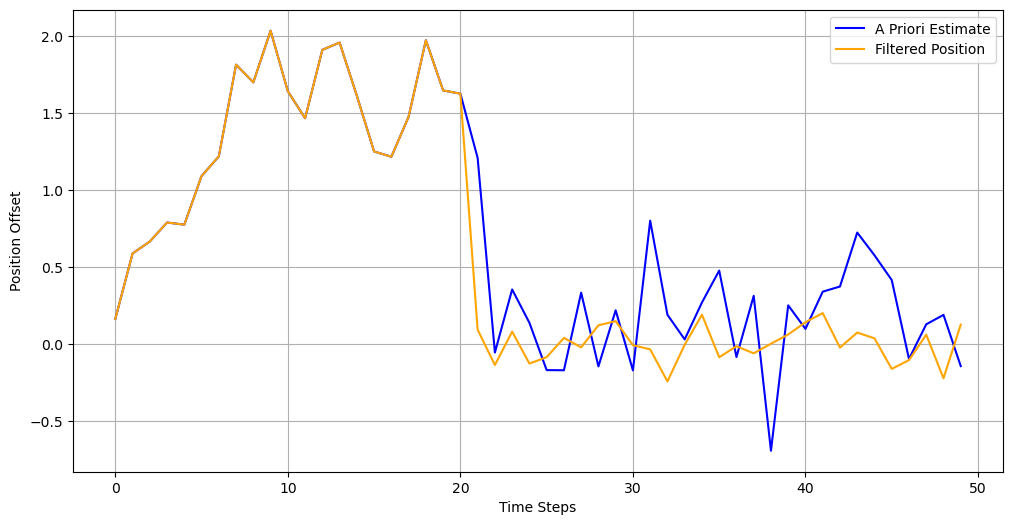

In [185]:
import numpy as np
import matplotlib.pyplot as plt

# Kalman Filter Initialization
initial_state = 0  # Initial position estimate
initial_estimate_error = 1  # Initial position estimate error
process_variance = .1  # Process noise (assumed constant)
measurement_variance = .02  # Measurement noise (GPS measurement error)

# Time step
dt = .01

# Lists to store results
true_positions = []
predicted_states = []
measurements = []
filtered_positions = []
true_position = 0
step_drift = 10

# Simulate vehicle motion
num_steps = 50
for step in range(num_steps):
    true_position = true_position + step * dt
    true_positions.append(true_position)



    # Kalman Filter Prediction (Time Update)
    predicted_state = initial_state + (step + step_drift) * dt + np.random.normal(0, np.sqrt(process_variance))
    predicted_states.append(predicted_state)
    
    predicted_estimate_error = initial_estimate_error + process_variance

    # Kalman Filter Update (Measurement Correction)
    if step > 20: 
        # Simulate GPS measurement with noise
        measurement = true_position + np.random.normal(0, np.sqrt(measurement_variance))
        
        kalman_gain = predicted_estimate_error / (predicted_estimate_error + measurement_variance)
        initial_state = predicted_state + kalman_gain * (measurement - predicted_state)
        initial_estimate_error = (1 - kalman_gain) * predicted_estimate_error
    else:
        measurement = 0
        initial_state = predicted_state   
   
    measurements.append(measurement)
    
    filtered_positions.append(initial_state)

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(true_positions, label='True Position', color='blue')
plt.plot(predicted_states, label='A Priori Estimate', color='orange')
plt.plot(measurements, 'ro', label='GPS Measurements')
fp = np.append(0,filtered_positions)
#fp = fp[2:]
fp = fp[1:51]
plt.plot(fp, label='Filtered Position', color='green')
#plt.title('1D Kalman Filter for GPS Position Estimation')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.grid(True)
plt.show()

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(np.subtract(predicted_states,true_positions), label='A Priori Estimate', color='blue')
#fp = np.append(0,filtered_positions)
plt.plot(np.subtract(fp,true_positions), label='Filtered Position', color='orange')
#plt.title('1D Kalman Filter for GPS Position Estimation')
plt.xlabel('Time Steps')
plt.ylabel('Position Offset')
plt.legend()
plt.grid(True)
plt.show()


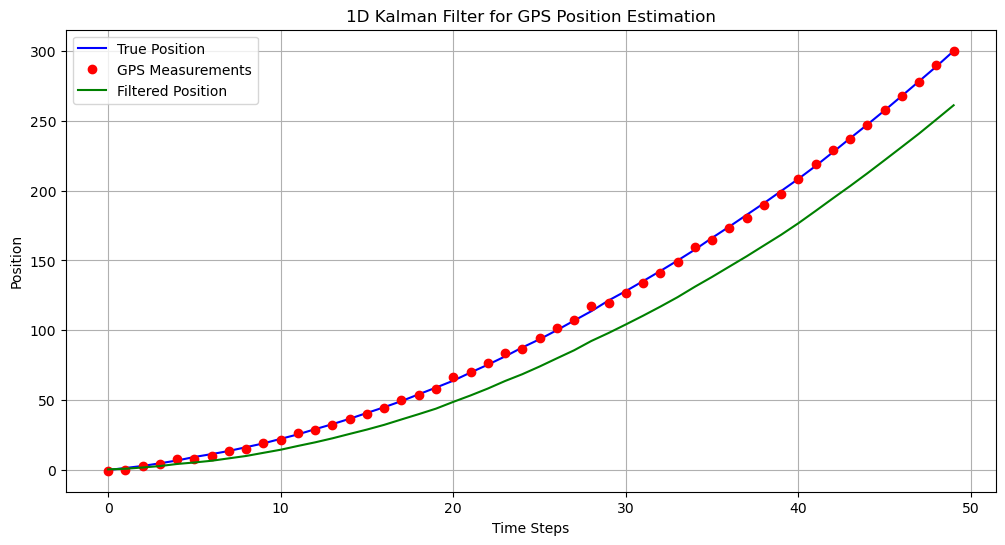

In [68]:
import numpy as np
import matplotlib.pyplot as plt

# Kalman Filter Initialization
initial_state = 0  # Initial position estimate
initial_estimate_error = 1  # Initial position estimate error
process_variance = 0.1  # Process noise (assumed constant)
measurement_variance = 2  # Measurement noise (GPS measurement error)

# Time step
dt = 1

# Lists to store results
true_positions = []
measurements = []
filtered_positions = []

# Initialize the initial state and estimate error
state_estimate = initial_state
estimate_error = initial_estimate_error

# Simulate vehicle motion
num_steps = 50
for step in range(num_steps):
    true_position = state_estimate + step * dt
    true_positions.append(true_position)

    # Simulate GPS measurement with noise
    measurement = true_position + np.random.normal(0, np.sqrt(measurement_variance))
    measurements.append(measurement)

    # Kalman Filter Prediction (Time Update)
    state_estimate = state_estimate + estimate_error  # Predicted state estimate
    estimate_error += process_variance  # Predicted estimate error

    # Kalman Filter Update (Measurement Correction)
    kalman_gain = estimate_error / (estimate_error + measurement_variance)
    state_estimate = state_estimate + kalman_gain * (measurement - state_estimate)
    estimate_error = (1 - kalman_gain) * estimate_error

    filtered_positions.append(state_estimate)

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(true_positions, label='True Position', color='blue')
plt.plot(measurements, 'ro', label='GPS Measurements')
plt.plot(filtered_positions, label='Filtered Position', color='green')
plt.title('1D Kalman Filter for GPS Position Estimation')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.grid(True)
plt.show()


In [102]:
predicted_states[2:5]

[1.2375954250023644, 0.9456509723741626, 0.17907697078038298]

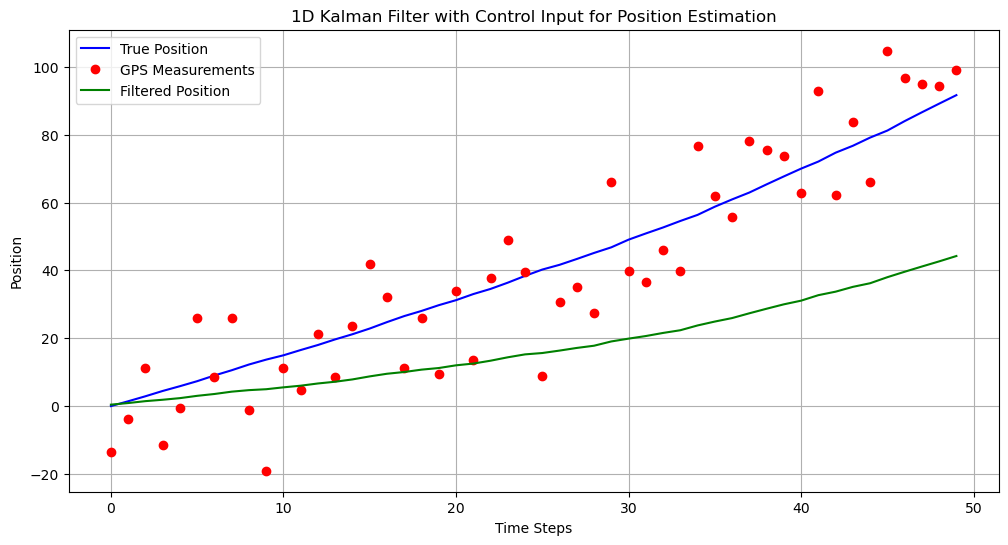

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Kalman Filter Initialization
initial_state = 0        # Initial position estimate
initial_estimate_error = 1  # Initial position estimate error
process_variance = 0.1   # Process noise (assumed constant)
measurement_variance = 200  # Measurement noise (GPS measurement error)
control_input = 0.5      # External control input (velocity of the object)

# Time step
dt = 1

# Lists to store results
true_positions = []
measurements = []
filtered_positions = []

# Initialize the initial state and estimate error
state_estimate = initial_state
estimate_error = initial_estimate_error

# Simulate vehicle motion
num_steps = 50
for step in range(num_steps):
    true_position = state_estimate + step * dt
    true_positions.append(true_position)

    # Simulate GPS measurement with noise
    measurement = true_position + np.random.normal(0, np.sqrt(measurement_variance))
    measurements.append(measurement)

    # Kalman Filter Prediction (Time Update) with control input
    state_estimate = state_estimate + (control_input * dt)  # Predicted state estimate with control input
    estimate_error += process_variance  # Predicted estimate error

    # Kalman Filter Update (Measurement Correction)
    kalman_gain = estimate_error / (estimate_error + measurement_variance)
    state_estimate = state_estimate + kalman_gain * (measurement - state_estimate)
    estimate_error = (1 - kalman_gain) * estimate_error

    filtered_positions.append(state_estimate)

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(true_positions, label='True Position', color='blue')
plt.plot(measurements, 'ro', label='GPS Measurements')
plt.plot(filtered_positions, label='Filtered Position', color='green')
plt.title('1D Kalman Filter with Control Input for Position Estimation')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.grid(True)
plt.show()


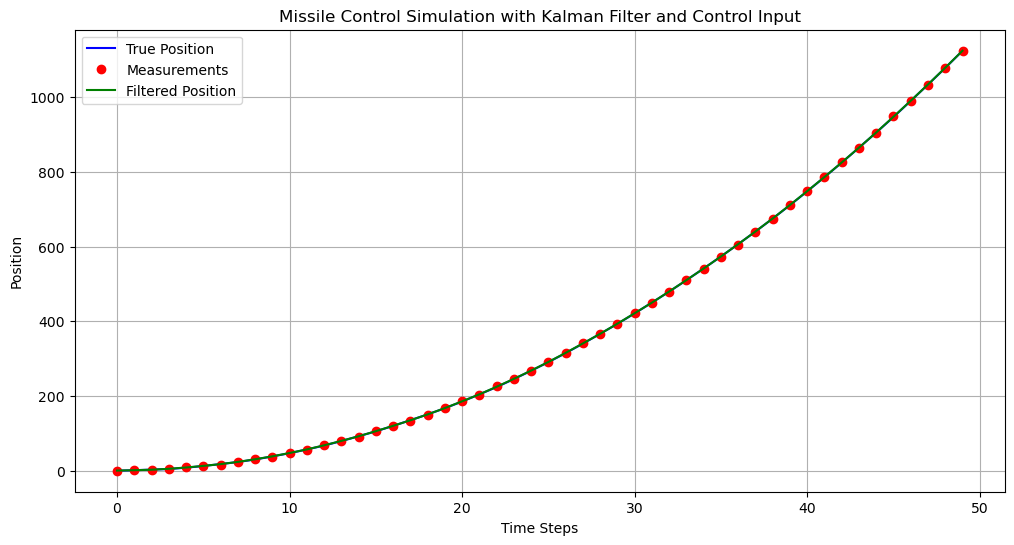

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Kalman Filter Initialization
initial_state = np.array([0.0, 0.0])  # Initial state estimate [position, velocity]
initial_estimate_error = np.array([1.0, 1.0])  # Initial estimate errors for position and velocity
process_noise = np.array([0.1, 0.01])  # Process noise for position and velocity
measurement_noise = 1.0  # Measurement noise

# Control input
u_k = 1.0  # Constant control input representing acceleration

# Time step
dt = 1.0

# Lists to store results
true_positions = []
measurements = []
filtered_positions = []

# Initialize the initial state and estimate error
state_estimate = initial_state.copy()
estimate_error = initial_estimate_error.copy()

# Simulate missile motion
num_steps = 50
for step in range(num_steps):
    # True missile motion (simulated)
    true_position = state_estimate[0] + state_estimate[1] * dt
    true_positions.append(true_position)

    # Simulate measurement with noise
    measurement = true_position + np.random.normal(0, np.sqrt(measurement_noise))
    measurements.append(measurement)

    # Kalman Filter Prediction (Time Update) with control input
    state_estimate[0] = state_estimate[0] + state_estimate[1] * dt + 0.5 * u_k * (dt**2)  # Predicted position
    state_estimate[1] = state_estimate[1] + u_k * dt  # Predicted velocity

    estimate_error += process_noise

    # Kalman Filter Update (Measurement Correction)
    kalman_gain = estimate_error / (estimate_error + measurement_noise)
    state_estimate = state_estimate + kalman_gain * (measurement - state_estimate[0])
    estimate_error = (1 - kalman_gain) * estimate_error

    filtered_positions.append(state_estimate[0])

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(true_positions, label='True Position', color='blue')
plt.plot(measurements, 'ro', label='Measurements')
plt.plot(filtered_positions, label='Filtered Position', color='green')
plt.title('Missile Control Simulation with Kalman Filter and Control Input')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.grid(True)
plt.show()


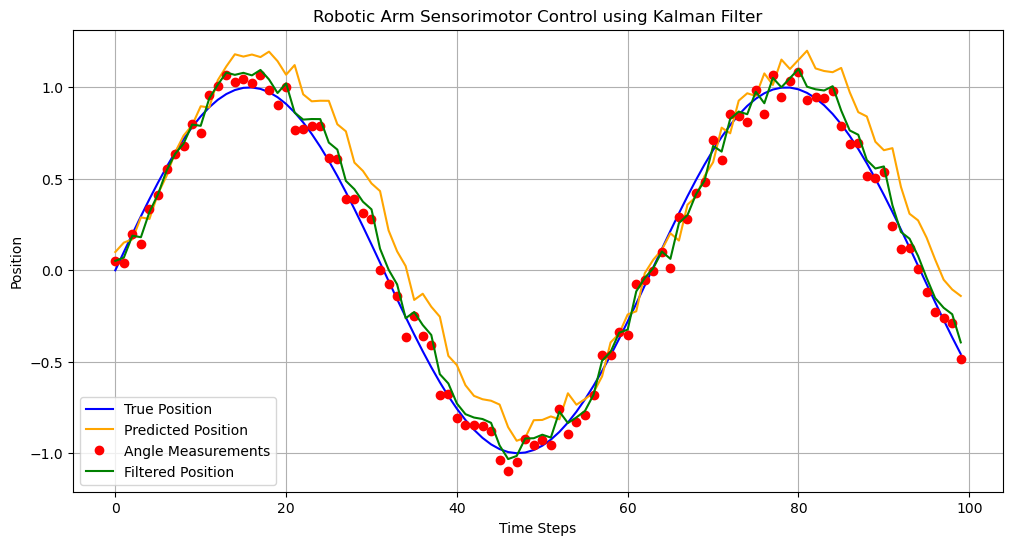

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Kalman Filter Initialization
initial_state = 0.0  # Initial position estimate
initial_estimate_error = 1.0  # Initial position estimate error
process_noise = 0.01  # Process noise (assumed constant)
measurement_noise = 0.005  # Measurement noise (sensor noise)

# Time step
dt = 0.1

# Lists to store results
true_positions = []
measurements = []
filtered_positions = []
predicted_positions = []

# Simulate robotic arm motion
num_steps = 100
for step in range(num_steps):
    # Simulated true position of the robotic arm
    true_position = np.sin(step * dt)  # Oscillating arm motion (sine wave)
    true_positions.append(true_position)

    # Simulate angle measurements with noise (e.g., from an encoder or sensor)
    measurement = true_position + np.random.normal(0, np.sqrt(measurement_noise))
    measurements.append(measurement)

    # Kalman Filter Prediction (Time Update)
    predicted_state = initial_state + dt  # Predicted position
    predicted_positions.append(predicted_state)
    
    initial_estimate_error += process_noise

    # Kalman Filter Update (Measurement Correction)
    kalman_gain = initial_estimate_error / (initial_estimate_error + measurement_noise)
    initial_state = predicted_state + kalman_gain * (measurement - predicted_state)
    initial_estimate_error = (1 - kalman_gain) * initial_estimate_error

    filtered_positions.append(initial_state)

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(true_positions, label='True Position', color='blue')
plt.plot(predicted_positions, label='Predicted Position', color='orange')
plt.plot(measurements, 'ro', label='Angle Measurements')
plt.plot(filtered_positions, label='Filtered Position', color='green')
plt.title('Robotic Arm Sensorimotor Control using Kalman Filter')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.grid(True)
plt.show()


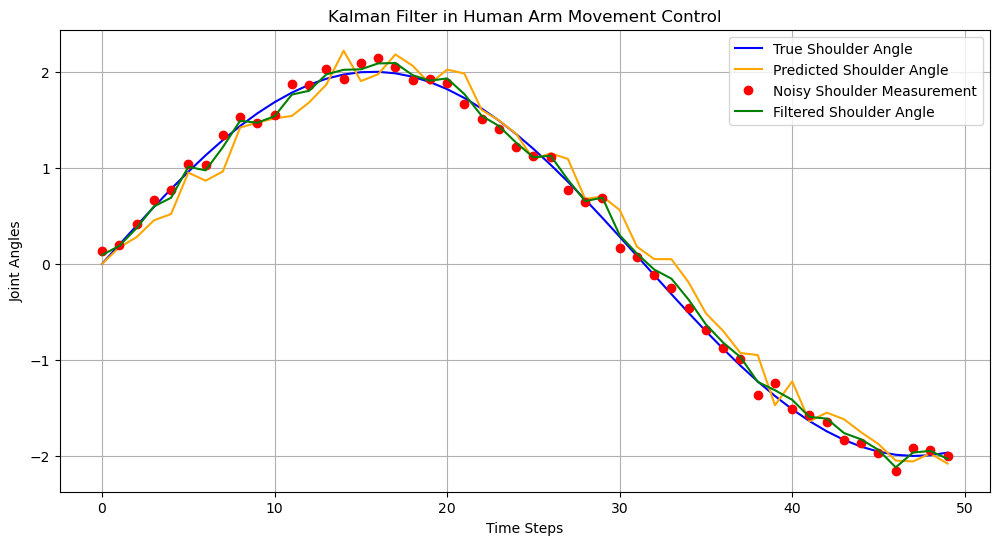

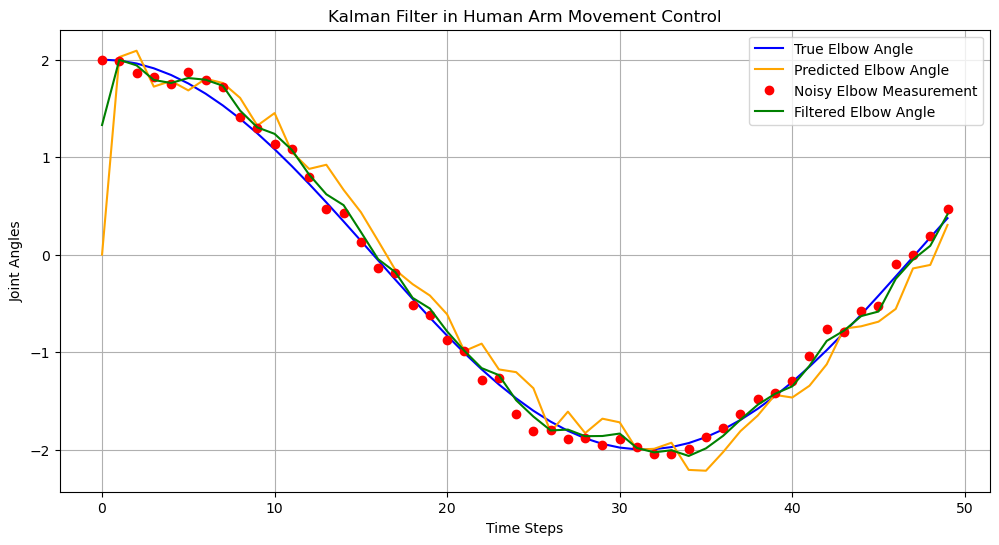

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Kalman Filter Initialization
initial_state = np.array([0.0, 0.0])  # Initial joint angles (e.g., shoulder and elbow)
initial_estimate_error = np.array([0.01, 0.01])  # Initial estimate error for joint angles
process_variance = np.array([0.01, 0.01])  # Process noise (uncertainty in joint angle changes)
measurement_variance = np.array([0.01, 0.01])  # Measurement noise (visual and proprioceptive feedback)

# Time step
dt = 0.1

# Internal Model Forgotting factor
forget = 0.5

# Lists to store results
true_positions = []
measurements = []
filtered_positions = []
predicted_positions = []


# Simulate arm movement
num_steps = 50
for step in range(num_steps):
    if step > 0:
        delta = posterior_state - predicted_state
        initial_state = posterior_state + delta*forget + np.random.normal(0, np.sqrt(process_variance))
        #initial_state = posterior_state 

    # Kalman Filter Prediction (Time Update)
    predicted_state = initial_state  # Simplified prediction as no control input (Bk) is considered
    predicted_positions.append(predicted_state)
    predicted_estimate_error = initial_estimate_error + process_variance
    
    # Simulate true joint angles (ground truth)
    true_state = np.array([np.sin(step * 0.1), np.cos(step * 0.1)]) * 2.0
    true_positions.append(true_state)

    # Simulate noisy measurements with visual and proprioceptive feedback
    measurement = true_state + np.random.normal(0, np.sqrt(measurement_variance))
    measurements.append(measurement)


    # Kalman Filter Update (Measurement Correction)
    kalman_gain = predicted_estimate_error / (predicted_estimate_error + measurement_variance)
    posterior_state = predicted_state + kalman_gain * (measurement - predicted_state)
    posterior_estimate_error = (1 - kalman_gain) * predicted_estimate_error

    filtered_positions.append(posterior_state)

# Convert lists to arrays for easier indexing
true_positions = np.array(true_positions)
measurements = np.array(measurements)
filtered_positions = np.array(filtered_positions)
predicted_positions = np.array(predicted_positions)

# Plot results
plt.figure(figsize=(12, 6))
plt.plot(true_positions[:, 0], label='True Shoulder Angle', color='blue')
plt.plot(predicted_positions[:, 0], label='Predicted Shoulder Angle', color='orange')
plt.plot(measurements[:, 0], 'ro', label='Noisy Shoulder Measurement')
plt.plot(filtered_positions[:, 0], label='Filtered Shoulder Angle', color='green')
plt.title('Kalman Filter in Human Arm Movement Control')
plt.xlabel('Time Steps')
plt.ylabel('Joint Angles')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(true_positions[:, 1], label='True Elbow Angle', color='blue')
plt.plot(predicted_positions[:, 1], label='Predicted Elbow Angle', color='orange')
plt.plot(measurements[:, 1], 'ro', label='Noisy Elbow Measurement')
plt.plot(filtered_positions[:, 1], label='Filtered Elbow Angle', color='green')
plt.title('Kalman Filter in Human Arm Movement Control')
plt.xlabel('Time Steps')
plt.ylabel('Joint Angles')
plt.legend()
plt.grid(True)
plt.show()



In [6]:
num_steps = 50
for step in range(num_steps):
    print(step)

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49


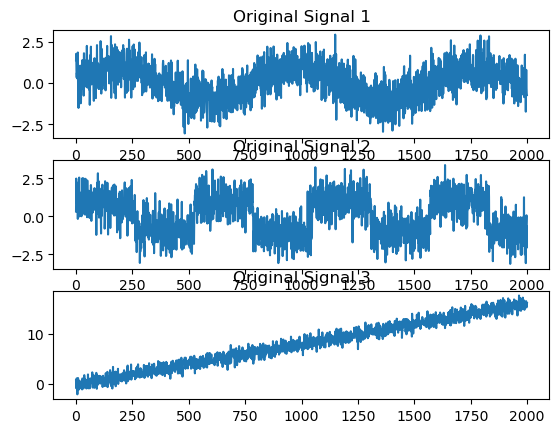

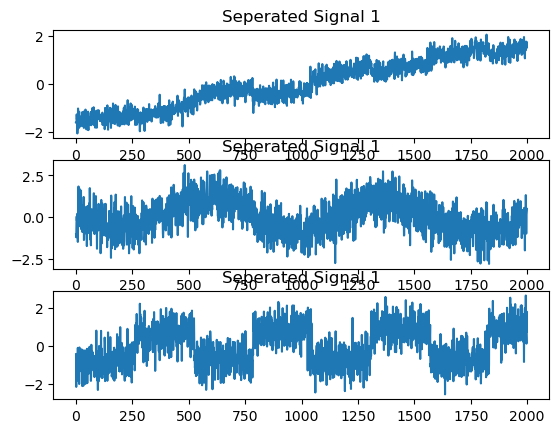

In [11]:
import numpy as np
from sklearn.decomposition import FastICA
import matplotlib.pyplot as plt

# Generate synthetic mixed EMG signals
np.random.seed(0)
n_samples = 2000
time = np.linspace(0, 8, n_samples)

s1 = np.sin(2 * time)
s2 = np.sign(np.sin(3 * time))
s3 = np.abs(2 * time)

S = np.c_[s1, s2, s3]
S += 0.8 * np.random.normal(size=S.shape)  # Add noise

# Mix data
A = np.array([[1, 1, 1], [0.5, 2, 1.0], [1.5, 1.0, 2.0]])  # Mixing matrix
X = np.dot(S, A.T)

# Run ICA
ica = FastICA(n_components=3)
S_ = ica.fit_transform(X)  # Reconstructed sources

# Plot the original and separated EMG signals
plt.figure()
plt.subplot(3, 1, 1)
plt.title('Original Signal 1')
plt.plot(S[:,0])

plt.subplot(3, 1, 2)
plt.title('Original Signal 2')
plt.plot(S[:,1])


plt.subplot(3, 1, 3)
plt.title('Original Signal 3')
plt.plot(S[:,2])
plt.show()


plt.figure()
plt.subplot(3, 1, 1)
plt.title('Seperated Signal 1')
plt.plot(S_[:,0])

plt.subplot(3, 1, 2)
plt.title('Seperated Signal 1')
plt.plot(S_[:,1])


plt.subplot(3, 1, 3)
plt.title('Seperated Signal 1')
plt.plot(S_[:,2])
plt.show()


In [64]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.
